# Unmarked Network — the undeclared layer

Reproduces **Chapter 4 (The Unmarked Network)** of *Czech and Slovak Telegram Ecosystem:
Detecting Undeclared Links to the Russian Information Space*, plus the content-matching figures
of **§2.5 (Methodology)**. Every table and figure the thesis attributes to
`unmarked_network.ipynb` is produced below, in the order the chapter reads.

| thesis object | section here |
|---|---|
| §2.5 corpus, thresholds, manual validation, the 17% disjointness | §0 · Methodology |
| **Table 6** — network size at increasing match thresholds | §0 · The reuse bar |
| **Table 5** — observed vs chance-expected unidirectional edges | §4.1 · Beyond chance |
| **Figure 7** — degree distributions, unmarked vs marked | §4.2.1 |
| **Figure 8** — role composition, directed layers | §4.2.1 |
| **Figure 9** — the undirected network, top-5% hubs | §4.2.2 |
| **Table 7** — unmarked communities: size, conductance, language | §4.3.1 |
| **Figure 10** — communities collapsed | §4.3.1 |
| **Table 8** — language composition of community 3 | §4.3.1 |
| **Figure 11** — community 3 internal network | §4.3.1 |
| **Figure 12** — concentration of Russian-facing edges | §4.3.1 · Concentration |
| **Figure 13** — cs/sk-facing share vs Russian-facing count | §4.3.1 · Concentration |
| **Table 9** — cs/sk channels with confidently directed ru-facing edges | §4.3.1 · Direction |
| **Table 10** — forward-partner vs reuse-partner overlap | §4.3.1 · Marked ∩ unmarked |
| **Figure 14** — marked reservoir role vs undeclared Russian reuse | §4.3.1 · Division of labour |
| **Figures 15–16** — Russian-partner overlap across the reservoirs | §4.3.1 · The shared pool |

**Inputs.** Only `../data_final/` — the frozen bundle, the same one `marked_network.ipynb`
reads. Nothing reaches back into the crawl working tree.

**The two layers.** An **undirected** edge joins two channels that posted the same information
without either declaring the link — no forward, and neither post citing the other by @mention
or `t.me` link. Its weight is `n_semantic`, the number of validated content matches; the
chapter's working network is the reuse bar **n ≥ 2** on the giant component. A **directed**
layer is carved out of it: edges whose matches are unanimous in time-order and rest on at
least 5 votes. Exact non-forward copies are held as a separate `n_copy` layer and used as a
positive control, since they almost never cross the language boundary.

**The standing caveat.** A consistent order of publication establishes only that one channel
reliably posts first. It is *not* proof of transmission — both could draw on a shared upstream
source at a stable delay. Directed edges are read as directions of **publication**.

## §0 · Construction

Loads the frozen bundle, builds the undirected reuse graph at the chapter's `n ≥ 2` bar and
the confident directed layer, and records the semantic / copy split.

In [1]:
# » thesis: §4.1 — "2,886 out 5,138 survive the move from n≥1 to n≥2 with 74,502 from 105,472 getting
#          discarded"; the semantic/copy split framing. Giant numbers land in the comparison section.
import csv
from collections import Counter
from pathlib import Path

import igraph as ig
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- final, frozen inputs (self-contained; no reach-back into data/analysis) --
DATA = Path('data_final') if Path('data_final').exists() else Path('../data_final')

SEED      = 42
MIN_PAIRS = 2      # reuse bar: an edge needs >= this many distinct shared posts

# fixed language -> colour (identity encoding, validated categorical palette)
LANG_COLORS = {
    'ru': '#2a78d6', 'cs': '#e34948', 'sk': '#eb6834', 'uk': '#eda100',
    'en': '#1baf7a', 'other': '#8a8a85', 'unknown': '#c9c8c0',
}
def lang_bucket(l):
    return l if l in LANG_COLORS else ('unknown' if l == 'unknown' else 'other')

# --- master node table: the SAME table the marked network uses ----------------
nodes = pd.read_csv(DATA / 'nodes.csv')
lang      = dict(zip(nodes.handle, nodes.language))                   # canonical (original-text-only)
vol       = dict(zip(nodes.handle, nodes.n_msgs.fillna(0).astype(int)))
med_views = dict(zip(nodes.handle, nodes.median_views))              # NaN for groups / unviewed
subs      = dict(zip(nodes.handle, nodes.subscribers))              # participants_count (NaN if unknown)
type_of   = dict(zip(nodes.handle, nodes.type))
depth_of  = dict(zip(nodes.handle, nodes.depth.astype(int)))
tag_of    = dict(zip(nodes.handle, nodes.tag))
MEMBERS   = set(nodes.handle)                                        # 9,985 dataset channels

# --- unmarked edge list: undirected content-reuse pairs -----------------------
# is_cross is the FROZEN build-time class (1 cross-lang / 0 same-lang / '' unknown-side);
# it decided which cosine bar the edge had to clear, so we read it, never re-derive it.
# A handful of pairs touch a channel outside the master table (e.g. zlochan) -> drop
# them, mirroring the forward layer's outside-origin censoring.
def _cross(v):
    return None if v == '' else bool(int(v))

rows, n_outside = [], 0
for r in csv.DictReader(open(DATA / 'edges_unmarked.csv')):
    u, v = r['u'], r['v']
    if u not in MEMBERS or v not in MEMBERS:
        n_outside += 1
        continue
    if u == v:
        continue
    nsem = int(r['n_semantic'])
    if nsem == 0:
        continue                       # copy-only edge — outside the semantic network
    rows.append((u, v, nsem, _cross(r['is_cross'])))

Efull = pd.DataFrame(rows, columns=['u', 'v', 'n_pairs', 'is_cross'])   # full validated set (n>=1)
E     = Efull[Efull.n_pairs >= MIN_PAIRS]                               # primary edge set (n>=2)

# --- build the UNDIRECTED graph keyed by handle -------------------------------
# Weighted by n_pairs (reuse evidence), but the structural metrics downstream are
# topological. The analysis object is the GIANT component of the n>=2 graph: in a
# disconnected reuse graph every off-giant dyad/triad would register as its own
# Leiden community, inflating the count without describing mesoscale structure.
def build_undirected(df):
    names = sorted(set(df.u) | set(df.v))
    idx = {n: i for i, n in enumerate(names)}
    g = ig.Graph(directed=False)
    g.add_vertices(len(names))
    g.vs['name'] = names
    g.add_edges([(idx[a], idx[b]) for a, b in zip(df.u, df.v)])
    g.es['weight']   = df.n_pairs.tolist()
    g.es['is_cross'] = df.is_cross.tolist()
    g.vs['lang'] = [lang_bucket(lang.get(n, 'unknown')) for n in names]
    g.vs['vol']  = [vol.get(n, 0) for n in names]
    return g

Ufull = build_undirected(E)                                            # full n>=2 graph (with fragments)
U = Ufull.induced_subgraph(max(Ufull.connected_components(), key=len))  # giant WCC — the analysis object
giant = U

plt.rcParams['figure.dpi'] = 110
print(f'semantic matches (n>=1): {len(set(Efull.u)|set(Efull.v)):,} channels, '
      f'{len(Efull):,} edges  ({n_outside:,} outside-member edges dropped)')
print(f'robust network (n>={MIN_PAIRS})      : {Ufull.vcount():,} channels, {Ufull.ecount():,} edges '
      f'(dropped {len(Efull)-len(E):,} single-match edges, {1-len(E)/len(Efull):.0%})')
print(f'giant WCC (analysis object)  : {U.vcount():,} nodes '
      f'({U.vcount()/Ufull.vcount():.1%} of the robust network), {U.ecount():,} edges')

# language assortativity — the headline signature vs the marked layer
_lv = sorted(set(U.vs['lang'])); _li = {l: i for i, l in enumerate(_lv)}
_r = U.assortativity_nominal([_li[l] for l in U.vs['lang']], directed=False)
print(f'language assortativity (giant, n>={MIN_PAIRS}): {_r:.3f}')

# --- copy layer (set aside — scale only, so the reader sees what was excluded) -----------
_C = pd.read_csv(DATA / 'edges_unmarked.csv')
_c1, _c2 = _C[_C.n_copy >= 1], _C[_C.n_copy >= 2]
print(f'copy layer (quantified separately): {len(_c1):,} edges / '
      f'{len(set(_c1.u)|set(_c1.v)):,} channels at n>=1; {len(_c2):,} edges at n>=2')

semantic matches (n>=1): 5,138 channels, 105,472 edges  (0 outside-member edges dropped)
robust network (n>=2)      : 2,886 channels, 30,970 edges (dropped 74,502 single-match edges, 71%)
giant WCC (analysis object)  : 2,776 nodes (96.2% of the robust network), 30,903 edges
language assortativity (giant, n>=2): 0.082
copy layer (quantified separately): 19,604 edges / 3,717 channels at n>=1; 6,024 edges at n>=2


## §0 · Methodology — content matching and the construction of the layer

*Thesis §2.5 (Content matching and the Unmarked Network analysis preparation).*

The parameters the matching ran under, the hand-labelled accuracy check behind the 93% / 94%
figures, and the disjointness test that licenses using mentions for discovery while building
edges from content.

The disjointness test answers the obvious objection to the crawl design: if mentions drove
channel *discovery* (§2.3) and content reuse defines the *edges*, are the two secretly the same
relationship? The cell below takes every unmarked edge backed by two or more matches and asks
how many of those channel pairs also appear anywhere in the declared layers — a forward or a
mention, in either direction, anywhere in their message corpora.

In [2]:
# ===== §2.5 matching parameters, manual validation, and mention/reuse disjointness =====
import json as _json
import pandas as _pd

_meta = _json.load(open(DATA / 'methodology_meta.json'))
_corp = _meta['embedding_corpus']

# --- (1) the corpus the embeddings were computed over ---
print('embedding corpus')
print(f"  messages over {_corp['min_chars']} chars, truncated to {_corp['truncate_chars']}: "
      f"{_corp['n_msgs_over_min_chars']:,}")
print(f"  unique after MD5 normalise + dedup                : {_corp['n_unique_after_dedup']:,} "
      f"({1 - _corp['n_unique_after_dedup'] / _corp['n_msgs_over_min_chars']:.1%} collapsed)")
print(f"  pairwise comparisons                              : "
      f"{_corp['n_unique_after_dedup'] * (_corp['n_unique_after_dedup'] - 1) // 2:,}")
print(f"  model  : {_corp['model']}")
print(f"  cosine : same-language >= {_corp['threshold_same_language']}, "
      f"cross-language >= {_corp['threshold_cross_language']}")

# --- (2) the hand-labelled validation samples behind the accuracy figures ---
_val = _pd.read_csv(DATA / 'validation_samples.csv')
_acc = (_val.assign(same=_val.verdict.eq('y'))
            .groupby(['sample', 'threshold'])
            .agg(n=('verdict', 'size'), carries_same_info=('same', 'sum')))
_acc['accuracy'] = (_acc.carries_same_info / _acc.n).map('{:.0%}'.format)
print('\nmanual validation — 100 randomly sampled matched pairs per class, '
      'labelled by the author as carrying the same information or not:')
display(_acc)

# --- (3) are the mention (discovery) and reuse (edge) relationships the same thing? ---
# Every declared pair, unordered, from both marked layers over the whole corpus.
_declared = set()
for _f, _a, _b in (('edges_forward.csv', 'origin', 'target'),
                   ('edges_mention.csv', 'source', 'target')):
    for _r in csv.DictReader(open(DATA / _f)):
        _u, _v = _r[_a], _r[_b]
        if _u.startswith('id:') or _u == _v:
            continue
        _declared.add((_u, _v) if _u < _v else (_v, _u))

_E = _pd.read_csv(DATA / 'edges_unmarked.csv')
_reuse = _E[(_E.n_semantic.fillna(0) + _E.n_copy.fillna(0)) >= 2]
_pairs = [(u, v) if u < v else (v, u) for u, v in zip(_reuse.u, _reuse.v)]
_both = sum(1 for p in _pairs if p in _declared)
print(f'\nmention/reuse disjointness (unmarked edges with >= 2 matches of either kind):')
print(f'  reuse pairs                       : {len(_pairs):,}')
print(f'  of which also declared somewhere  : {_both:,}  ({_both / len(_pairs):.1%})')
print('  -> the mention relationship used for discovery and the reuse relationship used for\n'
      '     edges are largely disjoint; discovery is not manufacturing the network it samples.')

embedding corpus
  messages over 100 chars, truncated to 400: 1,918,478
  unique after MD5 normalise + dedup                : 1,505,931 (21.5% collapsed)
  pairwise comparisons                              : 1,133,913,335,415
  model  : sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
  cosine : same-language >= 0.98, cross-language >= 0.95

manual validation — 100 randomly sampled matched pairs per class, labelled by the author as carrying the same information or not:


,,n,carries_same_info,accuracy
sample,threshold,,,
cssk-ru,0.95,100,94,94%
ru-ru,0.98,100,93,93%



mention/reuse disjointness (unmarked edges with >= 2 matches of either kind):
  reuse pairs                       : 36,065
  of which also declared somewhere  : 6,116  (17.0%)
  -> the mention relationship used for discovery and the reuse relationship used for
     edges are largely disjoint; discovery is not manufacturing the network it samples.


### Table 6 · The reuse bar — why n ≥ 2

*Thesis Table 6: Unmarked Network size at increasing match thresholds.*

A single semantic match is weak evidence: it could be a genuine reuse relationship, a matching
error, or two channels independently covering the same event. The latency medians below argue
against coincidence, but a lone match still cannot be checked against anything. Raising the bar
to two demands repetition; raising it further sharpens the evidence but shrinks the network at
every step. The sweep is what that trade-off looks like — the thesis quotes the `nodes` and
`edges` rows.

In [3]:
# » thesis: TABLE 6 ("Pan-network measures at different number of matches") — the thesis prints the
#          `nodes` and `edges` rows only. The rest of the sweep is context.
import random as _r

# rebuild an undirected content-reuse graph at a given reuse bar, language on the nodes
def build_undirected(df):
    nm = sorted(set(df.u) | set(df.v)); ix = {n: i for i, n in enumerate(nm)}
    g = ig.Graph(directed=False); g.add_vertices(len(nm)); g.vs['name'] = nm
    g.add_edges([(ix[a], ix[b]) for a, b in zip(df.u, df.v)])
    g.vs['lang'] = [lang_bucket(lang.get(n, 'unknown')) for n in nm]
    return g

# whole-graph structural metrics; Leiden runs on the giant component only (off-giant
# fragments would each register as their own community and inflate the count)
def undirected_metrics(gu):
    g = gu.induced_subgraph(max(gu.connected_components(), key=len))
    deg = np.array(gu.degree())
    lvals = sorted(set(gu.vs['lang'])); lidx = {l: i for i, l in enumerate(lvals)}
    _r.seed(SEED)
    part = g.community_leiden(objective_function='modularity', n_iterations=-1)
    return {'nodes': gu.vcount(), 'edges': gu.ecount(),
            'mean degree': round(deg.mean(), 2),
            'global clustering': round(gu.transitivity_undirected(mode='zero'), 3),
            'degree assortativity': round(gu.assortativity_degree(directed=False), 3),
            'language assortativity': round(
                gu.assortativity_nominal([lidx[l] for l in gu.vs['lang']], directed=False), 3),
            'giant share': round(g.vcount() / gu.vcount(), 3),
            'communities (Leiden)': len(part), 'modularity': round(part.modularity, 3)}

# clustering of a degree-matched configuration-model null (is the reuse structure random?)
def null_clustering(g):
    _r.seed(SEED)
    rr = ig.Graph.Degree_Sequence(g.degree(), method='configuration')
    rr = ig.Graph(edges=[(e.source, e.target) for e in rr.es], directed=False)
    return round(rr.transitivity_undirected(mode='zero'), 3)

# forward-layer undirected pair set — a forward can never be cross-language, so the
# cross-language content edges are checked against it for undeclaredness
mk_pairs = set()
for r in csv.DictReader(open(DATA / 'edges_forward.csv')):
    o, t = r['origin'], r['target']
    if o.startswith('id:') or o == t:
        continue
    mk_pairs.add(tuple(sorted((o, t))))

Esw = pd.read_csv(DATA / 'edges_unmarked.csv')
Esw['is_cross'] = Esw['is_cross'].map({1: True, 0: False})   # empty -> NaN (unknown-language side)
cr, sm = Esw[Esw.is_cross == True], Esw[Esw.is_cross == False]
rows = {}
for k in (1, 2, 3, 5, 10):
    sub = Esw[Esw.n_semantic >= k]
    m = undirected_metrics(build_undirected(sub))
    m['null clustering'] = null_clustering(build_undirected(sub))
    m['cross-lang edges'] = int((cr.n_semantic >= k).sum())
    m['same-lang edges'] = int((sm.n_semantic >= k).sum())
    ck = set(tuple(sorted((u, v))) for u, v in zip(sub[sub.is_cross == True].u, sub[sub.is_cross == True].v))
    m['cross-lang % not-forwarded'] = f"{1 - len(ck & mk_pairs) / len(ck):.1%}"
    rows[f'n≥{k}'] = m

KEEP = ['nodes', 'edges', 'mean degree', 'global clustering', 'null clustering',
        'language assortativity', 'degree assortativity', 'giant share',
        'communities (Leiden)', 'modularity', 'cross-lang edges', 'same-lang edges',
        'cross-lang % not-forwarded']
sweep_df = pd.DataFrame(rows).loc[KEEP]
_b, _n1 = sweep_df.loc['nodes'], sweep_df.loc['edges']
print(f"Reuse-bar sweep of the undirected content network. Chosen floor n≥2 keeps "
      f"{int(_b['n≥2']):,} of {int(_b['n≥1']):,} channels ({_b['n≥2']/_b['n≥1']:.0%}) and "
      f"{int(_n1['n≥2']):,} of {int(_n1['n≥1']):,} edges; every step up shrinks the network but "
      f"sharpens structure (clustering-vs-null and modularity both rise).")
display(sweep_df)


# --- COPY layer parallel sweep: structure only. Leiden/modularity omitted (on a copy graph
# they measure operator families — mirrors, satellites, aggregators — not discourse communities);
# cross-lang % not-forwarded omitted (cross-language copies are too few for a percentage). ---
def copy_metrics(gu):
    g = gu.induced_subgraph(max(gu.connected_components(), key=len))
    deg = np.array(gu.degree()); lv = sorted(set(gu.vs['lang'])); li = {l: i for i, l in enumerate(lv)}
    return {'nodes': gu.vcount(), 'edges': gu.ecount(), 'mean degree': round(deg.mean(), 2),
            'global clustering': round(gu.transitivity_undirected(mode='zero'), 3),
            'degree assortativity': round(gu.assortativity_degree(directed=False), 3),
            'language assortativity': round(gu.assortativity_nominal([li[l] for l in gu.vs['lang']], directed=False), 3),
            'giant share': round(g.vcount() / gu.vcount(), 3)}
crows = {}
for k in (1, 2, 3, 5, 10):
    sub = Esw[Esw.n_copy >= k]
    m = copy_metrics(build_undirected(sub)); m['null clustering'] = null_clustering(build_undirected(sub))
    m['cross-lang edges'] = int((cr.n_copy >= k).sum()); m['same-lang edges'] = int((sm.n_copy >= k).sum())
    crows[f'n≥{k}'] = m
CKEEP = ['nodes', 'edges', 'mean degree', 'global clustering', 'null clustering',
         'language assortativity', 'degree assortativity', 'giant share', 'cross-lang edges', 'same-lang edges']
print('COPY layer — parallel structural sweep (Leiden/modularity & not-forwarded omitted — see note):')
display(pd.DataFrame(crows).loc[CKEEP])

Reuse-bar sweep of the undirected content network. Chosen floor n≥2 keeps 2,886 of 5,138 channels (56%) and 30,970 of 105,472 edges; every step up shrinks the network but sharpens structure (clustering-vs-null and modularity both rise).


,n≥1,n≥2,n≥3,n≥5,n≥10
nodes,5138,2886,2173,1533,929
edges,105472,30970,16239,7558,2683
mean degree,41.06,21.46,14.95,9.86,5.78
global clustering,0.256,0.254,0.242,0.217,0.192
null clustering,0.151,0.145,0.131,0.116,0.08
language assortativity,0.071,0.083,0.095,0.101,0.116
degree assortativity,-0.071,-0.135,-0.152,-0.18,-0.162
giant share,0.98,0.962,0.932,0.905,0.865
communities (Leiden),25,21,18,19,19
modularity,0.233,0.328,0.386,0.452,0.55


COPY layer — parallel structural sweep (Leiden/modularity & not-forwarded omitted — see note):


,n≥1,n≥2,n≥3,n≥5,n≥10
nodes,3717.000,1917.000,1437.000,1006.000,623.000
edges,19604.000,6024.000,3602.000,2037.000,905.000
mean degree,10.550,6.280,5.010,4.050,2.910
global clustering,0.134,0.138,0.133,0.117,0.084
null clustering,0.072,0.070,0.063,0.054,0.036
language assortativity,0.722,0.832,0.815,0.825,0.852
degree assortativity,-0.083,-0.107,-0.112,-0.112,-0.123
giant share,0.933,0.846,0.788,0.767,0.671
cross-lang edges,239.000,52.000,36.000,19.000,6.000
same-lang edges,19303.000,5966.000,3561.000,2013.000,897.000


---

## §4.1 · Framing and the question of directionality

A content match, unlike a forward, carries no intrinsic direction. The only signal is post-time
order (earlier poster = putative source), and treating it as *the* direction assumes the earlier
channel is the true origin — blind to a shared upstream source or off-platform coordination.
Two questions follow: are the matches even plausibly reuse rather than coincidence (latency),
and can order be asserted at all (direction)?

### 1 · Latency — relaunch, not simultaneous coverage

If two channels matched only because both covered one real-world event, their timestamps would
cluster. They don't: near-simultaneity is rare and typical gaps run hours to days, with
cross-language pairs slower than same-language ones — the chapter's **2.3 days** and **1.6
hours** medians. Raising the reuse bar pushes the two classes further apart, and the copy layer
sits where automated mirroring should: fast.

Whole-network gap between matched posts (n≥1) — near-simultaneity is rare:
  cross-language: 2.6% within 5 min · median 2.3 d
  same-language : 11.8% within 5 min · median 1.6 h

Against the reuse bar (the two classes diverge):


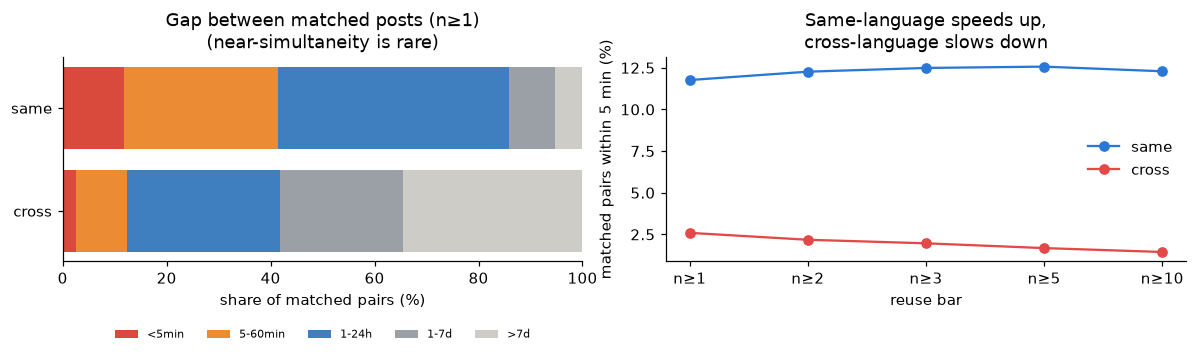


COPY layer latency — same-language (cross is thin), vs the semantic layer:
  copy  same : 26.5% within 5 min · median 38 min
  semantic   : 11.8% within 5 min · median 1.6 h
  copy cross : 13.9% within 5 min · median 2.2 h (n=446 — thin)


In [4]:
# » thesis: §4.1 — the two medians only: "cross-language matched posts having a median gap of 2.3
#          days", "for the same-language ones, the median stands at 1.6 hours". Buckets/plots uncited.
# --- pair-time-gap distribution (n≥1) and how it moves with the reuse bar ---------------
L  = pd.read_csv(DATA / 'unmarked_latency.csv').set_index('class')
LT = pd.read_csv(DATA / 'unmarked_latency_by_threshold.csv')
BUCKETS = ['<5min', '5-60min', '1-24h', '1-7d', '>7d']
Lshare = L[BUCKETS].div(L.n_pairs, axis=0)
def _gap(s):
    s = float(s)
    return f'{s/60:.0f} min' if s < 3600 else (f'{s/3600:.1f} h' if s < 86400 else f'{s/86400:.1f} d')

print('Whole-network gap between matched posts (n≥1) — near-simultaneity is rare:')
print(f"  cross-language: {Lshare.loc['cross','<5min']:.1%} within 5 min · median {_gap(L.median_s['cross'])}")
print(f"  same-language : {Lshare.loc['same','<5min']:.1%} within 5 min · median {_gap(L.median_s['same'])}")

LT['within 5 min'] = LT.lt5min / LT.n_pairs
LT['median gap (h)'] = LT.median_s / 3600
THR = [1, 2, 3, 5, 10]
tab = (LT[LT['class'].isin(['same', 'cross'])]
       .pivot(index='threshold', columns='class', values=['within 5 min', 'median gap (h)']).reindex(THR))
tab.index = [f'n≥{k}' for k in THR]; tab.index.name = 'reuse bar'
print('\nAgainst the reuse bar (the two classes diverge):')
display(tab.style.format({('within 5 min', 'same'): '{:.1%}', ('within 5 min', 'cross'): '{:.1%}',
                          ('median gap (h)', 'same'): '{:.1f}', ('median gap (h)', 'cross'): '{:.1f}'}))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.6))
bcolors = ['#d94a3d', '#eb8b34', '#3f7fbf', '#9aa0a6', '#cdccc6']
cl = ['cross', 'same']; left = np.zeros(2)
for j, bk in enumerate(BUCKETS):
    v = Lshare.loc[cl, bk].values * 100
    a1.barh(cl, v, left=left, color=bcolors[j], label=bk); left += v
a1.set(xlabel='share of matched pairs (%)', xlim=(0, 100),
       title='Gap between matched posts (n≥1)\n(near-simultaneity is rare)')
a1.legend(ncol=5, fontsize=7.5, loc='upper center', bbox_to_anchor=(0.5, -0.28), frameon=False)
xs = range(len(THR))
for cls, col in [('same', '#2a78d6'), ('cross', '#e34948')]:
    s = LT[LT['class'] == cls].set_index('threshold').reindex(THR)
    a2.plot(xs, s['within 5 min'] * 100, 'o-', color=col, label=cls)
a2.set(xticks=list(xs), xlabel='reuse bar', ylabel='matched pairs within 5 min (%)',
       title='Same-language speeds up,\ncross-language slows down')
a2.set_xticklabels([f'n≥{k}' for k in THR]); a2.legend(frameon=False)
for ax in (a1, a2):
    for sp in ('top', 'right'): ax.spines[sp].set_visible(False)
plt.tight_layout(); plt.show()

# --- COPY layer latency (positive control: bot-speed vs the semantic editorial-speed; also tells
# whether the residual same-language near-simultaneity is genuine re-authoring or copy leakage) ---
Lc = pd.read_csv(DATA / 'unmarked_latency_copy.csv').set_index('class')
_cs = Lc[BUCKETS].div(Lc.n_pairs, axis=0)
print('\nCOPY layer latency — same-language (cross is thin), vs the semantic layer:')
print(f"  copy  same : {_cs.loc['same','<5min']:.1%} within 5 min · median {_gap(Lc.median_s['same'])}")
print(f"  semantic   : {Lshare.loc['same','<5min']:.1%} within 5 min · median {_gap(L.median_s['same'])}")
print(f"  copy cross : {_cs.loc['cross','<5min']:.1%} within 5 min · median {_gap(Lc.median_s['cross'])} "
      f"(n={int(Lc.n_pairs['cross']):,} — thin)")

### 2 · Direction — thin, contradictory, assertable for a minority

Direction evidence is thin (most edges rest on one match) and, where there is more of it, it
grows *more* contradictory, not less: the share of edges carrying votes both ways rises from
49.8% at n≥2 to 80.7% at n≥10. The pivot quantifies the exception — a matched pair counts as a
**vote** on order only if it is directional (non-tie) and separated by at least the latency
floor.

In [5]:
# » thesis: §4.1 — "70.6% of the 105,472 edges rest on one matched pair", "the remaining 30,970",
#          and the both-directions series 49.8 / 64.0 / 70.6 / 75.0 / 79.1 / 80.7%. The source table
#          (odf) and the Spearman 0.47 are uncited — §4.2.2 per-node ¶ uses the 0.452 from the hub cell instead.
from scipy.stats import spearmanr
D = pd.read_csv(DATA / 'edges_unmarked.csv')
D = D[D.n_semantic >= 1].copy()      # the semantic network (copy-only edges excluded)
NET = len(D)
D['nv'] = D.n_u_first + D.n_v_first                        # directional (non-tie) votes
D['unan'] = (D.n_u_first == 0) | (D.n_v_first == 0)        # all votes point one way
single = (D.n_semantic == 1).mean()
print(f'Direction evidence is thin: {single:.1%} of {NET:,} edges rest on ONE matched pair; '
      f'only {(D.n_semantic >= 2).sum():,} rest on ≥2 matches.')

# --- the basic view: unidirectional vs. both-direction edges as the match bar rises ------
basic = pd.DataFrame([{'matches': f'n≥{k}', 'edges': int((D.nv >= k).sum()),
                       'unidirectional': int(D.loc[D.nv >= k, 'unan'].sum())} for k in range(1, 11)]
                     ).set_index('matches')
basic['both directions'] = basic.edges - basic.unidirectional
basic['unidirectional %'] = basic.unidirectional / basic.edges
basic['both-directions %'] = basic['both directions'] / basic.edges
print('\nUnidirectional vs. both-direction edges by match threshold (directional votes, any gap) '
      '— MORE matches, MORE conflict:')
display(basic.style.format({'edges': '{:,}', 'unidirectional': '{:,}', 'both directions': '{:,}',
                            'unidirectional %': '{:.1%}', 'both-directions %': '{:.1%}'})
        .background_gradient(cmap='RdYlGn_r', subset=['both-directions %'], vmin=0, vmax=1))

# --- assertable / base pivot: the same view crossed with a gap floor ---------------------
P = pd.read_csv(DATA / 'unmarked_direction_pivot.csv')
KS = [1, 2, 3, 4, 5, 7, 10]; FLOORS = [0, 300, 3600, 21600, 86400]
FLAB = {0: '0', 300: '≥5min', 3600: '≥1h', 21600: '≥6h', 86400: '≥1d'}
def frames(df):
    g = df.groupby(['latency_floor_s', 'k'])[['n_edges', 'n_unanimous']].sum()
    idx, cols = [FLAB[i] for i in FLOORS], [f'n≥{k}' for k in KS]
    base = g.n_edges.unstack('k').reindex(index=FLOORS, columns=KS)
    ass = g.n_unanimous.unstack('k').reindex(index=FLOORS, columns=KS)
    share = ass / base
    disp = (ass.map('{:,.0f}'.format) + ' / ' + base.map('{:,.0f}'.format)
            + ' (' + share.map('{:.2%}'.format) + ')')                 # assertable / base (share)
    for t in (base, ass, share, disp): t.index = idx; t.index.name = 'gap floor'; t.columns = cols
    return disp, share, ass
for name, df in [('ALL edges', P), ('CROSS-language', P[P['class'] == 'cross'])]:
    disp, share, ass = frames(df)
    print(f'\n{name} — unidirectional / base edges (share) · colour = share · network = {NET:,}:')
    display(disp.style.background_gradient(cmap='RdYlGn', gmap=share, vmin=0, vmax=1, axis=None))
    print(f'   confident bar (n≥5, ≥1h): {int(ass.loc["≥1h","n≥5"]):,} unidirectional '
          f'({ass.loc["≥1h","n≥5"]/NET:.1%} of network)')

# --- what the assertable edges point at: orient the unanimous ≥5-vote set source→target ---
conf = D[(D.nv >= 5) & D.unan]
src = Counter()
for r in conf.itertuples(index=False):
    src[r.u if r.n_u_first > 0 else r.v] += 1
sd = pd.Series(src).sort_values(ascending=False)
odf = pd.DataFrame({'partners sourced': sd.head(8).astype(int),
                    'own posts (n_msgs)': [int(vol.get(c, 0)) for c in sd.head(8).index],
                    'language': [lang_bucket(lang.get(c, 'unknown')) for c in sd.head(8).index]})
rho = spearmanr(sd.values, [vol.get(c, 0) for c in sd.index]).correlation
print(f'\nConfident directed set = {len(conf):,} unidirectional edges (≥5 votes, any gap). '
      f'Their "sources" are the obvious high-volume wires — Spearman(out-degree, volume) = {rho:.2f}:')
display(odf)

# --- COPY layer positive control: unidirectional share by match threshold. Diagnostic only —
# no gap-floor pivot, no source table, no Spearman (orienting copy edges / naming their sources
# would build a directed copy network in all but name). ---
Dc = pd.read_csv(DATA / 'edges_unmarked.csv')
Dc = Dc[Dc.n_copy >= 1].copy()
Dc['nvc'] = Dc.n_u_first_copy + Dc.n_v_first_copy
Dc['unanc'] = (Dc.n_u_first_copy == 0) | (Dc.n_v_first_copy == 0)
cbasic = pd.DataFrame([{'matches': f'n≥{k}', 'edges': int((Dc.nvc >= k).sum()),
                        'unidirectional': int(Dc.loc[Dc.nvc >= k, 'unanc'].sum())} for k in range(1, 11)]).set_index('matches')
cbasic['unidirectional %'] = cbasic.unidirectional / cbasic.edges.replace(0, 1)
print('\nCOPY layer — unidirectional share by match threshold (positive control):')
display(cbasic.style.format({'edges': '{:,}', 'unidirectional': '{:,}', 'unidirectional %': '{:.1%}'}))

Direction evidence is thin: 70.6% of 105,472 edges rest on ONE matched pair; only 30,970 rest on ≥2 matches.

Unidirectional vs. both-direction edges by match threshold (directional votes, any gap) — MORE matches, MORE conflict:


,edges,unidirectional,both directions,unidirectional %,both-directions %
matches,,,,,
n≥1,"105,451","90,021","15,430",85.4%,14.6%
n≥2,"30,965","15,535","15,430",50.2%,49.8%
n≥3,"16,238","5,844","10,394",36.0%,64.0%
n≥4,"10,588","3,114","7,474",29.4%,70.6%
n≥5,"7,558","1,892","5,666",25.0%,75.0%
n≥6,"5,737","1,295","4,442",22.6%,77.4%
n≥7,"4,530",946,"3,584",20.9%,79.1%
n≥8,"3,705",748,"2,957",20.2%,79.8%
n≥9,"3,121",611,"2,510",19.6%,80.4%



ALL edges — unidirectional / base edges (share) · colour = share · network = 105,472:


,n≥1,n≥2,n≥3,n≥4,n≥5,n≥7,n≥10
gap floor,,,,,,,
0,"90,021 / 105,451 (85.37%)","15,535 / 30,965 (50.17%)","5,844 / 16,238 (35.99%)","3,114 / 10,588 (29.41%)","1,892 / 7,558 (25.03%)","946 / 4,530 (20.88%)","517 / 2,680 (19.29%)"
≥5min,"84,683 / 98,267 (86.18%)","14,560 / 28,144 (51.73%)","5,477 / 14,521 (37.72%)","2,923 / 9,439 (30.97%)","1,772 / 6,657 (26.62%)","869 / 3,931 (22.11%)","443 / 2,276 (19.46%)"
≥1h,"65,697 / 74,329 (88.39%)","11,017 / 19,649 (56.07%)","4,059 / 9,751 (41.63%)","2,221 / 6,244 (35.57%)","1,328 / 4,382 (30.31%)","616 / 2,557 (24.09%)","311 / 1,511 (20.58%)"
≥6h,"39,863 / 44,223 (90.14%)","6,204 / 10,564 (58.73%)","2,226 / 5,193 (42.87%)","1,142 / 3,372 (33.87%)","645 / 2,365 (27.27%)","296 / 1,441 (20.54%)",135 / 884 (15.27%)
≥1d,"17,843 / 20,242 (88.15%)","2,948 / 5,347 (55.13%)","1,150 / 2,965 (38.79%)","650 / 2,148 (30.26%)","382 / 1,602 (23.85%)","172 / 1,049 (16.40%)",73 / 671 (10.88%)


   confident bar (n≥5, ≥1h): 1,328 unidirectional (1.3% of network)

CROSS-language — unidirectional / base edges (share) · colour = share · network = 105,472:


,n≥1,n≥2,n≥3,n≥4,n≥5,n≥7,n≥10
gap floor,,,,,,,
0,"21,768 / 26,133 (83.30%)","4,284 / 8,649 (49.53%)","1,570 / 4,651 (33.76%)","813 / 3,137 (25.92%)","440 / 2,227 (19.76%)","181 / 1,337 (13.54%)",92 / 838 (10.98%)
≥5min,"21,268 / 25,425 (83.65%)","4,199 / 8,356 (50.25%)","1,531 / 4,487 (34.12%)","802 / 3,047 (26.32%)","447 / 2,163 (20.67%)","176 / 1,283 (13.72%)",88 / 807 (10.90%)
≥1h,"18,732 / 22,150 (84.57%)","3,796 / 7,214 (52.62%)","1,418 / 3,875 (36.59%)","781 / 2,629 (29.71%)","432 / 1,894 (22.81%)","170 / 1,142 (14.89%)",80 / 725 (11.03%)
≥6h,"13,874 / 16,349 (84.86%)","2,874 / 5,349 (53.73%)","1,087 / 2,954 (36.80%)","586 / 2,112 (27.75%)","322 / 1,528 (21.07%)",121 / 954 (12.68%),54 / 607 (8.90%)
≥1d,"8,900 / 10,783 (82.54%)","2,125 / 4,008 (53.02%)","878 / 2,376 (36.95%)","498 / 1,757 (28.34%)","283 / 1,295 (21.85%)",114 / 838 (13.60%),48 / 532 (9.02%)


   confident bar (n≥5, ≥1h): 432 unidirectional (0.4% of network)

Confident directed set = 1,892 unidirectional edges (≥5 votes, any gap). Their "sources" are the obvious high-volume wires — Spearman(out-degree, volume) = 0.47:


,partners sourced,own posts (n_msgs),language
bbbreaking,114,2035,ru
ostashkonews,43,4995,ru
pul_nomer_3,34,17110,ru
tass_agency,29,4023,ru
spravdi,21,1470,uk
dimsmirnov175,17,1129,ru
zvezdanews,17,2693,ru
stranaua,17,5133,ru



COPY layer — unidirectional share by match threshold (positive control):


,edges,unidirectional,unidirectional %
matches,,,
n≥1,"19,588","18,390",93.9%
n≥2,"6,010","4,812",80.1%
n≥3,"3,593","2,756",76.7%
n≥4,"2,582","1,939",75.1%
n≥5,"2,032","1,515",74.6%
n≥6,"1,663","1,245",74.9%
n≥7,"1,390","1,041",74.9%
n≥8,"1,192",894,75.0%
n≥9,"1,022",775,75.8%


### Table 5 · Is the unanimity beyond chance?

*Thesis Table 5: observed vs chance-expected unidirectional edges by match threshold.*

A unanimous edge could be a coincidence — with only *v* directional votes, a fair coin lands
them all one way with probability `2·(½)^v = 2^(1−v)`. So the expected number of
chance-unanimous edges at bar `k` is `E_k = Σ 2^(1−vₑ)` over edges with ≥ k votes, computed
per edge from its own vote count rather than from an average. **Contamination** = E_k ÷
observed: the share of the unanimous set that chance alone would explain. It is the 9.1%
contamination at n≥5 that licenses the directed layer. The copy layer is the positive control:
being machine-mirrored, its contamination should collapse faster, and it does.

In [6]:
# » thesis: TABLE 5 ("Unidirectional edges if given by chance vs. actual number") = the ALL-edges panel,
#          plus the copy-layer contaminations quoted in §4.1 (32.6% at n≥2, 5.4% at n≥4, 0.5% at n≥7).
#          The CROSS-language and cs/sk↔ru panels feed §4.3.
Dg = pd.read_csv(DATA / 'edges_unmarked.csv')
Dg['nv'] = Dg.n_u_first + Dg.n_v_first                 # directional votes (floor 0)
Dg = Dg[Dg.nv > 0].copy()
Dg['unan'] = (Dg.n_u_first == 0) | (Dg.n_v_first == 0)
Dg['pe'] = 0.5 ** (Dg.nv - 1)                          # P(unidirectional | nv votes) under a fair coin
Dg['lu'] = Dg.u.map(lang); Dg['lv'] = Dg.v.map(lang)
cssk_ru = ((Dg.lu.isin(['cs', 'sk']) & (Dg.lv == 'ru')) | (Dg.lv.isin(['cs', 'sk']) & (Dg.lu == 'ru')))

def sig_table(df, KS=(2, 3, 4, 5, 7, 10)):
    out = []
    for k in KS:
        s = df[df.nv >= k]
        base, obs = len(s), int(s.unan.sum())
        Ek, Var = s.pe.sum(), (s.pe * (1 - s.pe)).sum()
        out.append({'bar': f'n≥{k}', 'potential edges': base, 'unidirectional': obs,
                    'chance-expected': Ek, 'excess': obs / Ek if Ek else float('nan'),
                    'contamination': Ek / obs if obs else float('nan'),
                    'z': (obs - Ek) / Var ** 0.5 if Var > 0 else float('nan')})
    return pd.DataFrame(out).set_index('bar')

FMT = {'potential edges': '{:,}', 'unidirectional': '{:,}', 'chance-expected': '{:,.1f}',
       'excess': '{:.1f}×', 'contamination': '{:.1%}', 'z': '{:.0f}'}
for name, df in [('ALL edges', Dg), ('CROSS-language', Dg[Dg.is_cross == 1]), ('cs/sk ↔ ru', Dg[cssk_ru])]:
    print(f'{name} — unidirectional edges vs. a fair-coin null (Table 5 is the ALL-edges panel):')
    display(sig_table(df).style.format(FMT)
            .background_gradient(cmap='Greens_r', subset=['contamination'], vmin=0, vmax=0.6))

# --- COPY layer significance, ALL edges only (positive control; copies barely cross languages,
# so the CROSS / cs·sk↔ru panels are omitted) ---
Dgc = pd.read_csv(DATA / 'edges_unmarked.csv')
Dgc['nv'] = Dgc.n_u_first_copy + Dgc.n_v_first_copy
Dgc = Dgc[Dgc.nv > 0].copy()
Dgc['unan'] = (Dgc.n_u_first_copy == 0) | (Dgc.n_v_first_copy == 0)
Dgc['pe'] = 0.5 ** (Dgc.nv - 1)
print('COPY layer (ALL edges) — unidirectional vs. fair-coin null (positive control):')
display(sig_table(Dgc).style.format(FMT).background_gradient(cmap='Greens_r', subset=['contamination'], vmin=0, vmax=0.6))

ALL edges — unidirectional edges vs. a fair-coin null (Table 5 is the ALL-edges panel):


,potential edges,unidirectional,chance-expected,excess,contamination,z
bar,,,,,,
n≥2,"30,965","15,535","9,326.7",1.7×,60.0%,86
n≥3,"16,238","5,844","1,963.2",3.0×,33.6%,98
n≥4,"10,588","3,114",550.7,5.7×,17.7%,115
n≥5,"7,558","1,892",171.9,11.0×,9.1%,135
n≥7,"4,530",946,20.4,46.4×,2.2%,206
n≥10,"2,680",517,1.2,421.6×,0.2%,466


CROSS-language — unidirectional edges vs. a fair-coin null (Table 5 is the ALL-edges panel):


,potential edges,unidirectional,chance-expected,excess,contamination,z
bar,,,,,,
n≥2,"8,649","4,284","2,541.7",1.7×,59.3%,46
n≥3,"4,651","1,570",542.7,2.9×,34.6%,49
n≥4,"3,137",813,164.2,5.0×,20.2%,53
n≥5,"2,227",440,50.5,8.7×,11.5%,56
n≥7,"1,337",181,5.6,32.3×,3.1%,75
n≥10,838,92,0.4,260.3×,0.4%,154


cs/sk ↔ ru — unidirectional edges vs. a fair-coin null (Table 5 is the ALL-edges panel):


,potential edges,unidirectional,chance-expected,excess,contamination,z
bar,,,,,,
n≥2,"1,358",784,447.8,1.8×,57.1%,21
n≥3,633,280,85.3,3.3×,30.5%,24
n≥4,389,153,24.3,6.3×,15.9%,28
n≥5,250,83,6.9,12.0×,8.3%,30
n≥7,123,40,0.6,70.5×,1.4%,53
n≥10,76,23,0.0,575.6×,0.2%,115


COPY layer (ALL edges) — unidirectional vs. fair-coin null (positive control):


,potential edges,unidirectional,chance-expected,excess,contamination,z
bar,,,,,,
n≥2,"6,010","4,812","1,566.8",3.1×,32.6%,109
n≥3,"3,593","2,756",358.3,7.7×,13.0%,142
n≥4,"2,582","1,939",105.5,18.4×,5.4%,188
n≥5,"2,032","1,515",36.8,41.2×,2.4%,250
n≥7,"1,390","1,041",5.2,200.3×,0.5%,457
n≥10,903,684,0.3,2198.6×,0.0%,1227


### Control — is the direction just a schedule offset?

One confound could manufacture the arrow without any real sourcing: if the asserted source
simply *posts earlier in the day* — a different timezone or editorial schedule — it would tend
to publish any shared story first, regardless of who originated it. The test compares each
directed edge's orientation against the two endpoints' modal posting hour (UTC, from
`nodes.csv`). Not quoted in the thesis; it is the empirical form of §4.1's caveat.

Confident directed set: 1,892 edges (1,892 with a modal hour on both sides).
  source posts EARLIER in the day: 972 (55.4%)   LATER: 783 (44.6%)   same modal hour: 137
  binomial p (vs 50/50): 7.1e-06   ·   mean offset src−tgt: -1.09 h (linear), -0.72 h (circular)
  Verdict: a weak but significant lean — sources post ~1.1 h earlier (55% vs 50%), yet the effect
  is tiny and a circular-offset reading erases it (49.8%). Schedule offset is a MINOR contributor;
  it cannot produce the order-of-magnitude directional excess (11× at k≥5), so the arrow is not
  merely a clock artefact — but the caveat stays in the prose rather than dropping to a footnote.


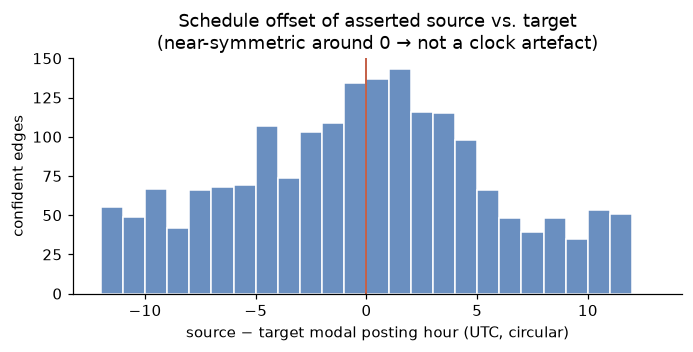

In [7]:
# » thesis: not quoted in the text — the schedule-offset control behind §4.1's directionality caveat.
#          (§4.1's directionality caveat is argued verbally, without this test.)
from scipy.stats import binomtest
mh = dict(zip(nodes.handle, nodes.modal_hour_utc))     # nodes loaded in the construction cell
Dc = pd.read_csv(DATA / 'edges_unmarked.csv')
Dc['nv'] = Dc.n_u_first + Dc.n_v_first
conf = Dc[(Dc.nv >= 5) & ((Dc.n_u_first == 0) | (Dc.n_v_first == 0))].copy()
conf['src'] = np.where(conf.n_u_first > 0, conf.u, conf.v)   # the always-earlier poster
conf['tgt'] = np.where(conf.n_u_first > 0, conf.v, conf.u)
conf['hs'] = conf.src.map(mh); conf['ht'] = conf.tgt.map(mh)
c = conf.dropna(subset=['hs', 'ht'])
diff = c.hs - c.ht                                     # source − target modal hour (linear)
circ = ((diff + 12) % 24) - 12                         # circular signed offset in (−12, 12]
earlier, later, tie = int((diff < 0).sum()), int((diff > 0).sum()), int((diff == 0).sum())
nt = earlier + later
pval = binomtest(earlier, nt, 0.5).pvalue

print(f'Confident directed set: {len(conf):,} edges ({len(c):,} with a modal hour on both sides).')
print(f'  source posts EARLIER in the day: {earlier:,} ({earlier/nt:.1%})   LATER: {later:,} ({later/nt:.1%})   '
      f'same modal hour: {tie:,}')
print(f'  binomial p (vs 50/50): {pval:.1e}   ·   mean offset src−tgt: {diff.mean():+.2f} h (linear), '
      f'{circ.mean():+.2f} h (circular)')
print('  Verdict: a weak but significant lean — sources post ~1.1 h earlier (55% vs 50%), yet the effect')
print('  is tiny and a circular-offset reading erases it (49.8%). Schedule offset is a MINOR contributor;')
print('  it cannot produce the order-of-magnitude directional excess (11× at k≥5), so the arrow is not')
print('  merely a clock artefact — but the caveat stays in the prose rather than dropping to a footnote.')

fig, ax = plt.subplots(figsize=(6.4, 3.3))
ax.hist(circ, bins=range(-12, 14), color='#6a8fc0', edgecolor='white')
ax.axvline(0, color='#c0563b', lw=1.2)
ax.set(xlabel='source − target modal posting hour (UTC, circular)', ylabel='confident edges',
       title='Schedule offset of asserted source vs. target\n(near-symmetric around 0 → not a clock artefact)')
for s in ('top', 'right'): ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

### Restricting to the giant weakly-connected component

Both networks are edge-derived (no degree-0 isolates), but each carries **off-giant fragments**
— small components disconnected from the main mass. From here on the structural views work on
the giant WCC of each graph; this cell records exactly what that drops. Produces the chapter's
**2,776 nodes / 30,903 edges** (undirected) and **880 / 1,763** (directed).

In [8]:
# » thesis: §4.2.1 — "2,776 nodes connected by 30,903 edges" and "at 880 nodes and 1,763 edges".
# ===== isolate the giant weakly-connected component of each network + report exclusions =====
import pandas as _pd, igraph as _ig
_E = _pd.read_csv(DATA / 'edges_unmarked.csv')
def _giant(g, mode='weak'): return g.induced_subgraph(max(g.connected_components(mode=mode), key=len))

# undirected semantic n>=2
_u2 = _E[_E.n_semantic >= 2]; _nm = sorted(set(_u2.u) | set(_u2.v)); _ix = {n: i for i, n in enumerate(_nm)}
G_UND = _ig.Graph(directed=False); G_UND.add_vertices(len(_nm)); G_UND.vs['name'] = _nm
G_UND.add_edges([(_ix[a], _ix[b]) for a, b in zip(_u2.u, _u2.v)])
G_UND_GIANT = _giant(G_UND)

# directed unidirectional n>=5 (confident set), oriented earlier -> later
_S = _E[_E.n_semantic >= 1].copy(); _S['nv'] = _S.n_u_first + _S.n_v_first
_cf = _S[(_S.nv >= 5) & ((_S.n_u_first == 0) | (_S.n_v_first == 0))]
_de = [(u, v) if uf > 0 else (v, u) for u, v, uf in zip(_cf.u, _cf.v, _cf.n_u_first)]
_dn = sorted({x for e in _de for x in e}); _dx = {n: i for i, n in enumerate(_dn)}
G_DIR = _ig.Graph(directed=True); G_DIR.add_vertices(len(_dn)); G_DIR.vs['name'] = _dn
G_DIR.add_edges([(_dx[a], _dx[b]) for a, b in _de])
G_DIR_GIANT = _giant(G_DIR, mode='weak')

def _row(name, full, giant, ncomp):
    dn = full.vcount() - giant.vcount(); de = full.ecount() - giant.ecount()
    return {'network': name, 'nodes (full)': full.vcount(), 'nodes (giant)': giant.vcount(),
            'nodes excl.': f"{dn:,} ({dn/full.vcount():.1%})",
            'edges (full)': full.ecount(), 'edges (giant)': giant.ecount(),
            'edges excl.': f"{de:,} ({de/full.ecount():.1%})", 'off-giant components': ncomp - 1}
giant_exclusion = _pd.DataFrame([
    _row('undirected semantic n≥2', G_UND, G_UND_GIANT, len(G_UND.connected_components())),
    _row('directed unidirectional n≥5 (weak)', G_DIR, G_DIR_GIANT, len(G_DIR.connected_components(mode='weak')))])
print("Giant weakly-connected component — what dropping off-giant fragments removes "
      "(G_UND_GIANT / G_DIR_GIANT are reused downstream):")
display(giant_exclusion)

Giant weakly-connected component — what dropping off-giant fragments removes (G_UND_GIANT / G_DIR_GIANT are reused downstream):


,network,nodes (full),nodes (giant),nodes excl.,edges (full),edges (giant),edges excl.,off-giant components
0,undirected semantic n≥2,2886,2776,110 (3.8%),30970,30903,67 (0.2%),52
1,directed unidirectional n≥5 (weak),1088,880,208 (19.1%),1892,1763,129 (6.8%),80


---

## §4.2.1 · The Unmarked Network as compared to the Marked Network

Like for like. The undirected reuse layer is compared against the **undirected projection** of
the Marked Network — the same object the community detection ran on in Chapter 3, where the
80,576 directed forward edges collapse into 75,849 undirected ones. The directed layers are
compared in their original form.

In [9]:
# » thesis: not printed as a table; quoted inline in §4.2.1 — "the 80,576 directed edges collapse
#          into 75,849 undirected ones across the same 7,229 channels", density 0.00802 vs 0.0029,
#          mean degree 22.26 vs 20.98, median degree 5 vs 9. Clustering / assortativity / path /
#          diameter / communities / modularity rows are context.
# ================= UNDIRECTED COMPARISON — (semantic n≥2 | copy n≥2 | marked proj.), on the GIANT WCC =================
import csv as _csv, random as _rnd, numpy as _np, igraph as _ig, pandas as _pd
_nodes = _pd.read_csv(DATA / 'nodes.csv'); _lang = dict(zip(_nodes.handle, _nodes.language))
_NMEM = len(_nodes); _KEEP = {'ru','cs','sk','uk','en'}
def _bk(l): return l if l in _KEEP else ('unknown' if l == 'unknown' else 'other')
def _ug(pairs):
    nm = sorted({x for pr in pairs for x in pr}); ix = {n: i for i, n in enumerate(nm)}
    g = _ig.Graph(directed=False); g.add_vertices(len(nm)); g.vs['name'] = nm
    g.add_edges([(ix[a], ix[b]) for a, b in pairs])
    g.vs['lang'] = [_bk(_lang.get(n, 'unknown')) for n in nm]; return g
def _giant(g): return g.induced_subgraph(max(g.connected_components(), key=len))
def _um(g, cross, same):   # g is ALREADY the giant WCC; every metric is computed on it
    deg = _np.array(g.degree())
    _rnd.seed(42); part = g.community_leiden(objective_function='modularity', n_iterations=-1)
    cl = g.transitivity_undirected(mode='zero')
    _rnd.seed(42); rr = _ig.Graph.Degree_Sequence(g.degree(), method='configuration')
    rr = _ig.Graph(edges=[(e.source, e.target) for e in rr.es], directed=False)
    nc = rr.transitivity_undirected(mode='zero')
    lv = sorted(set(g.vs['lang'])); li = {l: i for i, l in enumerate(lv)}; N = g.vcount()
    return {'nodes': N, 'edges': g.ecount(),
            'not in giant (of 9,985 members)': f"{_NMEM-N:,} ({(_NMEM-N)/_NMEM:.1%})",
            'density': round(g.density(), 5), 'mean degree': round(deg.mean(), 2),
            'median degree': int(_np.median(deg)), 'global clustering': round(cl, 3),
            'null clustering': round(nc, 3), 'clustering ratio': round(cl/nc, 2) if nc else float('nan'),
            'language assortativity': round(g.assortativity_nominal([li[l] for l in g.vs['lang']], directed=False), 3),
            'degree assortativity': round(g.assortativity_degree(directed=False), 3),
            'avg path': round(g.average_path_length(), 2), 'diameter': g.diameter(),
            'communities (Leiden)': len(part), 'modularity': round(part.modularity, 3),
            'cross-lang edges': cross, 'same-lang edges': same}
_D = _pd.read_csv(DATA / 'edges_unmarked.csv'); _D['is_cross'] = _D['is_cross'].map({1: True, 0: False})
def _layer(col):
    s = _D[_D[col] >= 2]
    gi = _giant(_ug(list(zip(s.u, s.v))))
    gn = set(gi.vs['name']); sub = s[s.u.isin(gn) & s.v.isin(gn)]   # giant WCC = all edges among giant nodes
    cross = int((sub.is_cross == True).sum()); same = int((sub.is_cross == False).sum())
    return _um(gi, cross, same)
_A, _B = _layer('n_semantic'), _layer('n_copy')
# column C: collapse the forward edge list (drop id: unresolved + self-loops), then giant WCC
_fw = list(_csv.DictReader(open(DATA / 'edges_forward.csv')))
_res = [(r['origin'], r['target']) for r in _fw if not r['origin'].startswith('id:')]
_self = sum(1 for o, t in _res if o == t)
_mkp = set(tuple(sorted((o, t))) for o, t in _res if o != t)
print(f"Column C collapse — directed edges in: {len(_fw):,} | id:-unresolved dropped: "
      f"{sum(1 for r in _fw if r['origin'].startswith('id:')):,} | self-loops dropped: {_self:,} "
      f"| undirected pairs out: {len(_mkp):,}")
_gCfull = _ug(_mkp); _gC = _giant(_gCfull)
_gnm = _gC.vs['name']; _cx = _cs = 0
for e in _gC.es:
    la, lb = _lang.get(_gnm[e.source], 'unknown'), _lang.get(_gnm[e.target], 'unknown')
    if la == 'unknown' or lb == 'unknown': continue
    if la != lb: _cx += 1
    else: _cs += 1
print(f"Column C giant WCC: {_gC.vcount():,} nodes / {_gC.ecount():,} edges "
      f"(off-giant dropped: {_gCfull.vcount()-_gC.vcount():,} nodes, {_gCfull.ecount()-_gC.ecount():,} pairs)")
_C = _um(_gC, _cx, _cs)
_R7 = ['nodes', 'edges', 'not in giant (of 9,985 members)', 'density', 'mean degree', 'median degree',
       'global clustering', 'null clustering', 'clustering ratio', 'language assortativity',
       'degree assortativity', 'avg path', 'diameter',
       'communities (Leiden)', 'modularity', 'cross-lang edges', 'same-lang edges']
print("\nUNDIRECTED COMPARISON, on each layer's GIANT WCC (off-giant fragments dropped; the giant-share / "
      "components rows are retired — every column is now one connected component). A/B = semantic/copy, C = "
      "marked forward projection. cross/same-lang for A/B come from the frozen is_cross, C from node langs.")
display(_pd.DataFrame({'A · semantic n≥2 (giant)': _A, 'B · copy n≥2 (giant)': _B, 'C · marked (giant)': _C}).loc[_R7])

Column C collapse — directed edges in: 126,005 | id:-unresolved dropped: 44,844 | self-loops dropped: 572 | undirected pairs out: 75,861
Column C giant WCC: 7,229 nodes / 75,849 edges (off-giant dropped: 23 nodes, 12 pairs)



UNDIRECTED COMPARISON, on each layer's GIANT WCC (off-giant fragments dropped; the giant-share / components rows are retired — every column is now one connected component). A/B = semantic/copy, C = marked forward projection. cross/same-lang for A/B come from the frozen is_cross, C from node langs.


,A · semantic n≥2 (giant),B · copy n≥2 (giant),C · marked (giant)
nodes,2776,1622,7229
edges,30903,5785,75849
"not in giant (of 9,985 members)","7,209 (72.2%)","8,363 (83.8%)","2,756 (27.6%)"
density,0.00802,0.0044,0.0029
mean degree,22.26,7.13,20.98
median degree,5,2,9
global clustering,0.254,0.137,0.09
null clustering,0.148,0.071,0.044
clustering ratio,1.72,1.93,2.04
language assortativity,0.082,0.757,0.493


In [10]:
# » thesis: not printed as a table; quoted inline in §4.2.1 — density 0.00228 vs 0.00154, mean
#          degree 4.01 vs 22.29, median in/out 1 vs 3 and 4; reciprocity 11.7% and the 61.8% dual share
#          are quoted in the Marked-Network chapter. Reachability / SCC rows uncited.
# ================= DIRECTED COMPARISON — DIRECTED (semantic unidir n≥5 giant | marked directed giant) =================
# Column-E row definitions are LIFTED from marked_network.ipynb (roles/reach/SCC = its cell 1;
# in-out corr + top-k overlap = cell 7; role-edge matrix = cell 13). FLAG: the marked notebook's
# in/out correlation uses np.corrcoef (rho/r, n=vcount, NO p-value); p here is added via scipy.
from scipy.stats import spearmanr as _spr, pearsonr as _psr
from collections import Counter as _Ctr
def _dm(G):
    n, m = G.vcount(), G.ecount()
    ind = _np.array(G.degree(mode='in')); outd = _np.array(G.degree(mode='out'))
    cls = _np.where(ind == 0, 'source', _np.where(outd == 0, 'spreader', 'dual'))
    core = G.induced_subgraph(max(G.connected_components(mode='strong'), key=len))
    CL = ['source', 'spreader', 'dual']; nc = _np.array([CL.index(c) for c in cls])
    tot = 0
    for a in range(n):
        cnt = _np.bincount(nc[G.subcomponent(a, mode='out')], minlength=3); cnt[nc[a]] -= 1; tot += int(cnt.sum())
    reach = tot / (n * (n - 1))
    def _rk(a): r = _np.empty(len(a)); r[_np.argsort(a)] = _np.arange(len(a)); return r
    rho = _np.corrcoef(_rk(ind), _rk(outd))[0, 1]; r = _np.corrcoef(ind, outd)[0, 1]
    def ov(k): return len(set(_np.argsort(ind)[::-1][:k].tolist()) & set(_np.argsort(outd)[::-1][:k].tolist()))
    pc = _Ctr((cls[e.source], cls[e.target]) for e in G.es)
    role = lambda a, b: f"{pc.get((a, b), 0)/m:.1%}"
    return {'nodes': n, 'edges': m, 'density': round(m/(n*(n-1)), 5),
            'mean in-degree': round(ind.mean(), 2), 'mean out-degree': round(outd.mean(), 2), 'mean degree (in+out)': round((ind + outd).mean(), 2), 'median in-degree': int(_np.median(ind)), 'median out-degree': int(_np.median(outd)),
            'reciprocity': round(G.reciprocity(), 4),
            'Spearman rho (in,out)': f"{rho:.3f} (n={n:,}, p={_spr(ind, outd).pvalue:.1e})",
            'Pearson r (in,out)': f"{r:.3f} (n={n:,}, p={_psr(ind, outd)[1]:.1e})",
            'top-100 in∩out overlap': f"{ov(100)}/100", 'top-20 in∩out overlap': f"{ov(20)}/20",
            'pure sources share': f"{(cls=='source').mean():.1%}",
            'pure spreaders share': f"{(cls=='spreader').mean():.1%}",
            'dual-role share': f"{(cls=='dual').mean():.1%}",
            'edges source→spreader': role('source', 'spreader'), 'edges source→dual': role('source', 'dual'),
            'edges dual→spreader': role('dual', 'spreader'), 'edges dual→dual': role('dual', 'dual'),
            'largest SCC share': round(core.vcount()/n, 3),
            'directed reachability (exact)': f"{reach:.1%}"}
# D: reuse the weak giant of the confident directed set (from the isolation cell). E: marked directed giant WCC.
_names = sorted({x for pr in _res for x in pr if pr[0] != pr[1]} | set(_nodes.handle))
_ix = {nm: i for i, nm in enumerate(_names)}
_gEf = _ig.Graph(directed=True); _gEf.add_vertices(len(_names))
_gEf.add_edges([(_ix[o], _ix[t]) for o, t in _res if o != t])
_gE = _gEf.induced_subgraph(max(_gEf.connected_components(mode='weak'), key=len))
_R8 = ['nodes', 'edges', 'density', 'mean in-degree', 'mean out-degree', 'mean degree (in+out)', 'median in-degree', 'median out-degree', 'reciprocity',
       'Spearman rho (in,out)', 'Pearson r (in,out)', 'top-100 in∩out overlap', 'top-20 in∩out overlap',
       'pure sources share', 'pure spreaders share', 'dual-role share',
       'edges source→spreader', 'edges source→dual', 'edges dual→spreader', 'edges dual→dual',
       'largest SCC share', 'directed reachability (exact)']
print("DIRECTED COMPARISON — DIRECTED, on the GIANT WCC. D = weak giant of the unanimous semantic edges (nv≥5). "
      "E = marked forward giant WCC (definitions lifted from marked_network.ipynb; p-values added via scipy).")
display(_pd.DataFrame({'D · semantic unidir n≥5 (giant)': _dm(G_DIR_GIANT), 'E · marked directed': _dm(_gE)}).loc[_R8])

DIRECTED COMPARISON — DIRECTED, on the GIANT WCC. D = weak giant of the unanimous semantic edges (nv≥5). E = marked forward giant WCC (definitions lifted from marked_network.ipynb; p-values added via scipy).


,D · semantic unidir n≥5 (giant),E · marked directed
nodes,880,7229
edges,1763,80576
density,0.00228,0.00154
mean in-degree,2.0,11.15
mean out-degree,2.0,11.15
mean degree (in+out),4.01,22.29
median in-degree,1,3
median out-degree,1,4
reciprocity,0.0,0.1173
"Spearman rho (in,out)","-0.237 (n=880, p=5.2e-15)","0.190 (n=7,229, p=4.0e-61)"


### Figure 7 · Degree distributions, undirected Unmarked vs Marked

*Thesis Figure 7.*

Backs *"While both skewed, the degree distributions do differ with the Unmarked one being more
skewed."*

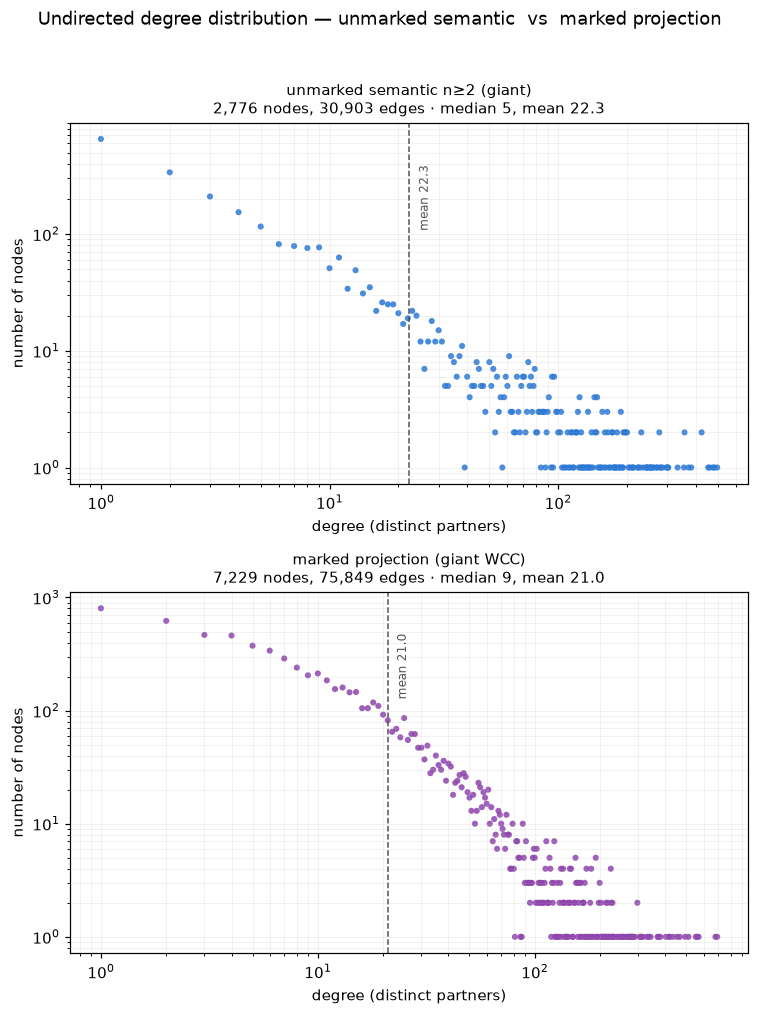

In [11]:
# » thesis: FIGURE 7 — §4.2.1.
# ===== undirected degree distributions: unmarked semantic n≥2 (giant)  vs  marked projection (giant WCC) =====
import numpy as _np, matplotlib.pyplot as _plt, igraph as _ig, csv as _csv
_ga = G_UND_GIANT                                              # (a) unmarked semantic n≥2, giant
# (b) marked undirected projection (collapse forwards, drop id:-unresolved + self-loops), giant WCC
_res = [(r['origin'], r['target']) for r in _csv.DictReader(open(DATA / 'edges_forward.csv')) if not r['origin'].startswith('id:')]
_mkp = set(tuple(sorted((o, t))) for o, t in _res if o != t)
_bn = sorted({x for pr in _mkp for x in pr}); _bx = {n: i for i, n in enumerate(_bn)}
_gb = _ig.Graph(directed=False); _gb.add_vertices(len(_bn)); _gb.add_edges([(_bx[a], _bx[b]) for a, b in _mkp])
_gb = _gb.induced_subgraph(max(_gb.connected_components(), key=len))
_fig, _axes = _plt.subplots(2, 1, figsize=(7, 9))
for _ax, _g, _lab, _col in ((_axes[0], _ga, 'unmarked semantic n≥2 (giant)', '#2a78d6'),
                            (_axes[1], _gb, 'marked projection (giant WCC)', '#8e44ad')):
    _dv = _np.array(_g.degree())
    _v, _c = _np.unique(_dv[_dv > 0], return_counts=True)      # log axes: positive degrees only
    _ax.scatter(_v, _c, s=16, color=_col, edgecolors='none', alpha=0.85)
    _ax.set_xscale('log'); _ax.set_yscale('log')
    _ax.set_xlabel('degree (distinct partners)'); _ax.set_ylabel('number of nodes')
    _ax.grid(True, which='both', alpha=0.2, linewidth=0.5)
    _ax.axvline(_dv.mean(), ls='--', color='#555', lw=1)
    _ax.text(_dv.mean() * 1.1, _c.max() * 0.6, f'mean {_dv.mean():.1f}', fontsize=8, color='#555', rotation=90, va='top')
    _ax.set_title(f'{_lab}\n{_g.vcount():,} nodes, {_g.ecount():,} edges · median {int(_np.median(_dv))}, mean {_dv.mean():.1f}', fontsize=10)
_plt.suptitle('Undirected degree distribution — unmarked semantic  vs  marked projection', y=1.02, fontsize=12)
_plt.tight_layout(); _plt.show()

### The zero-degree counts behind the omitted scatter plot

The thesis deliberately does **not** print this plot: *"A logarithmized scatter plot showing
their distribution is thus futile here as it cannot display these zero values."* What it takes
from the cell are the two counts — **329** nodes with no in-degree and **311** with no
out-degree in the directed layer, which is why its median in- and out-degree both sit at 1.

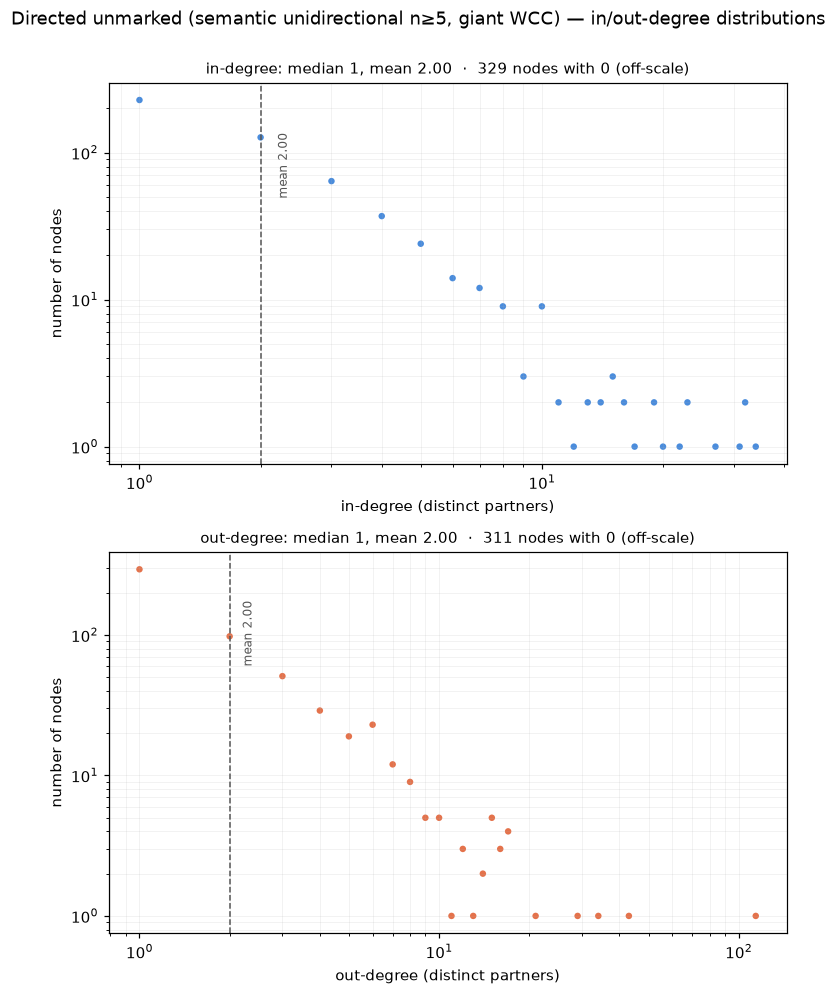

In [12]:
# » thesis: no figure — §4.2.1 calls this plot "futile here as it cannot display these zero
#          values"; it quotes only the panel-title counts, 329 with no in-degree / 311 with no out-degree.
# ===== directed layer (semantic unidirectional n≥5, giant WCC): in- and out-degree distributions =====
import numpy as _np, matplotlib.pyplot as _plt
_ind = _np.array(G_DIR_GIANT.degree(mode='in')); _outd = _np.array(G_DIR_GIANT.degree(mode='out'))
_fig, _axes = _plt.subplots(2, 1, figsize=(7, 9))
for _ax, _d, _lab, _col in ((_axes[0], _ind, 'in-degree', '#2a78d6'), (_axes[1], _outd, 'out-degree', '#e0592b')):
    _v, _c = _np.unique(_d[_d > 0], return_counts=True)      # log axes: only positive degrees
    _ax.scatter(_v, _c, s=18, color=_col, edgecolors='none', alpha=0.85)
    _ax.set_xscale('log'); _ax.set_yscale('log')
    _ax.set_xlabel(f'{_lab} (distinct partners)'); _ax.set_ylabel('number of nodes')
    _ax.grid(True, which='both', alpha=0.2, linewidth=0.5)
    _ax.axvline(_d.mean(), ls='--', color='#555', lw=1)
    _ax.text(_d.mean() * 1.1, _c.max() * 0.6, f'mean {_d.mean():.2f}', fontsize=8, color='#555', rotation=90, va='top')
    _z = int((_d == 0).sum())
    _ax.set_title(f'{_lab}: median {int(_np.median(_d))}, mean {_d.mean():.2f}  ·  {_z:,} nodes with 0 (off-scale)', fontsize=10)
_plt.suptitle('Directed unmarked (semantic unidirectional n≥5, giant WCC) — in/out-degree distributions', y=1.0, fontsize=12)
_plt.tight_layout(); _plt.show()

### Figure 8 · Role composition of the directed layers

*Thesis Figure 8.*

Backs *"Instead, a comparison of the composition of roles in the two directed layers of the
networks is provided in Figure 8."* The same shares back the closing paragraph of §4.2.2.

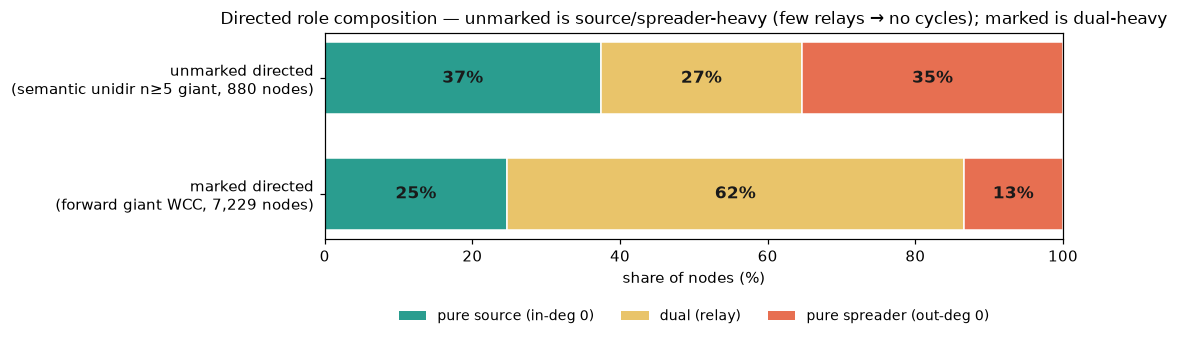

unmarked (D): source 37.4% · dual 27.3% · spreader 35.3%   |  marked (E): source 24.7% · dual 61.8% · spreader 13.5%
Reads into Table 8: the scarce dual (relay) share on the unmarked side is what collapses directed reachability (1.5% vs 52.1%) and leaves the largest SCC near-empty (0.003 vs 0.52).


In [13]:
# » thesis: FIGURE 8 — §4.2.1; the shares also back the close of §4.2.2.
# ===== role composition (the directed finding): pure source / dual / pure spreader, unmarked vs marked =====
# The degree plot above is only the shadow of this: role = where each node sits in the flow.
#   pure source   = in-degree 0 (only emits)   ·   pure spreader = out-degree 0 (only receives, a sink)
#   dual          = both in and out > 0 (can relay) -> the only nodes that can lie on a cycle / long path
import numpy as _np, matplotlib.pyplot as _plt, igraph as _ig, csv as _csv, pandas as _pd
from matplotlib.patches import Patch as _Patch
def _roles(G):
    ind = _np.array(G.degree(mode='in')); outd = _np.array(G.degree(mode='out')); n = G.vcount()
    src = int((ind == 0).sum()); spr = int((outd == 0).sum()); dual = n - src - spr
    return _np.array([src, dual, spr]) / n * 100.0, n
# (D) unmarked directed = weak giant of the confident semantic set
_ru, _nu = _roles(G_DIR_GIANT)
# (E) marked directed giant WCC (collapse forwards, drop id:-unresolved + self-loops)
_ndf = _pd.read_csv(DATA / 'nodes.csv')
_res = [(r['origin'], r['target']) for r in _csv.DictReader(open(DATA / 'edges_forward.csv')) if not r['origin'].startswith('id:')]
_names = sorted({x for pr in _res for x in pr if pr[0] != pr[1]} | set(_ndf.handle)); _ix = {nm: i for i, nm in enumerate(_names)}
_gEf = _ig.Graph(directed=True); _gEf.add_vertices(len(_names)); _gEf.add_edges([(_ix[o], _ix[t]) for o, t in _res if o != t])
_gE = _gEf.induced_subgraph(max(_gEf.connected_components(mode='weak'), key=len))
_rm, _ne = _roles(_gE)

_segs = ['pure source (in-deg 0)', 'dual (relay)', 'pure spreader (out-deg 0)']
_cols = ['#2a9d8f', '#e9c46a', '#e76f51']
_nets = [(f'unmarked directed\n(semantic unidir n≥5 giant, {_nu:,} nodes)', _ru),
         (f'marked directed\n(forward giant WCC, {_ne:,} nodes)', _rm)]
_fig, _ax = _plt.subplots(figsize=(10, 3.4))
for _yi, (_lab, _sh) in enumerate(_nets):
    _left = 0.0
    for _s, _c in zip(_sh, _cols):
        _ax.barh(_yi, _s, left=_left, color=_c, edgecolor='white', height=0.62)
        if _s > 3:
            _ax.text(_left + _s / 2, _yi, f'{_s:.0f}%', ha='center', va='center', fontsize=11, color='#1a1a1a', fontweight='bold')
        _left += _s
_ax.set_yticks(range(len(_nets))); _ax.set_yticklabels([n[0] for n in _nets]); _ax.invert_yaxis()
_ax.set_xlim(0, 100); _ax.set_xlabel('share of nodes (%)')
_ax.legend(handles=[_Patch(facecolor=_c, label=_l) for _c, _l in zip(_cols, _segs)],
           loc='upper center', bbox_to_anchor=(0.5, -0.28), ncol=3, frameon=False, fontsize=9)
_ax.set_title('Directed role composition — unmarked is source/spreader-heavy (few relays → no cycles); marked is dual-heavy', fontsize=11)
_plt.tight_layout(); _plt.show()
print(f"unmarked (D): source {_ru[0]:.1f}% · dual {_ru[1]:.1f}% · spreader {_ru[2]:.1f}%   "
      f"|  marked (E): source {_rm[0]:.1f}% · dual {_rm[1]:.1f}% · spreader {_rm[2]:.1f}%")
print("Reads into Table 8: the scarce dual (relay) share on the unmarked side is what collapses directed "
      "reachability (1.5% vs 52.1%) and leaves the largest SCC near-empty (0.003 vs 0.52).")

---

## §4.2.2 · Concentration and roles across the two layers

How the two layers enrich each other. The **undirected** layer identifies which channels reuse
concentrates on; the **directed** layer, for the channels it can reach, shows the role they
take with regard to ordering. The section's one figure is Figure 9.

### ¶1 · Reuse is intensely concentrated, and the hubs are dense among themselves

Feeds *"top 1% … 27 channels each holding at least 255 edges, are involved in **29.1%** of the
network's edges. The top 5% … 138 channels, in **71.8%**"* and *"the top-1% channels hold
**294** edges out of the possible 351, and the 138 channels of the top 5% hold **5,464** out of
a possible 9,453"* — densities of 84% and 58%. "Touching" counts an edge with at least one
endpoint in the tier; "internal" counts only edges with both.

In [14]:
# » thesis: §4.2.2 ¶1 — 29.1% / 71.8% touching; 294 and 5,464 internal; 0.95% / 17.7%.
# ===== unmarked giant WCC: edges TOUCHING vs INTERNAL to the top-degree hub tiers (undirected & directed) =====
# "Touching" = >=1 endpoint in the tier; "internal" = BOTH endpoints in the tier. The internal counts are
# what license the "content barely travels hub-to-hub" reading — without them it is only an assertion.
_g = G_UND_GIANT; _nm = _g.vs['name']; _deg = dict(zip(_nm, _g.degree()))
_rank = sorted(_deg, key=lambda h: -_deg[h]); _n = len(_rank)
_ue = [(_nm[e.source], _nm[e.target]) for e in _g.es]; _M = len(_ue)                 # undirected edges
_dnm = G_DIR_GIANT.vs['name']; _de = [(_dnm[e.source], _dnm[e.target]) for e in G_DIR_GIANT.es]; _Md = len(_de)  # directed
print(f"Undirected giant: {_M:,} edges / {_n:,} nodes  |  directed giant: {_Md:,} edges. Tiers by UNDIRECTED degree:")
for _pct in (0.01, 0.05):
    _k = max(1, int(_n * _pct)); _T = set(_rank[:_k]); _cut = _deg[_rank[_k - 1]]
    _touch = sum(1 for a, b in _ue if a in _T or b in _T)
    _uint = sum(1 for a, b in _ue if a in _T and b in _T)
    _dint = sum(1 for a, b in _de if a in _T and b in _T)
    print(f"  top {_pct:.0%} = {_k} channels (degree ≥ {_cut}):")
    print(f"     undirected TOUCHING  (≥1 endpoint) : {_touch:,}/{_M:,} = {_touch/_M:.1%}")
    print(f"     undirected INTERNAL  (both endpoints): {_uint:,}/{_M:,} = {_uint/_M:.2%}")
    print(f"     directed   INTERNAL  (both endpoints): {_dint:,}/{_Md:,} = {_dint/_Md:.2%}")

Undirected giant: 30,903 edges / 2,776 nodes  |  directed giant: 1,763 edges. Tiers by UNDIRECTED degree:
  top 1% = 27 channels (degree ≥ 255):
     undirected TOUCHING  (≥1 endpoint) : 8,997/30,903 = 29.1%
     undirected INTERNAL  (both endpoints): 294/30,903 = 0.95%
     directed   INTERNAL  (both endpoints): 22/1,763 = 1.25%
  top 5% = 138 channels (degree ≥ 115):
     undirected TOUCHING  (≥1 endpoint) : 22,188/30,903 = 71.8%
     undirected INTERNAL  (both endpoints): 5,464/30,903 = 17.68%
     directed   INTERNAL  (both endpoints): 385/1,763 = 21.84%


### ¶1 (cont.) · The tier cut, and the long tail

The tie rule behind *"top 1% = 27 channels"*, the *"**35.7%** of the network's nodes have a
degree of 2 and less"* tail, and the observation that *"the least connected among them is
already matched with **255** of the network's **2,776** channels"*. The degree assortativity of
**−0.138** — the hubs are tied to one another but most of their edges run into the periphery —
is reported in the comparison cell above.

In [15]:
# » thesis: ¶1 — the tie rule behind "top 1% = 27 channels ≥ 255", "35.7% have degree ≤ 2", "2,776
#          channels". Endpoint shares (15.0 / 44.7%) and panel (b) are uncited here.
# ===== degree concentration: unmarked semantic n≥2 (giant)  vs  marked undirected proj (giant WCC) =====
import igraph as _ig, numpy as _np, csv as _csv
_ga = G_UND_GIANT
# (b) marked undirected projection, giant WCC
_resB = [(r['origin'], r['target']) for r in _csv.DictReader(open(DATA / 'edges_forward.csv')) if not r['origin'].startswith('id:')]
_mkp = set(tuple(sorted((o, t))) for o, t in _resB if o != t)
_bn = sorted({x for pr in _mkp for x in pr}); _bx = {n: i for i, n in enumerate(_bn)}
_gb = _ig.Graph(directed=False); _gb.add_vertices(len(_bn)); _gb.add_edges([(_bx[a], _bx[b]) for a, b in _mkp])
_gb = _gb.induced_subgraph(max(_gb.connected_components(), key=len))

print("Tie rule at the k% cut: top k% = exactly k = floor(k%·n) nodes taken in descending-degree order; "
      "nodes tied at the boundary degree are split by sort order (we take exactly k). The boundary degree "
      "and the number of nodes sharing it are reported so the cut is transparent.\n")
def _conc(g, label):
    deg = _np.array(g.degree()); n = len(deg); tot = int(deg.sum())     # tot endpoints = 2*edges
    order = _np.argsort(deg)[::-1]
    print(f"{label}: {n:,} nodes, {g.ecount():,} edges, {tot:,} endpoints")
    for pct in (0.01, 0.05):
        k = max(1, int(n * pct)); topk = order[:k]; esum = int(deg[topk].sum())
        thr = int(deg[order[k - 1]]); n_tie = int((deg == thr).sum())
        print(f"  top {pct:.0%} = {k} nodes (degree ≥ {thr}; {n_tie} nodes tie at {thr}): "
              f"{esum:,}/{tot:,} endpoints = {esum/tot:.1%}")
    le2 = int((deg <= 2).sum())
    print(f"  nodes with degree ≤ 2: {le2:,}/{n:,} = {le2/n:.1%}")
    print(f"  median degree {int(_np.median(deg))} | mean degree {deg.mean():.2f}  (cf. Table 7)\n")
_conc(_ga, "(a) unmarked semantic n≥2 (giant)")
_conc(_gb, "(b) marked undirected projection (giant WCC)")

Tie rule at the k% cut: top k% = exactly k = floor(k%·n) nodes taken in descending-degree order; nodes tied at the boundary degree are split by sort order (we take exactly k). The boundary degree and the number of nodes sharing it are reported so the cut is transparent.



(a) unmarked semantic n≥2 (giant): 2,776 nodes, 30,903 edges, 61,806 endpoints
  top 1% = 27 nodes (degree ≥ 255; 1 nodes tie at 255): 9,291/61,806 endpoints = 15.0%
  top 5% = 138 nodes (degree ≥ 115; 2 nodes tie at 115): 27,652/61,806 endpoints = 44.7%
  nodes with degree ≤ 2: 991/2,776 = 35.7%
  median degree 5 | mean degree 22.26  (cf. Table 7)

(b) marked undirected projection (giant WCC): 7,229 nodes, 75,849 edges, 151,698 endpoints
  top 1% = 72 nodes (degree ≥ 199; 3 nodes tie at 199): 21,565/151,698 endpoints = 14.2%
  top 5% = 361 nodes (degree ≥ 77; 4 nodes tie at 77): 56,262/151,698 endpoints = 37.1%
  nodes with degree ≤ 2: 1,424/7,229 = 19.7%
  median degree 9 | mean degree 20.98  (cf. Table 7)



### Figure 9 · The undirected Unmarked Network, top-5% hubs highlighted

*Thesis Figure 9.*

DrL layout of the giant component at the n≥2 bar, with the 138 top-5%-by-degree channels
highlighted. Edit the switches at the top of the cell and re-run to tweak the figure.

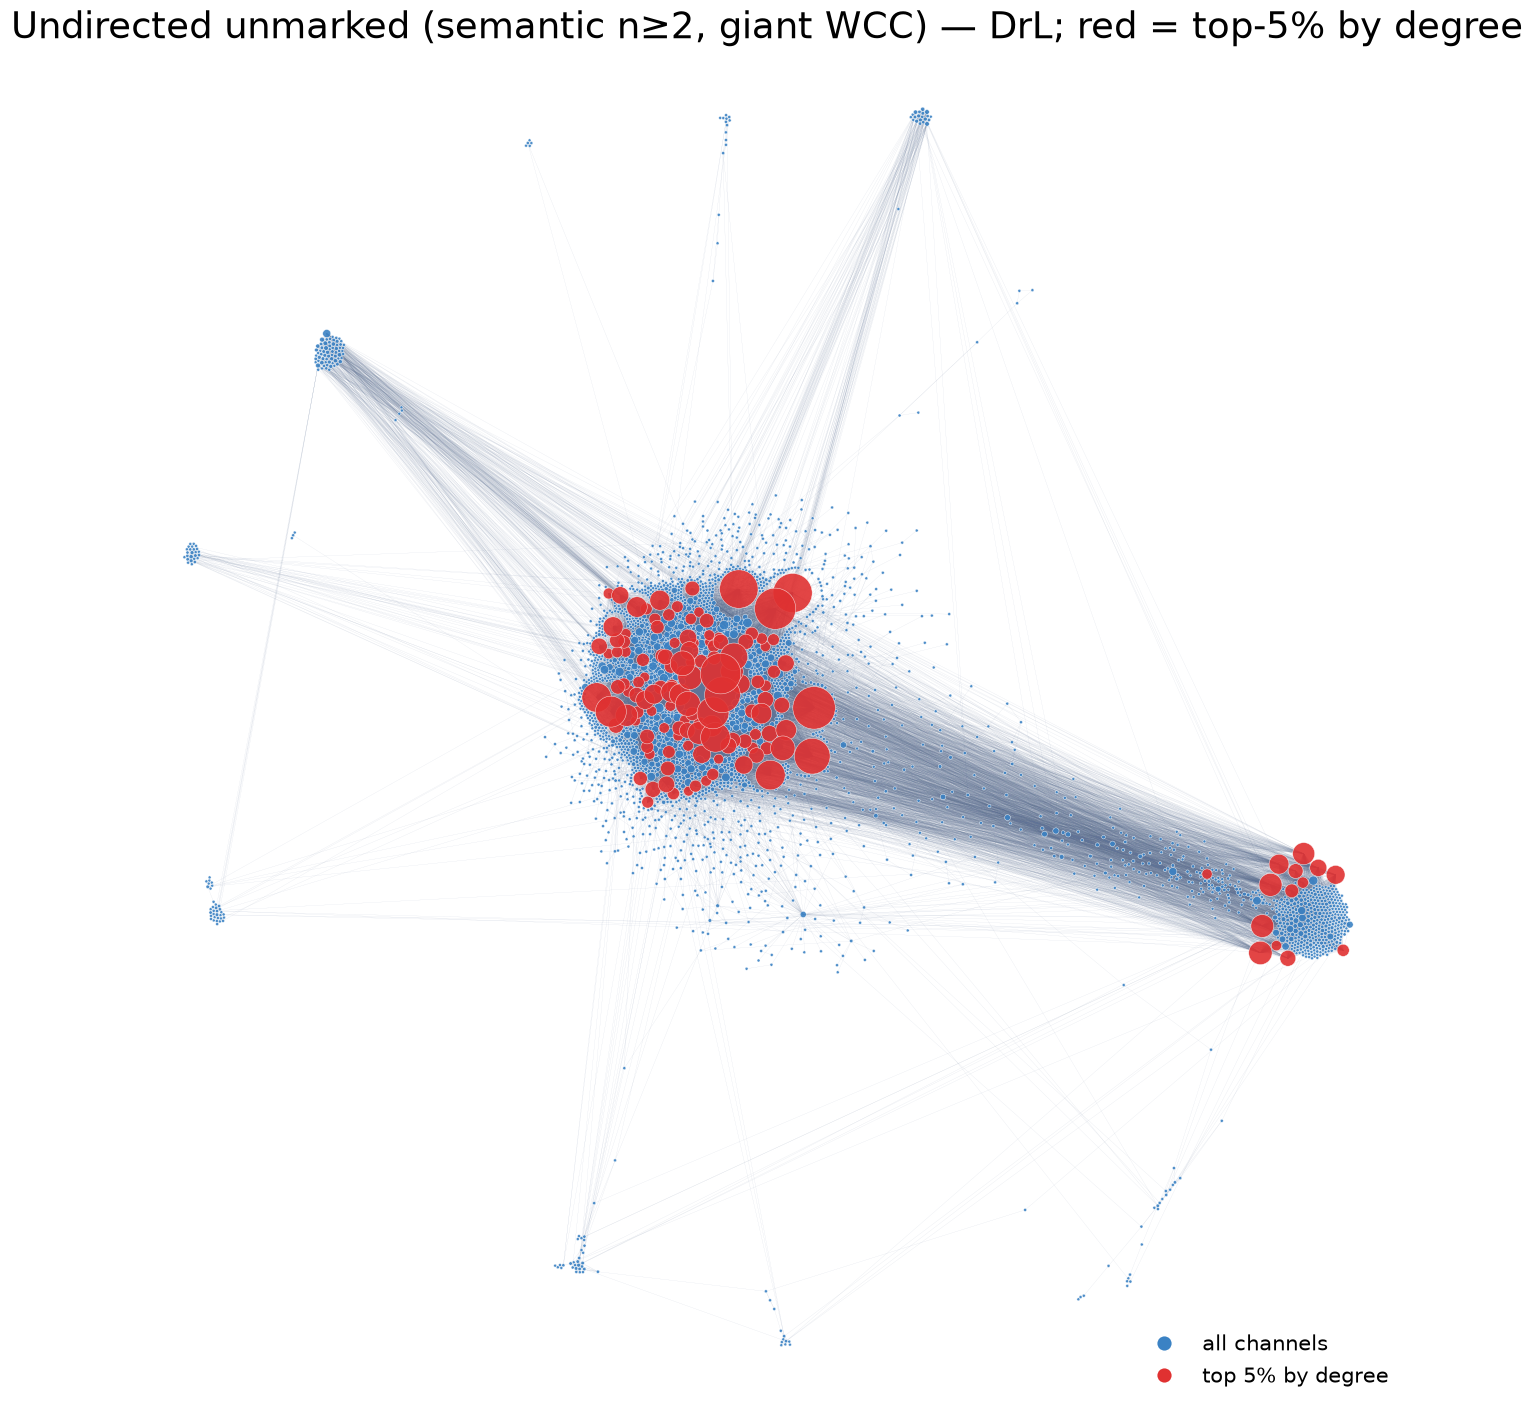

In [16]:
# » thesis: FIGURE 9 — the only figure of §4.2.2.
# ===== Undirected unmarked (semantic n≥2, giant WCC) — DrL layout with tweakable controls =====
import numpy as np, matplotlib.pyplot as plt
from matplotlib.collections import LineCollection, EllipseCollection
from matplotlib.lines import Line2D
from scipy.spatial import cKDTree

# ============ TWEAK THESE, then re-run the cell (Shift+Enter) ============
SIZE_POWER          = 1.2     # node size vs degree (higher = hubs balloon more)
HUB_SIZE            = 0.016   # biggest-hub radius as a fraction of the frame
COMPRESS_PCT        = 10      # radial compression: lower = tighter/smaller graph (1..100)
LABELS              = 0       # how many top hubs to label
EDGE_ALPHA          = 0.5    # edge opacity
REPEL               = True    # spread nodes apart, degree-weighted (~10s)
REPEL_STRENGTH      = 1.05    # how hard they push apart (1.0..1.6)
PREVENT_ALL_OVERLAP = True    # strict zero-overlap packing; graph grows to fit (~13s)
LAYOUT_SEED         = 0       # change this number to reshuffle the DrL layout
# ========================================================================

_G = G_UND_GIANT
htot = np.array(_G.degree(), dtype=float)   # undirected degree
hnames = np.array(_G.vs['name'])
_rng = np.random.default_rng(42)

from matplotlib.colors import to_rgb
_deg = dict(zip(G_UND_GIANT.vs['name'], G_UND_GIANT.degree()))
_TOP = set(sorted(_deg, key=lambda h: -_deg[h])[:max(1, int(len(_deg) * 0.05))])   # top 5% by undirected degree
_PAL = {'hi': '#e03131', 'b': '#3b82c4'}
hrgb = np.array([to_rgb(_PAL['hi'] if h in _TOP else _PAL['b']) for h in hnames])

def hub_compress(coords, pct):
    if pct >= 100:
        return coords
    ctr = np.average(coords, axis=0, weights=htot); d = coords - ctr
    r = np.hypot(d[:, 0], d[:, 1]); r = np.where(r == 0, 1e-9, r); a = np.percentile(r, pct)
    return ctr + d * (a * np.arcsinh(r / a) / r)[:, None]

def hub_radii(coords, power, hub_frac):
    ext = max(np.ptp(coords[:, 0]), np.ptp(coords[:, 1]))
    return 0.0012 * ext + hub_frac * ext * (htot / htot.max()) ** power

def hub_repel(coords, radii, strength=1.05, full=False):
    coords = coords.copy()
    w = (htot / htot.max()) ** 0.5 + 0.15
    iters = 220 if full else 150; pad = strength
    lo0, hi0 = coords.min(0), coords.max(0); ctr0 = (lo0 + hi0) / 2; span0 = float((hi0 - lo0).max())
    for _ in range(iters):
        pairs = cKDTree(coords).query_pairs(r=2 * radii.max() * pad, output_type='ndarray')
        if len(pairs) == 0:
            break
        i, j = pairs[:, 0], pairs[:, 1]; delta = coords[i] - coords[j]; dist = np.hypot(delta[:, 0], delta[:, 1])
        ov = (radii[i] + radii[j]) * pad - dist; m = ov > 0
        if not m.any():
            break
        i, j, dst, d2, ovm = i[m], j[m], dist[m], delta[m], ov[m]; z = dst < 1e-9
        dirv = np.where(z[:, None], _rng.standard_normal((len(i), 2)),
                        d2 / np.where(dst[:, None] < 1e-9, 1, dst[:, None]))
        dirv /= np.hypot(dirv[:, 0], dirv[:, 1])[:, None]
        wi, wj = w[i], w[j]; sN = wi + wj
        shift = np.zeros_like(coords)
        np.add.at(shift, i,  dirv * (wi / sN * ovm)[:, None])
        np.add.at(shift, j, -dirv * (wj / sN * ovm)[:, None])
        mag = np.hypot(shift[:, 0], shift[:, 1]); cap = radii * 0.6
        sc = np.where(mag > cap, cap / np.where(mag == 0, 1, mag), 1.0)
        coords = coords + shift * sc[:, None]
    if not full:
        lo, hi = coords.min(0), coords.max(0); span = float((hi - lo).max())
        if span > span0:
            ctr = (lo + hi) / 2; coords = ctr0 + (coords - ctr) * (span0 / span)
    return coords

def hub_layout(base_coords, power, hub_frac, compress_pct, repel, repel_strength, no_overlap):
    coords = hub_compress(base_coords, compress_pct)
    radii = hub_radii(coords, power, hub_frac)
    if no_overlap:
        coords = hub_repel(coords, radii, strength=repel_strength, full=True)
    elif repel:
        coords = hub_repel(coords, radii, strength=repel_strength, full=False)
    return coords

# base DrL layout, cached by LAYOUT_SEED (changing the seed reshuffles; other tweaks reuse it)
try:
    _LAYOUTS_U
except NameError:
    _LAYOUTS_U = {}
if LAYOUT_SEED not in _LAYOUTS_U:
    _LAYOUTS_U[LAYOUT_SEED] = np.array(_G.layout_drl())
hub_base = _LAYOUTS_U[LAYOUT_SEED]
coords = hub_layout(hub_base, SIZE_POWER, HUB_SIZE, COMPRESS_PCT, REPEL, REPEL_STRENGTH, PREVENT_ALL_OVERLAP)
radii = hub_radii(coords, SIZE_POWER, HUB_SIZE)
_TITLE = 'Undirected unmarked (semantic n≥2, giant WCC) — DrL; red = top-5% by degree'

FIG = 13                                # figure size (inches); all fonts scale with it
_fs = lambda frac: frac * FIG * 72      # points = fraction of the figure (dpi-independent)
fig, ax = plt.subplots(figsize=(FIG, FIG))
ax.add_collection(LineCollection([[coords[e.source], coords[e.target]] for e in _G.es],
                                 colors='#5f7396', linewidths=0.06, alpha=EDGE_ALPHA, zorder=1))
o = np.argsort(htot)
ax.add_collection(EllipseCollection(2 * radii[o], 2 * radii[o], np.zeros(_G.vcount()), units='xy',
    offsets=coords[o], transOffset=ax.transData, facecolors=hrgb[o],
    edgecolors='white', linewidths=0.3, alpha=0.9, zorder=2))
for i in np.argsort(htot)[::-1][:LABELS]:
    ax.text(coords[i, 0], coords[i, 1], hnames[i], fontsize=_fs(0.011), ha='center', va='center',
            zorder=3, bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.7))
ax.set_aspect('equal'); ax.autoscale_view(); ax.set_axis_off()
ax.set_title(_TITLE, fontsize=_fs(0.026))
_handles = [Line2D([0], [0], marker='o', ls='', mfc=_PAL['b'], mec='white', ms=_fs(0.011), label='all channels'),
            Line2D([0], [0], marker='o', ls='', mfc=_PAL['hi'], mec='white', ms=_fs(0.011), label='top 5% by degree')]
ax.legend(handles=_handles, loc='lower right', frameon=False, fontsize=_fs(0.015))
plt.tight_layout(); plt.show()


### ¶2 · Concentration in the directed layer, and the two disjoint top-20 lists

Feeds *"top-1% … **8** channels each posting first in at least **17** relationships … **292**
of the layer's **1,763** edges … **16.6%**"*, the top-5% and in-degree tiers, the **zero**
overlap between the top-20 by in-degree and by out-degree, and `@bbbreaking`'s **114** outgoing
edges (6.5% of the layer). The out-degree list is the one that turns out to be populated by
Russian news agencies and state broadcasters.

In [17]:
# » thesis: §4.2.2 ¶2 (both top-20 tables, the tier concentrations, the 0/20 overlap) and
#          the source handles named in §4.2.2 per-node ¶. "Attachment to UNDIRECTED-degree hubs" is uncited.
# ===== hubs: DIRECTED self-concentration (out/in-degree tiers) + top-20 tables + overlaps (semantic, GIANT WCC) =====
import pandas as _pd
_nd = _pd.read_csv(DATA / 'nodes.csv'); _lg = dict(zip(_nd.handle, _nd.language))
_gu = G_UND_GIANT; _unm = _gu.vs['name']; _udeg = dict(zip(_unm, _gu.degree()))
_urank = {h: i + 1 for i, h in enumerate(sorted(_udeg, key=lambda h: -_udeg[h]))}
_gd = G_DIR_GIANT; _dn = _gd.vs['name']
_ind = dict(zip(_dn, _gd.degree(mode='in'))); _out = dict(zip(_dn, _gd.degree(mode='out')))
_de = [(_dn[e.source], _dn[e.target]) for e in _gd.es]; _M = len(_de)
print(f"Directed giant: {len(_dn):,} nodes / {_M:,} edges | undirected giant: {len(_unm):,} nodes")

# --- top-20 by OUT-degree: handle, language, out-degree, in-degree, undirected-degree + rank ---
_to = sorted(_dn, key=lambda h: -_out[h])[:20]
print('\nTop 20 by OUT-degree:')
display(_pd.DataFrame([{'handle': h, 'language': _lg.get(h), 'out-degree': _out[h], 'in-degree': _ind[h],
                        'undir degree': _udeg.get(h, 0), 'undir rank': _urank.get(h, '—')} for h in _to]))
# --- companion: top-20 by IN-degree ---
_ti = sorted(_dn, key=lambda h: -_ind[h])[:20]
print('Top 20 by IN-degree:')
display(_pd.DataFrame([{'handle': h, 'language': _lg.get(h), 'in-degree': _ind[h], 'out-degree': _out[h],
                        'undir degree': _udeg.get(h, 0), 'undir rank': _urank.get(h, '—')} for h in _ti]))

# --- overlaps of the top-20 lists (with handles) ---
_tu = sorted(_udeg, key=lambda h: -_udeg[h])[:20]
_ov_uo = set(_tu) & set(_to); _ov_io = set(_ti) & set(_to)
print(f'overlap  top-20 undirected-degree ∩ top-20 out-degree : {len(_ov_uo)}/20 -> {sorted(_ov_uo)}')
print(f'overlap  top-20 in-degree ∩ top-20 out-degree         : {len(_ov_io)}/20 -> {sorted(_ov_io)}')

# --- concentration by OUT-degree (share originating) and IN-degree (share terminating) ---
def _tier_conc(dmap, role):
    rank = sorted(dmap, key=lambda h: -dmap[h]); N = len(rank)
    print(f'\nConcentration by {role.upper()}-degree (of {_M:,} directed edges):')
    for pct in (0.01, 0.05):
        k = max(1, int(N * pct)); T = set(rank[:k]); thr = dmap[rank[k - 1]]
        if role == 'out':
            hit = sum(1 for s, t in _de if s in T); verb = 'originate at'
        else:
            hit = sum(1 for s, t in _de if t in T); verb = 'terminate at'
        print(f'  top {pct:.0%} = {k} channels ({role}-degree ≥ {thr}): {hit:,}/{_M:,} edges {verb} the tier = {hit/_M:.1%}')
_tier_conc(_out, 'out')
_tier_conc(_ind, 'in')

# --- attachment of the directed edges to UNDIRECTED-degree hubs (unchanged view) ---
_rank = sorted(_udeg, key=lambda h: -_udeg[h]); _N = len(_rank)
print(f'\nAttachment to UNDIRECTED-degree hubs:')
for _pct in (0.01, 0.05):
    _k = max(1, int(_N * _pct)); _top = set(_rank[:_k]); _thr = _udeg[_rank[_k - 1]]
    _si = sum(1 for s, t in _de if s in _top); _tt = sum(1 for s, t in _de if t in _top)
    print(f'  top {_pct:.0%} = {_k} ch (degree ≥ {_thr}): originate {_si:,}/{_M:,} ({_si/_M:.1%}) · '
          f'target {_tt:,}/{_M:,} ({_tt/_M:.1%})')

Directed giant: 880 nodes / 1,763 edges | undirected giant: 2,776 nodes

Top 20 by OUT-degree:


,handle,language,out-degree,in-degree,undir degree,undir rank
0,bbbreaking,ru,114,1,355,12
1,ostashkonews,ru,43,0,231,37
2,pul_nomer_3,ru,34,10,424,7
3,tass_agency,ru,29,0,100,154
4,spravdi,uk,21,3,244,33
5,dimsmirnov175,ru,17,0,67,264
6,rentv_news,ru,17,1,129,115
7,stranaua,ru,17,0,96,166
8,zvezdanews,ru,17,0,95,167
9,angelika_vz,ru,16,5,382,8


Top 20 by IN-degree:


,handle,language,in-degree,out-degree,undir degree,undir rank
0,allratings,ru,34,0,453,5
1,meerzonaa,ru,32,5,475,3
2,polit_anarx,ru,32,3,460,4
3,selskyrozum,cs,31,4,333,13
4,druschbafm_rus,ru,27,0,124,121
5,gruntmedia,uk,23,7,210,43
6,nash_prezident_putin,ru,23,12,496,1
7,swodki,ru,22,4,357,11
8,belshkvarka,ru,20,6,271,23
9,agendakyiv,uk,19,0,231,36


overlap  top-20 undirected-degree ∩ top-20 out-degree : 4/20 -> ['angelika_vz', 'bbbreaking', 'mriya24', 'pul_nomer_3']
overlap  top-20 in-degree ∩ top-20 out-degree         : 0/20 -> []

Concentration by OUT-degree (of 1,763 directed edges):
  top 1% = 8 channels (out-degree ≥ 17): 292/1,763 edges originate at the tier = 16.6%
  top 5% = 44 channels (out-degree ≥ 7): 694/1,763 edges originate at the tier = 39.4%

Concentration by IN-degree (of 1,763 directed edges):
  top 1% = 8 channels (in-degree ≥ 22): 224/1,763 edges terminate at the tier = 12.7%
  top 5% = 44 channels (in-degree ≥ 8): 645/1,763 edges terminate at the tier = 36.6%

Attachment to UNDIRECTED-degree hubs:
  top 1% = 27 ch (degree ≥ 255): originate 318/1,763 (18.0%) · target 359/1,763 (20.4%)
  top 5% = 138 ch (degree ≥ 115): originate 791/1,763 (44.9%) · target 907/1,763 (51.4%)


### ¶3 · Juxtaposition — the 27 undirected hubs seen through the directed layer

Feeds *"all **27** of the top 1% and **137** of the **138** of the top 5% present"*, *"**18 out
of 27** holding more incoming than outgoing edges"*, `@allratings` (34 incoming, none outgoing)
against `@bbbreaking` (114 outgoing, one incoming), the aggregate **359 vs 318**, and the
ρ = 0.452 caveat that a channel's out-degree partly tracks how much it posts.

In [18]:
# » thesis: ¶3 (parts 1-3) and the ρ = 0.452 caveat in §4.2.2 per-node ¶ (part 6).
#          Part 4 is restated by the next cell; part 5 (McNemar) is a supplementary check.
# ===== directed unidirectional n≥5 vs undirected-degree hubs (semantic, GIANT WCC) =====
import pandas as _pd, numpy as _np
from scipy.stats import chi2 as _chi2
_nd = _pd.read_csv(DATA / 'nodes.csv'); _lg = dict(zip(_nd.handle, _nd.language))
_gu = G_UND_GIANT; _nm = _gu.vs['name']; _ud = dict(zip(_nm, _gu.degree()))
_gd = G_DIR_GIANT; _dn = _gd.vs['name']; _dset = set(_dn)
_ind = dict(zip(_dn, _gd.degree(mode='in'))); _out = dict(zip(_dn, _gd.degree(mode='out')))
_de = [(_dn[e.source], _dn[e.target]) for e in _gd.es]
_rank = sorted(_ud, key=lambda h: -_ud[h]); _urank = {h: i + 1 for i, h in enumerate(_rank)}; _n = len(_rank)
_top1 = set(_rank[:max(1, int(_n * 0.01))]); _top5 = set(_rank[:max(1, int(_n * 0.05))])

print("1) presence of undirected-degree hubs in the directed set:")
print(f"   top 1%  : {sum(h in _dset for h in _top1)}/{len(_top1)} channels appear")
print(f"   top 5%  : {sum(h in _dset for h in _top5)}/{len(_top5)} channels appear")

print(f"\n2) the {len(_top1)} top-1% undirected-degree channels:")
_t = [{'handle': h, 'language': _lg.get(h), 'undir degree': _ud[h],
       'dir in': _ind.get(h, 0), 'dir out': _out.get(h, 0),
       'out/(in+out)': round(_out.get(h, 0) / (_ind.get(h, 0) + _out.get(h, 0)), 2)
                       if (_ind.get(h, 0) + _out.get(h, 0)) else None}
      for h in sorted(_top1, key=lambda h: -_ud[h])]
display(_pd.DataFrame(_t))
_have = [r for r in _t if r['out/(in+out)'] is not None]
_lean = sum(1 for r in _have if r['out/(in+out)'] < 0.5)
print(f"   of these {len(_t)}: {_lean}/{len(_have)} lean INCOMING (out/(in+out) < 0.5), "
      f"{sum(1 for r in _have if r['out/(in+out)'] > 0.5)} lean outgoing, {len(_t)-len(_have)} have no directed edges")

print("3) aggregate directed in- vs out-degree over the tier:")
for _lbl, _s in [(f'top 1% ({len(_top1)})', _top1), (f'top 5% ({len(_top5)})', _top5)]:
    _ai = sum(_ind.get(h, 0) for h in _s); _ao = sum(_out.get(h, 0) for h in _s)
    print(f"   {_lbl}: in-degree {_ai:,}  vs  out-degree {_ao:,}  (out share {_ao/(_ai+_ao):.1%})")

print("\n4) reverse view — top 20 by directed out-degree, with their undirected degree/rank:")
_to = sorted(_dn, key=lambda h: -_out[h])[:20]
display(_pd.DataFrame([{'handle': h, 'dir out': _out[h], 'undir degree': _ud.get(h, 0),
                        'undir rank': _urank.get(h, '—')} for h in _to]))

print("5) source/target asymmetry — discordant counts + McNemar (continuity-corrected):")
for _lbl, _s in [('top 1%', _top1), ('top 5%', _top5)]:
    _A = _B = _C = _Dn = 0
    for _src, _tgt in _de:
        _sh, _th = _src in _s, _tgt in _s
        if _sh and not _th: _A += 1
        elif _th and not _sh: _B += 1
        elif _sh and _th: _C += 1
        else: _Dn += 1
    _stat = (abs(_A - _B) - 1) ** 2 / (_A + _B) if (_A + _B) else float('nan')
    _pv = _chi2.sf(_stat, 1) if (_A + _B) else float('nan')
    print(f"   {_lbl}: A src-hub&tgt-not={_A}  B tgt-hub&src-not={_B}  C both={_C}  D neither={_Dn}"
          f"  | McNemar χ²={_stat:.2f}, p={_pv:.2e}")

print("\n6) do out-hubs simply publish more? Spearman(out-degree, total messages published) on the directed giant:")
from scipy.stats import spearmanr as _spr2, pearsonr as _psr2
_msg = dict(zip(_nd.handle, _pd.to_numeric(_nd.n_msgs, errors='coerce')))
_hs = [h for h in _dn if _out[h] > 0 and _pd.notna(_msg.get(h))]        # out-active channels with a message count
_od = _np.array([_out[h] for h in _hs]); _mc = _np.array([_msg[h] for h in _hs], dtype=float)
_rho, _pv6 = _spr2(_od, _mc); _r6, _pp6 = _psr2(_od, _mc)
print(f"   n={len(_hs):,} (out-degree>0) | Spearman rho={_rho:.3f} (p={_pv6:.2e}) | Pearson r={_r6:.3f} (p={_pp6:.2e})")

1) presence of undirected-degree hubs in the directed set:
   top 1%  : 27/27 channels appear
   top 5%  : 137/138 channels appear

2) the 27 top-1% undirected-degree channels:


,handle,language,undir degree,dir in,dir out,out/(in+out)
0,nash_prezident_putin,ru,496,23,12,0.34
1,osvedomitell,ru,482,19,12,0.39
2,meerzonaa,ru,475,32,5,0.14
3,polit_anarx,ru,460,32,3,0.09
4,allratings,ru,453,34,0,0.00
5,odessarussi,ru,424,15,8,0.35
6,pul_nomer_3,ru,424,10,34,0.77
7,angelika_vz,ru,382,5,16,0.76
8,mislim_vmeste,ru,372,16,8,0.33
9,lisichanskinfo,ru,357,16,3,0.16


   of these 27: 18/27 lean INCOMING (out/(in+out) < 0.5), 9 lean outgoing, 0 have no directed edges
3) aggregate directed in- vs out-degree over the tier:
   top 1% (27): in-degree 359  vs  out-degree 318  (out share 47.0%)
   top 5% (138): in-degree 907  vs  out-degree 791  (out share 46.6%)

4) reverse view — top 20 by directed out-degree, with their undirected degree/rank:


,handle,dir out,undir degree,undir rank
0,bbbreaking,114,355,12
1,ostashkonews,43,231,37
2,pul_nomer_3,34,424,7
3,tass_agency,29,100,154
4,spravdi,21,244,33
5,dimsmirnov175,17,67,264
6,rentv_news,17,129,115
7,stranaua,17,96,166
8,zvezdanews,17,95,167
9,angelika_vz,16,382,8


5) source/target asymmetry — discordant counts + McNemar (continuity-corrected):
   top 1%: A src-hub&tgt-not=296  B tgt-hub&src-not=337  C both=22  D neither=1108  | McNemar χ²=2.53, p=1.12e-01
   top 5%: A src-hub&tgt-not=406  B tgt-hub&src-not=522  C both=385  D neither=450  | McNemar χ²=14.25, p=1.60e-04

6) do out-hubs simply publish more? Spearman(out-degree, total messages published) on the directed giant:
   n=569 (out-degree>0) | Spearman rho=0.452 (p=5.87e-30) | Pearson r=0.220 (p=1.13e-07)


### ¶3 (cont.) · The inversion — top senders are also high-degree nodes

Feeds *"Top 20 out-degree nodes sit in the top **13%** degree nodes of the undirected layer and
**13** in the top 5%. If only produced by their presence in the directed layer, these figures
would be expected to stand at roughly **8** and **3**."*

In [19]:
# » thesis: ¶3 — "top 13% … and 13 in the top 5% … expected … roughly 8 and 3".
# ===== inversion: the top OUT-degree channels sit at unremarkable UNDIRECTED-degree ranks =====
import pandas as _pd, numpy as _np
_nd = _pd.read_csv(DATA / 'nodes.csv'); _lg = dict(zip(_nd.handle, _nd.language))
_gu = G_UND_GIANT; _unm = _gu.vs['name']; _udeg = dict(zip(_unm, _gu.degree())); _uN = len(_unm)
_urank = {h: i + 1 for i, h in enumerate(sorted(_udeg, key=lambda h: -_udeg[h]))}
_gd = G_DIR_GIANT; _dn = _gd.vs['name']; _out = dict(zip(_dn, _gd.degree(mode='out')))
_top = sorted(_dn, key=lambda h: -_out[h])[:20]
_rows = []
for _r, _h in enumerate(_top, 1):
    _ur = _urank.get(_h)
    _rows.append({'out rank': _r, 'handle': _h, 'language': _lg.get(_h), 'out-degree': _out[_h],
                  'undir degree': _udeg.get(_h, 0), 'undir rank': _ur if _ur else '—',
                  'undir percentile': (f'top {100*_ur/_uN:.0f}%' if _ur else '—')})
print(f"Top 20 by directed OUT-degree vs their standing in the undirected degree ranking (of {_uN:,} channels):")
display(_pd.DataFrame(_rows))
_ranks = [_urank[h] for h in _top if h in _urank]
_ntop5 = sum(1 for r in _ranks if r <= _uN * 0.05)
print(f"\nUndirected rank of the top-20 out-degree channels: median {int(_np.median(_ranks))} of {_uN:,} "
      f"(≈ top {100*_np.median(_ranks)/_uN:.0f}%); range {min(_ranks)}–{max(_ranks)}.")
print(f"Only {_ntop5}/{len(_ranks)} of them fall inside the top-5% by undirected degree — being a top sender "
      f"does not imply being a high-degree node.")

# --- observed vs chance: are the top-20 out-degree over-represented among high undirected degree? ---
_allpct = _np.array([100 * _urank[h] / _uN for h in _dn if h in _urank]); _n880 = len(_allpct)
_obs13 = sum(1 for h in _top if _urank.get(h, 10**9) <= _uN * 0.13)
_obs5 = sum(1 for h in _top if _urank.get(h, 10**9) <= _uN * 0.05)
_b13 = (_allpct <= 13).mean(); _b5 = (_allpct <= 5).mean()
print(f"\nObserved: {_obs13}/20 top-out-degree channels sit in the top-13% by undirected degree, {_obs5}/20 in the top-5%.")
print(f"Chance (a random 20 of the {_n880} directed-layer channels): top-13% base rate {_b13:.1%} -> expect "
      f"{20*_b13:.1f}; top-5% base rate {_b5:.1%} -> expect {20*_b5:.1f}.  Over-represented ~{_obs13/(20*_b13):.1f}x / ~{_obs5/(20*_b5):.1f}x.")

Top 20 by directed OUT-degree vs their standing in the undirected degree ranking (of 2,776 channels):


,out rank,handle,language,out-degree,undir degree,undir rank,undir percentile
0,1,bbbreaking,ru,114,355,12,top 0%
1,2,ostashkonews,ru,43,231,37,top 1%
2,3,pul_nomer_3,ru,34,424,7,top 0%
3,4,tass_agency,ru,29,100,154,top 6%
4,5,spravdi,uk,21,244,33,top 1%
5,6,dimsmirnov175,ru,17,67,264,top 10%
6,7,rentv_news,ru,17,129,115,top 4%
7,8,stranaua,ru,17,96,166,top 6%
8,9,zvezdanews,ru,17,95,167,top 6%
9,10,angelika_vz,ru,16,382,8,top 0%



Undirected rank of the top-20 out-degree channels: median 71 of 2,776 (≈ top 3%); range 7–348.
Only 13/20 of them fall inside the top-5% by undirected degree — being a top sender does not imply being a high-degree node.

Observed: 20/20 top-out-degree channels sit in the top-13% by undirected degree, 13/20 in the top-5%.
Chance (a random 20 of the 880 directed-layer channels): top-13% base rate 38.1% -> expect 7.6; top-5% base rate 15.6% -> expect 3.1.  Over-represented ~2.6x / ~4.2x.


---

## §4.3 · The intersection of the Czecho-Slovak and Russian space

The chapter's primary focus, and the point at which the Unmarked Network is compared against
what Chapter 3 found: a Czecho-Slovak community that was the most internally-facing in the
Marked Network.

### §4.3.1 · Table 7 · The Unmarked Network partition (Leiden)

*Thesis Table 7: Unmarked Network communities — size, conductance, language composition.*

Run exactly as in `marked_network.ipynb`: `leidenalg.ModularityVertexPartition`, `seed = SEED`,
`n_iterations = 10`, on the undirected layer at n≥2, giant component. The headline is negative:
where the marked partition isolated the linguistically distinct nodes into their own
communities, here **every** community is Russian-dominated and none has Czech or Slovak as its
second language. The language-coinciding communities dissolve.

In [20]:
# » thesis §4.3.1 — the Unmarked Network partition.
# ===== Leiden communities of the undirected unmarked layer (semantic n≥2, GIANT WCC) =====
# Mirrors marked_network.ipynb: ModularityVertexPartition, seed=SEED, n_iterations=10.
import math, leidenalg

_gl = G_UND_GIANT                                       # already undirected & simple
part_unm = leidenalg.find_partition(_gl, leidenalg.ModularityVertexPartition,
                                    seed=SEED, n_iterations=10)
memb_unm = np.array(part_unm.membership)                # node index -> community id
ncomm_unm = int(memb_unm.max() + 1)
comm_of = dict(zip(_gl.vs['name'], memb_unm.tolist()))  # handle -> community (reused downstream)

# edge decomposition per community
_internal = np.zeros(ncomm_unm, dtype=np.int64)
_boundary = np.zeros(ncomm_unm, dtype=np.int64)
for e in _gl.es:
    a, b = memb_unm[e.source], memb_unm[e.target]
    if a == b:
        _internal[a] += 1
    else:
        _boundary[a] += 1; _boundary[b] += 1
_2m = 2 * _gl.ecount()
_vol = 2 * _internal + _boundary
_cond = _boundary / np.minimum(_vol, _2m - _vol)

# language composition per community (canonical, original-text-only labels)
_csk = lambda l: 'cs+sk' if l in ('cs', 'sk') else l   # treat Czech + Slovak as one group
_lbn = np.array([_csk(lang.get(h, 'unknown')) for h in _gl.vs['name']])
_rows = []
for c in range(ncomm_unm):
    _ix = np.where(memb_unm == c)[0]; _tot = len(_ix)
    _lc = Counter(_lbn[_ix]); _top = _lc.most_common(3)
    _d1, _n1 = _top[0]
    _d2, _n2 = _top[1] if len(_top) > 1 else ('—', 0)
    _d3, _n3 = _top[2] if len(_top) > 2 else ('—', 0)
    _ent = abs(-sum((k / _tot) * math.log2(k / _tot) for k in _lc.values()))   # bits; abs -> no -0.0
    _rows.append({'size': _tot, 'internal_edges': int(_internal[c]), 'boundary_edges': int(_boundary[c]),
                  'conductance': round(float(_cond[c]), 3),
                  'dominant_lang': _d1, 'share_lang': round(_n1 / _tot, 3),
                  'dominant_lang_2': _d2, 'share_lang_2': round(_n2 / _tot, 3),
                  'dominant_lang_3': _d3, 'share_lang_3': round(_n3 / _tot, 3),
                  'lang_entropy': round(_ent, 3)})
communities_unm = (pd.DataFrame(_rows).sort_values('size', ascending=False)
                   .reset_index(drop=True).rename_axis('community'))
display(communities_unm)
print(f'{ncomm_unm} communities | modularity = {_gl.modularity(memb_unm):.3f} | seed = {SEED} (reproducible)')
print(f'graph: {_gl.vcount():,} nodes / {_gl.ecount():,} edges (undirected semantic n≥2, giant WCC)')

# --- language assortativity of this undirected layer (reported below the table) ---
def _assort(mp):
    _l = [mp(lang.get(h, 'unknown')) for h in _gl.vs['name']]
    _lv = sorted(set(_l)); _li = {l: k for k, l in enumerate(_lv)}
    return _gl.assortativity_nominal([_li[x] for x in _l], directed=False)
_a_sep = _assort(lang_bucket)                                  # per-language (cs, sk separate) — headline bucketing
_a_grp = _assort(lambda l: 'cs+sk' if l in ('cs', 'sk') else lang_bucket(l))
print(f'language assortativity (giant): {_a_sep:.3f} per-language  |  {_a_grp:.3f} with cs+sk merged')

,size,internal_edges,boundary_edges,conductance,dominant_lang,share_lang,dominant_lang_2,share_lang_2,dominant_lang_3,share_lang_3,lang_entropy
community,,,,,,,,,,,
0,611,5151,8080,0.440,ru,0.975,unknown,0.013,cs+sk,0.005,0.215
1,542,2992,2376,0.284,ru,0.900,uk,0.046,mk,0.018,0.695
2,540,6088,8901,0.422,ru,0.952,bg,0.013,unknown,0.007,0.432
3,340,1390,3150,0.531,ru,0.456,en,0.212,cs+sk,0.135,2.479
4,227,774,1947,0.557,ru,0.806,uk,0.167,unknown,0.009,0.872
5,147,299,847,0.586,ru,0.993,bg,0.007,—,0.000,0.059
6,137,581,939,0.447,ru,0.942,et,0.036,en,0.022,0.377
7,77,139,143,0.340,ru,1.000,—,0.000,—,0.000,0.000
8,33,81,66,0.289,ru,0.939,ro,0.061,—,0.000,0.330


35 communities | modularity = 0.333 | seed = 42 (reproducible)
graph: 2,776 nodes / 30,903 edges (undirected semantic n≥2, giant WCC)
language assortativity (giant): 0.082 per-language  |  0.095 with cs+sk merged


### The same run on the directed layer — and why its partition is not reported

Leiden on the confident directed set (unanimous, ≥5 votes; giant weak component, 880 nodes /
1,763 edges) by the same recipe. It partitions *better* — 18 communities at modularity 0.584
against 35 at 0.333 — but that is an artifact of sparsity, not structure: random subsamples of
the undirected layer drawn to the same edge count produce comparable modularity. Hence the
chapter reports the undirected partition and uses the directed layer only per node.

In [21]:
# » NEW — supports the paragraph that declines to report the directed layer's communities.
# ===== Leiden on the DIRECTED unmarked layer + the two controls that license omitting it =====
import math, leidenalg
from sklearn.metrics import adjusted_mutual_info_score as _ami, adjusted_rand_score as _ari

def _leiden(g, seed=SEED):
    return np.array(leidenalg.find_partition(g, leidenalg.ModularityVertexPartition,
                                             seed=seed, n_iterations=10).membership)

_gd  = G_DIR_GIANT
_gdu = _gd.as_undirected(mode='collapse')            # marked-notebook recipe
memb_dir  = _leiden(_gdu)
ncomm_dir = int(memb_dir.max() + 1)
comm_of_dir = dict(zip(_gd.vs['name'], memb_dir.tolist()))

_internal = np.zeros(ncomm_dir, dtype=np.int64); _boundary = np.zeros(ncomm_dir, dtype=np.int64)
for e in _gd.es:                                     # decomposition on the DIRECTED graph
    a, b = memb_dir[e.source], memb_dir[e.target]
    if a == b: _internal[a] += 1
    else:      _boundary[a] += 1; _boundary[b] += 1
_2m = 2 * _gd.ecount(); _vol = 2 * _internal + _boundary
_cond = _boundary / np.minimum(_vol, _2m - _vol)

_lbn = np.array([lang.get(h, 'unknown') for h in _gd.vs['name']])
_rows = []
for c in range(ncomm_dir):
    _ix = np.where(memb_dir == c)[0]; _tot = len(_ix)
    _lc = Counter(_lbn[_ix]); _top = _lc.most_common(2)
    _d1, _n1 = _top[0]; _d2, _n2 = _top[1] if len(_top) > 1 else ('—', 0)
    _ent = abs(-sum((k / _tot) * math.log2(k / _tot) for k in _lc.values()))
    _rows.append({'size': _tot, 'internal_edges': int(_internal[c]), 'boundary_edges': int(_boundary[c]),
                  'conductance': round(float(_cond[c]), 3),
                  'dominant_lang': _d1, 'share_lang': round(_n1 / _tot, 3),
                  'dominant_lang_2': _d2, 'share_lang_2': round(_n2 / _tot, 3),
                  'lang_entropy': round(_ent, 3)})
communities_dir = (pd.DataFrame(_rows).sort_values('size', ascending=False)
                   .reset_index(drop=True).rename_axis('community'))
display(communities_dir)
print(f'DIRECTED layer: {ncomm_dir} communities | modularity = {_gdu.modularity(memb_dir):.3f} | '
      f'{_gd.vcount():,} nodes / {_gd.ecount():,} edges')
print(f'UNDIRECTED layer (above): {ncomm_unm} communities | '
      f'modularity = {G_UND_GIANT.modularity(memb_unm):.3f} | '
      f'{G_UND_GIANT.vcount():,} nodes / {G_UND_GIANT.ecount():,} edges')

# ---- 1) what the confidence filter selects: volume and connectivity, in vs out -------------
_gu = G_UND_GIANT; _un = np.array(_gu.vs['name']); _inD = np.isin(_un, _gd.vs['name'])
_v = np.array([vol.get(h, 0) for h in _un]); _dg = np.array(_gu.degree())
print(f'\n[1] the filter is a volume proxy — it keeps {_gd.ecount():,} of the undirected layer\'s '
      f'{_gu.ecount():,} edges ({_gd.ecount()/_gu.ecount():.1%}):')
print(f'    median n_msgs        : {np.median(_v[_inD]):,.0f} inside the directed layer  vs  '
      f'{np.median(_v[~_inD]):,.0f} outside')
print(f'    median undir. degree : {np.median(_dg[_inD]):.0f} inside  vs  {np.median(_dg[~_inD]):.0f} outside')

# ---- 2) sparsity null: partition random equal-size subsamples of the UNDIRECTED layer ------
_rng = np.random.default_rng(SEED); _null = []
for _t in range(10):
    _keep = _rng.choice(_gu.ecount(), size=_gd.ecount(), replace=False)
    _gs = _gu.subgraph_edges(_keep.tolist(), delete_vertices=True)
    _gs = _gs.induced_subgraph(max(_gs.connected_components(), key=len))
    _m = _leiden(_gs)
    _null.append({'nodes': _gs.vcount(), 'edges': _gs.ecount(), 'communities': int(_m.max() + 1),
                  'modularity': round(_gs.modularity(_m), 3),
                  'AMI vs full undirected': round(_ami(_m.tolist(), [comm_of[h] for h in _gs.vs['name']]), 3)})
null_sparsity = pd.DataFrame(_null)
print(f'\n[2] sparsity null — 10 random {_gd.ecount():,}-edge subsamples of the undirected layer, '
      f'each partitioned the same way:')
print(f'    communities {null_sparsity.communities.min()}–{null_sparsity.communities.max()}  |  '
      f'modularity {null_sparsity.modularity.min():.3f}–{null_sparsity.modularity.max():.3f}   '
      f'-> the directed layer\'s {ncomm_dir} / {_gdu.modularity(memb_dir):.3f} is what thinning alone produces.')
display(null_sparsity)

# ---- 3) partition agreement — printed, then deliberately NOT used as the argument ----------
_both = [h for h in _gd.vs['name'] if h in comm_of]
_a = [comm_of_dir[h] for h in _both]; _b = [comm_of[h] for h in _both]
_sub = _gu.induced_subgraph([_gu.vs.find(name=h).index for h in _both])
_sub = _sub.induced_subgraph(max(_sub.connected_components(), key=len))
_ms  = _leiden(_sub); _sn = _sub.vs['name']
print(f'\n[3] partition agreement on the {len(_both):,} shared channels (NOT the argument — see markdown):')
print(f'    directed vs undirected            : AMI {_ami(_a, _b):.3f} | ARI {_ari(_a, _b):.3f}')
print(f'    sparsity null vs undirected (mean): AMI {null_sparsity["AMI vs full undirected"].mean():.3f}'
      f'  <- the directed partition agrees MORE than chance thinning, so a low AMI is no indictment')
print(f'    same 880 nodes, undirected edges  : AMI {_ami(_ms.tolist(), [comm_of[h] for h in _sn]):.3f}'
      f'  <- restricting the node set alone costs little; the edge selection is what moves the partition')

,size,internal_edges,boundary_edges,conductance,dominant_lang,share_lang,dominant_lang_2,share_lang_2,lang_entropy
community,,,,,,,,,
0,119,218,194,0.308,ru,0.866,bg,0.034,0.943
1,115,165,42,0.113,ru,0.826,uk,0.130,0.850
2,106,198,240,0.377,ru,0.962,en,0.019,0.288
3,81,101,109,0.350,ru,0.691,sk,0.062,1.885
4,64,87,125,0.418,ru,0.844,cs,0.047,0.964
5,52,60,85,0.415,ru,0.962,sk,0.019,0.274
6,50,68,68,0.333,ru,0.980,unknown,0.020,0.141
7,45,55,62,0.360,ru,0.644,sk,0.244,1.410
8,43,44,33,0.273,ru,1.000,—,0.000,0.000


DIRECTED layer: 18 communities | modularity = 0.584 | 880 nodes / 1,763 edges
UNDIRECTED layer (above): 35 communities | modularity = 0.333 | 2,776 nodes / 30,903 edges

[1] the filter is a volume proxy — it keeps 1,763 of the undirected layer's 30,903 edges (5.7%):
    median n_msgs        : 850 inside the directed layer  vs  360 outside
    median undir. degree : 27 inside  vs  3 outside



[2] sparsity null — 10 random 1,763-edge subsamples of the undirected layer, each partitioned the same way:
    communities 17–21  |  modularity 0.562–0.586   -> the directed layer's 18 / 0.584 is what thinning alone produces.


,nodes,edges,communities,modularity,AMI vs full undirected
0,922,1685,20,0.582,0.150
1,911,1697,19,0.577,0.150
2,903,1683,18,0.573,0.136
3,901,1683,18,0.571,0.151
4,901,1687,18,0.576,0.158
5,901,1686,19,0.571,0.173
6,925,1679,21,0.586,0.169
7,892,1698,18,0.562,0.141
8,916,1685,17,0.580,0.154
9,880,1685,20,0.565,0.167



[3] partition agreement on the 880 shared channels (NOT the argument — see markdown):
    directed vs undirected            : AMI 0.328 | ARI 0.215
    sparsity null vs undirected (mean): AMI 0.155  <- the directed partition agrees MORE than chance thinning, so a low AMI is no indictment
    same 880 nodes, undirected edges  : AMI 0.647  <- restricting the node set alone costs little; the edge selection is what moves the partition


### Where the minority-language channels landed

The census behind *"50 Czecho-Slovak channels are present in the undirected layer … out of
these 46 were partitioned into a single community, community number 3"*, and the same for the
English (72 of 80), German (13 of 15) and Spanish (13 of 13) channels that formed the separate
international community in the Marked Network.

In [22]:
# ===== where did the minority-language channels land in the undirected partition? =====
# Uses comm_of (handle -> Leiden community id) from the undirected-communities cell above.
import pandas as _pd
from collections import Counter as _C
_names = G_UND_GIANT.vs['name']
_df = _pd.DataFrame({'handle': _names,
                     'lang': [lang.get(h, 'unknown') for h in _names],
                     'comm': [comm_of[h] for h in _names]})
_csize = _df.groupby('comm').size().to_dict()
_dom = _df.groupby('comm').lang.agg(lambda s: s.value_counts().idxmax()).to_dict()   # community -> dominant lang
_ncomm = _df.comm.nunique()

def _where(group, label):
    sub = _df[_df.lang.isin(group)]; n = len(sub)
    by = sub.groupby('comm').size().sort_values(ascending=False)
    if n == 0:
        print(f"\n=== {label}: 0 channels in the giant ==="); return
    rows = [{'community': int(c), f'{label} here': int(k), 'community size': _csize[c],
             f'{label} share of community': round(k / _csize[c], 3),
             'share of group here': round(k / n, 3),
             'community dominant lang': _dom[c]} for c, k in by.items()]
    print(f"\n=== {label}: {n} channels in the giant, spread over {by.size} of {_ncomm} communities ===")
    display(_pd.DataFrame(rows))
    _maj = [int(c) for c, k in by.items() if k / _csize[c] > 0.5]
    print(f"  largest single-community share: {by.iloc[0]}/{n} = {by.iloc[0]/n:.1%} (community {int(by.index[0])}, "
          f"dominant {_dom[by.index[0]]}); communities where {label} is the MAJORITY: {_maj if _maj else 'none'}")

_where({'cs', 'sk'}, 'cs+sk')
_where({'uk'}, 'uk')
_where({'en'}, 'en')
_where({'es'}, 'es')   # Spanish
_where({'de'}, 'de')   # German


=== cs+sk: 50 channels in the giant, spread over 3 of 35 communities ===


,community,cs+sk here,community size,cs+sk share of community,share of group here,community dominant lang
0,3,46,340,0.135,0.92,ru
1,0,3,611,0.005,0.06,ru
2,2,1,540,0.002,0.02,ru


  largest single-community share: 46/50 = 92.0% (community 3, dominant ru); communities where cs+sk is the MAJORITY: none

=== uk: 65 channels in the giant, spread over 4 of 35 communities ===


,community,uk here,community size,uk share of community,share of group here,community dominant lang
0,4,38,227,0.167,0.585,ru
1,1,25,542,0.046,0.385,ru
2,2,1,540,0.002,0.015,ru
3,3,1,340,0.003,0.015,ru


  largest single-community share: 38/65 = 58.5% (community 4, dominant ru); communities where uk is the MAJORITY: none

=== en: 80 channels in the giant, spread over 5 of 35 communities ===


...

  largest single-community share: 72/80 = 90.0% (community 3, dominant ru); communities where en is the MAJORITY: none

=== es: 13 channels in the giant, spread over 1 of 35 communities ===


,community,es here,community size,es share of community,share of group here,community dominant lang
0,3,13,340,0.038,1.0,ru


  largest single-community share: 13/13 = 100.0% (community 3, dominant ru); communities where es is the MAJORITY: none

=== de: 15 channels in the giant, spread over 3 of 35 communities ===


,community,de here,community size,de share of community,share of group here,community dominant lang
0,3,13,340,0.038,0.867,ru
1,2,1,540,0.002,0.067,ru
2,4,1,227,0.004,0.067,ru


  largest single-community share: 13/15 = 86.7% (community 3, dominant ru); communities where de is the MAJORITY: none


### Figure 10 · Communities collapsed, showing language composition

*Thesis Figure 10.*

Each Leiden community as one node, area ∝ population, drawn as a pie of its language mix;
edge width = cross-community reuse relations. The marked network's counterpart is Figure 4.

layout seed = 42   (copy into LAYOUT_SEED to lock it in)


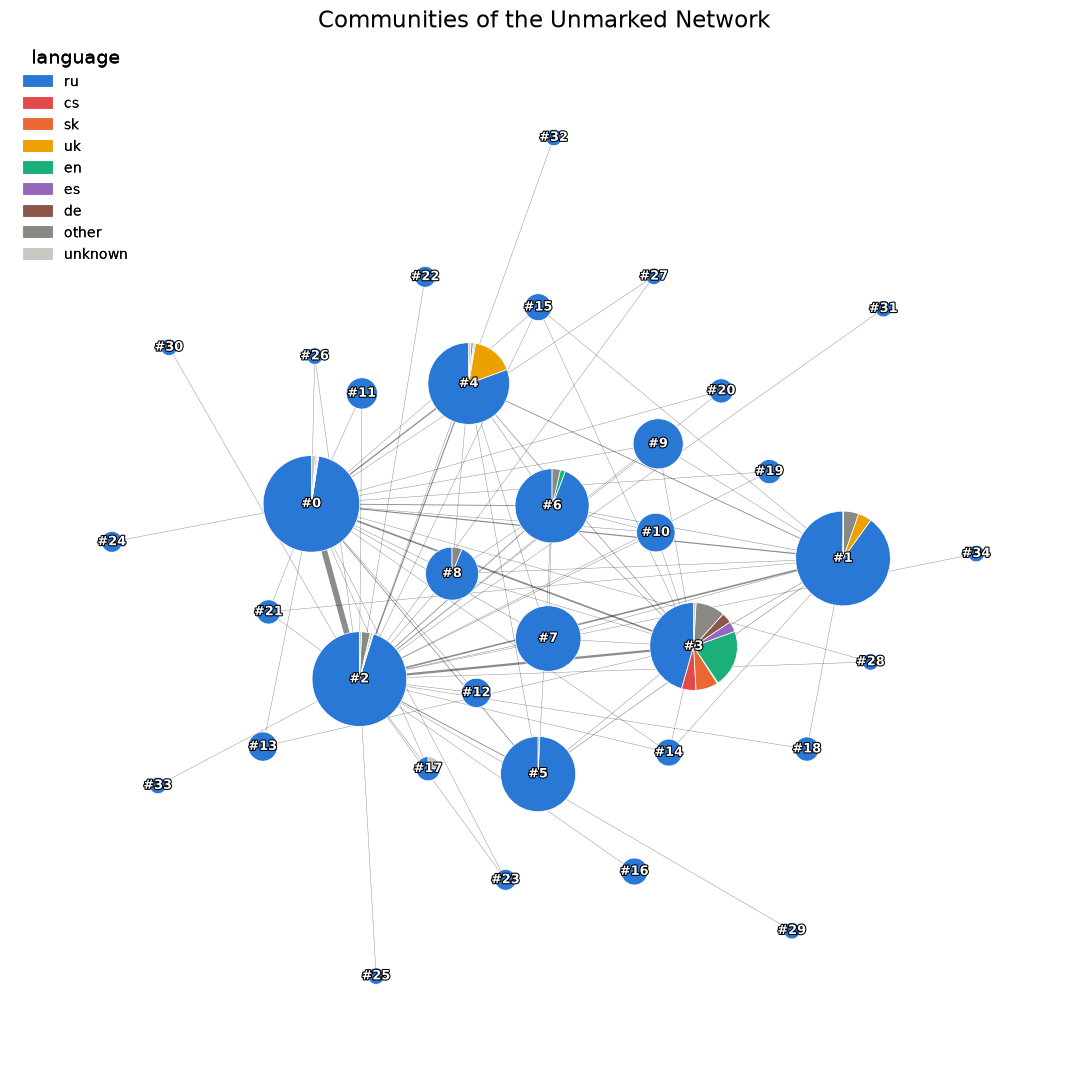

35 communities · 84 cross-community meta-edges · sizes 2–611


In [23]:
# ===== communities collapsed into pie-chart nodes (language composition) — style of marked_network.ipynb =====
import random, igraph as ig, numpy as np, matplotlib.pyplot as plt
import matplotlib.patches as mpatches, matplotlib.patheffects as pe
from collections import Counter
from matplotlib.path import Path as _MPath
from matplotlib.patches import PathPatch as _PathPatch

G = G_UND_GIANT
memb = memb_unm                                         # reuse the partition + numbering from the communities cell
_KEEP = {'ru', 'cs', 'sk', 'uk', 'en', 'es', 'de'}
_bkt = lambda l: l if l in _KEEP else ('unknown' if l == 'unknown' else 'other')
langs_arr = np.array([_bkt(lang.get(h, 'unknown')) for h in G.vs['name']])
_LC = {**LANG_COLORS, 'es': '#9467bd', 'de': '#8c564b'}   # es = purple, de = brown (own slices, not 'other')

comm_ids = sorted(set(memb.tolist())); n_comm = len(comm_ids)
csize = {c: int((memb == c).sum()) for c in comm_ids}
cid_to_idx = {c: i for i, c in enumerate(comm_ids)}
sizes = np.array([csize[c] for c in comm_ids], float)
lang_mix = {c: Counter(langs_arr[memb == c].tolist()) for c in comm_ids}

src = memb[[e.source for e in G.es]]; dst = memb[[e.target for e in G.es]]
pair_w = Counter()
for a, b in zip(src.tolist(), dst.tolist()):
    if a != b:
        pair_w[tuple(sorted((a, b)))] += 1
cg = ig.Graph(directed=False); cg.add_vertices(n_comm)
cg.add_edges([(cid_to_idx[a], cid_to_idx[b]) for a, b in pair_w]); cg.es['weight'] = [pair_w[q] for q in pair_w]

# ── re-run this cell to try a new layout ──────────────────────────────────
LAYOUT_SEED = 42        # int = reproducible; None = draw a fresh random seed (printed below)
LAYOUT_ALGO = 'fr'      # 'fr' | 'fr_noweight' | 'kk' | 'drl' | 'circle' | 'random'
LOG_SIZE    = True      # False = area ∝ population; True = logarithmic sizing (mellows the gap)
r_max       = 0.11      # radius of the largest community
SPREAD      = 1.9       # min gap between nodes = (r_i + r_j) * SPREAD; raise to space out
ROTATE      = 0         # rotate the whole graph by this many degrees (CCW)
EDGE_CLEAR  = 0.0       # gap kept between an edge and any node it is NOT incident to (0 = straight edges)
# ──────────────────────────────────────────────────────────────────────────

if LAYOUT_SEED is None:
    LAYOUT_SEED = int(np.random.default_rng().integers(0, 1_000_000))
print(f'layout seed = {LAYOUT_SEED}   (copy into LAYOUT_SEED to lock it in)')
random.seed(LAYOUT_SEED); rng = np.random.default_rng(LAYOUT_SEED)
start = rng.uniform(-1, 1, (n_comm, 2)).tolist()
if LAYOUT_ALGO == 'fr':          lay = cg.layout_fruchterman_reingold(weights='weight', seed=start)
elif LAYOUT_ALGO == 'fr_noweight': lay = cg.layout_fruchterman_reingold(seed=start)
elif LAYOUT_ALGO == 'kk':        lay = cg.layout_kamada_kawai(seed=start)
elif LAYOUT_ALGO == 'drl':       lay = cg.layout_drl(weights='weight')
elif LAYOUT_ALGO == 'circle':    lay = cg.layout_circle()
else:                            lay = start
coords = np.array(lay if isinstance(lay, list) else lay.coords, float)
coords -= coords.mean(0); coords /= np.abs(coords).max() + 1e-9

metric = np.log10(sizes + 1) if LOG_SIZE else np.sqrt(sizes)
rad = r_max * metric / metric.max()
for _ in range(600):                                    # push overlapping circles apart
    moved = False
    for i in range(n_comm):
        for j in range(i + 1, n_comm):
            d = coords[j] - coords[i]; dist = float(np.hypot(*d)); min_d = (rad[i] + rad[j]) * SPREAD
            if dist < min_d:
                if dist < 1e-9:
                    d = np.array([1e-3 * (j - i + 1), 1e-3]); dist = float(np.hypot(*d))
                u = d / dist; shift = (min_d - dist) / 2
                coords[i] -= u * shift; coords[j] += u * shift; moved = True
    if not moved:
        break
if ROTATE % 360:
    th = np.deg2rad(ROTATE); R = np.array([[np.cos(th), np.sin(th)], [-np.sin(th), np.cos(th)]])
    ctr = coords.mean(0); coords = (coords - ctr) @ R + ctr

pos = {c: coords[cid_to_idx[c]] for c in comm_ids}; rmap = {c: rad[cid_to_idx[c]] for c in comm_ids}
xs, ys = coords[:, 0], coords[:, 1]
lang_order = ['ru', 'cs', 'sk', 'uk', 'en', 'es', 'de', 'other', 'unknown']

FIG = 13; _fs = lambda frac: frac * FIG * 72
fig, ax = plt.subplots(figsize=(FIG, FIG * 10 / 13))

_obst = {c: (np.asarray(pos[c], float), rmap[c] + EDGE_CLEAR) for c in comm_ids}
def _route(a, b):
    p0, p1 = np.asarray(pos[a], float), np.asarray(pos[b], float)
    chord = p1 - p0; L = float(np.hypot(*chord))
    if L < 1e-9 or EDGE_CLEAR <= 0:
        return None
    nv = np.array([-chord[1], chord[0]]) / L
    obs = [(ctr, R) for c, (ctr, R) in _obst.items() if c not in (a, b)]
    ts = np.linspace(0, 1, 48)[:, None]
    def worst(k):
        ctrl = (p0 + p1) / 2 + k * nv
        B = (1 - ts) ** 2 * p0 + 2 * (1 - ts) * ts * ctrl + ts ** 2 * p1
        return min((np.hypot(*(B - ctr).T) - R).min() for ctr, R in obs)
    if not obs or worst(0.0) >= 0:
        return None
    for mag in np.linspace(0.03, 0.75, 40):
        for k in (mag, -mag):
            if worst(k) >= 0:
                return (p0 + p1) / 2 + k * nv
    return (p0 + p1) / 2 + max((0.75, -0.75), key=worst) * nv

max_w = max(pair_w.values())
for (a, b), w in pair_w.items():
    lw = 0.3 + 3.5 * (w / max_w); ctrl = _route(a, b)
    if ctrl is None:
        ax.plot([pos[a][0], pos[b][0]], [pos[a][1], pos[b][1]], color='black', lw=lw, alpha=0.45,
                zorder=1, solid_capstyle='round')
    else:
        ax.add_patch(_PathPatch(_MPath([pos[a], ctrl, pos[b]], [_MPath.MOVETO, _MPath.CURVE3, _MPath.CURVE3]),
                     fill=False, edgecolor='black', lw=lw, alpha=0.45, zorder=1, capstyle='round'))

for c in comm_ids:                                      # nodes = pies of language composition
    cx, cy = pos[c]; r = rmap[c]; tot = sum(lang_mix[c].values()); theta = 90.0
    for lg in lang_order:
        nn = lang_mix[c].get(lg, 0)
        if not nn:
            continue
        ang = 360.0 * nn / tot
        ax.add_patch(mpatches.Wedge((cx, cy), r, theta, theta + ang, facecolor=_LC[lg],
                     edgecolor='white', lw=0.5, zorder=3)); theta += ang
    ax.text(cx, cy, f'#{c}', ha='center', va='center', fontweight='bold', fontsize=_fs(0.009),
            color='white', zorder=4, path_effects=[pe.withStroke(linewidth=1.4, foreground='black')])

present = [lg for lg in lang_order if any(lg in lang_mix[c] for c in comm_ids)]
ax.add_artist(ax.legend(handles=[mpatches.Patch(color=_LC[lg], label=lg) for lg in present],
              loc='upper left', frameon=False, fontsize=_fs(0.010), title='language', title_fontsize=_fs(0.013)))
m = 0.12
ax.set_xlim(xs.min() - r_max - m, xs.max() + r_max + m)
ax.set_ylim(ys.min() - r_max - m, ys.max() + r_max + m)
ax.set_aspect('equal'); ax.axis('off')
ax.set_title('Communities of the Unmarked Network',
             fontsize=_fs(0.016))
plt.tight_layout(); plt.show()
print(f'{n_comm} communities · {len(pair_w):,} cross-community meta-edges · sizes {int(sizes.min())}–{int(sizes.max())}')

### Table 8 · Community 3 — the shared non-Russian reception community

*Thesis Table 8: language composition of Unmarked Network community 3.*

Where cs+sk, en, es and de all pool, each a minority in a Russian-dominant host: 45.6% ru,
21.2% en, 13.5% cs+sk, and 3.8% each for es / de / it, across at least 18 languages — a
language entropy nearly three times any other community's. The second cell derives the
community's c-TF-IDF content signature by the Chapter 3 recipe and compares its top-20 terms
against marked community 7, the international war-content community: 12 of 20 overlap. Same
topic, different membership.

In [24]:
# ===== FOCUS ON COMMUNITY 3 =====
import json as _json, math as _math, re as _re, numpy as _np, pandas as _pd, stopwordsiso as _sw
from collections import Counter as _C
_CID = 3
_names = G_UND_GIANT.vs['name']; _h2i = {h: i for i, h in enumerate(_names)}
_c3 = [h for h in _names if comm_of[h] == _CID]
_lg = lambda h: lang.get(h, 'unknown')

# ---------- 1) detailed language composition ----------
_lc = _C(_lg(h) for h in _c3)
_lang_tbl = _pd.DataFrame([{'language': l, 'channels': n, 'share': round(n / len(_c3), 3)}
                           for l, n in _lc.most_common()])
print(f"=== 1) COMMUNITY {_CID}: {len(_c3)} channels — language composition ===")
display(_lang_tbl)

# ---------- 2) content signature: c-TF-IDF (marked_network.ipynb recipe) ----------
_present3 = {_lg(h) for h in _c3}
_langs_used = sorted(_present3 & set(_sw.langs()))
_STOP = set(_sw.stopwords(_langs_used))
_JUNK = {'https', 'http', 'www', 'com', 'org', 'html', 'php', 'amp', 'quot', 'nbsp'}
_CTA = {'подписаться', 'подпишись', 'подписывайтесь', 'подписка', 'подписки', 'подпишитесь',
        'подписчики', 'репост', 'канал', 'канала', 'телеграм', 'sledujte', 'odber', 'odoberajte',
        'zdielajte', 'zdieľajte', 'sdilejte', 'subscribe', 'follow', 'channel', 'telegram', 'share', 'chat'}
_STOP |= _JUNK | _CTA
_HANDLES = {h.lower() for h in _names}; _isnum = _re.compile(r'^\d+$')
_keep = lambda t: len(t) >= 3 and t not in _STOP and t not in _HANDLES and not _isnum.match(t)
_terms = _json.load(open(DATA / 'channel_terms.json'))
_ncomm = int(memb_unm.max() + 1)
_bag = [_C() for _ in range(_ncomm)]; _tot = _np.zeros(_ncomm)
for _i, _h in enumerate(_names):
    _c = memb_unm[_i]; _tb = _terms.get(_h)
    if not _tb:
        continue
    for _w, _n in _tb['terms'].items():
        _wl = _w.lower()
        if _keep(_wl):
            _bag[_c][_wl] += _n; _tot[_c] += _n
_sizes = _C(memb_unm.tolist()); _MIN = 20
_big = [c for c in range(_ncomm) if _sizes[c] >= _MIN]; _Ndoc = len(_big)
_dfc = _C()
for _c in _big:
    for _w in _bag[_c]:
        _dfc[_w] += 1
_den = _tot[_CID] or 1
_sig = sorted(((w, (n / _den) * (_math.log((1 + _Ndoc) / (1 + _dfc[w])) + 1)) for w, n in _bag[_CID].items()),
              key=lambda x: -x[1])[:20]
print(f"\n=== 2) content signature — c-TF-IDF (stopwords for {len(_langs_used)} langs present in C{_CID}: "
      f"{','.join(_langs_used)}; {len(_STOP):,} stopwords) ===")
display(_pd.DataFrame(_sig, columns=['term', 'c-TF-IDF']).round(4))
c3_ctfidf_terms = [w for w, _ in _sig]   # exposed for the marked-C7 overlap cell


=== 1) COMMUNITY 3: 340 channels — language composition ===


,language,channels,share
0,ru,155,0.456
1,en,72,0.212
2,sk,28,0.082
3,cs,18,0.053
4,es,13,0.038
5,it,13,0.038
6,de,13,0.038
7,pl,7,0.021
8,pt,5,0.015
9,bg,4,0.012



=== 2) content signature — c-TF-IDF (stopwords for 17 langs present in C3: ar,bg,cs,da,de,en,es,et,fr,it,pl,pt,ro,ru,sk,sl,uk; 7,186 stopwords) ===


,term,c-TF-IDF
0,ukraine,0.0234
1,russian,0.0171
2,россии,0.0146
3,ukrainian,0.0141
4,forces,0.0109
5,сша,0.0107
6,afu,0.0092
7,biden,0.0091
8,people,0.0089
9,military,0.0088


In [25]:
# ===== overlap: unmarked C3  vs  marked C7 — top-20 c-TF-IDF terms (both = the en/es/de war-content community) =====
import pandas as _pd
# Marked network community 7 (languages: en 197, de 29, es 24) — its top-20 c-TF-IDF terms, taken verbatim from
# marked_network.ipynb (its c-TF-IDF cell). Hardcoded because this notebook is self-contained from data_final and
# does not rebuild the marked forward-projection / its Leiden partition.
_MARKED_C7 = ['ukraine', 'russian', 'ukrainian', 'forces', 'twitter', 'police', 'people', 'ucrania', 'afu', 'soledar',
              'military', 'armed', 'bakhmut', 'community', 'kiev', 'strategy', 'expert', 'biden', 'slg', 'briefings']
_UNM_C3 = c3_ctfidf_terms[:20]                              # unmarked community 3, computed in the focus cell above
_A, _B = set(_UNM_C3), set(_MARKED_C7)
_shared = [t for t in _UNM_C3 if t in _B]
_only_u = [t for t in _UNM_C3 if t not in _B]
_only_m = [t for t in _MARKED_C7 if t not in _A]
print('Top-20 c-TF-IDF overlap — unmarked C3  vs  marked C7  (both = the en/es/de multilingual war-content community)')
print(f'shared {len(_shared)}/20   |   Jaccard = {len(_A & _B) / len(_A | _B):.3f}')
_mx = max(len(_shared), len(_only_u), len(_only_m)); _pad = lambda L: L + [''] * (_mx - len(L))
display(_pd.DataFrame({f'shared ({len(_shared)})': _pad(_shared),
                       f'only unmarked C3 ({len(_only_u)})': _pad(_only_u),
                       f'only marked C7 ({len(_only_m)})': _pad(_only_m)}))
print('Reading: same community, same core lexicon (ukraine/russian/forces/afu/military/kiev …). The undeclared layer '
      'uniquely carries Russian-source terms (россии, сша), extra languages (ucraina=it, dołącz=pl) and infodefense — '
      'the translation-pipeline fingerprint; the declared layer leans native-English commentary (soledar, bakhmut, briefings).')
print('Caveat: the two runs use different corpora (each network\'s own communities as documents) and slightly different '
      'stopword unions, so the ~60% overlap is the robust figure, not the exact per-term deltas.')

Top-20 c-TF-IDF overlap — unmarked C3  vs  marked C7  (both = the en/es/de multilingual war-content community)
shared 12/20   |   Jaccard = 0.429


,shared (12),only unmarked C3 (8),only marked C7 (8)
0,ukraine,россии,police
1,russian,сша,soledar
2,ukrainian,news,bakhmut
3,forces,dołącz,community
4,afu,infodefense,strategy
5,biden,ucraina,expert
6,people,intelligence,slg
7,military,analysis,briefings
8,ucrania,,
9,twitter,,


Reading: same community, same core lexicon (ukraine/russian/forces/afu/military/kiev …). The undeclared layer uniquely carries Russian-source terms (россии, сша), extra languages (ucraina=it, dołącz=pl) and infodefense — the translation-pipeline fingerprint; the declared layer leans native-English commentary (soledar, bakhmut, briefings).
Caveat: the two runs use different corpora (each network's own communities as documents) and slightly different stopword unions, so the ~60% overlap is the robust figure, not the exact per-term deltas.


### Community 3 — cohesion and minority integration

T1/T2 put C3's internal structure against the whole giant — the density 0.0241 vs 0.0080, the
transitivity 0.279 vs 0.254, and the 98 / 174 / 53 bucket counts that show a small high-degree
core wrapped in a large periphery. T3/T4/T5 ask how each minority-language group reaches the
Russian channels: the **39.9%** median cs/sk-facing edge share used later, and the network-wide
inside/outside-C3 split.

In [26]:
# ===== C3 cohesion + minority integration — wide-focus tables =====
import numpy as _np, pandas as _pd
from collections import Counter as _C
_names = G_UND_GIANT.vs['name']; _h2i = {h: i for i, h in enumerate(_names)}
_lg = lambda h: lang.get(h, 'unknown')
_GROUPS = [('cs+sk', {'cs', 'sk'}), ('uk', {'uk'}), ('en', {'en'}), ('es', {'es'}), ('de', {'de'})]
def _home(grp):                                            # community holding the most of the group
    return _C(comm_of[h] for h in _names if _lg(h) in grp).most_common(1)[0][0]

# ---------- T1: cohesion — C3 (internal) vs whole giant (reference) ----------
_c3idx = [i for i, h in enumerate(_names) if comm_of[h] == 3]
_sub = G_UND_GIANT.induced_subgraph(_c3idx)
_gden = G_UND_GIANT.density()
def _coh(g):
    d = _np.array(g.degree())
    return {'nodes': g.vcount(), 'edges': g.ecount(), 'density': round(g.density(), 4),
            'density ×giant': round(g.density() / _gden, 1), 'mean deg': round(d.mean(), 1),
            'median deg': int(_np.median(d)), 'max deg': int(d.max()),
            '% deg≤1': f"{(d<=1).mean():.1%}", '% deg≤3': f"{(d<=3).mean():.1%}",
            'clustering': round(g.transitivity_undirected(mode='zero'), 3)}
T1 = _pd.DataFrame({'community 3 (internal)': _coh(_sub), 'whole giant (reference)': _coh(G_UND_GIANT)}).T
print("T1 — internal cohesion: C3 subgraph vs the whole giant (C3 metrics are computed within the C3 subgraph)")
display(T1)

# ---------- T2: internal degree distribution (buckets) ----------
def _buckets(g):
    d = _np.array(g.degree())
    return {'1': int((d == 1).sum()), '2-3': int(((d >= 2) & (d <= 3)).sum()),
            '4-7': int(((d >= 4) & (d <= 7)).sum()), '8-15': int(((d >= 8) & (d <= 15)).sum()),
            '16+': int((d >= 16).sum())}
T2 = _pd.DataFrame({'community 3 (internal deg)': _buckets(_sub), 'whole giant (degree)': _buckets(G_UND_GIANT)}).T
print("\nT2 — degree distribution (bucketed counts)")
display(T2)

# ---------- T3: minority-group integration into ru, WITHIN each group's home community ----------
_t3, _brokers_csk = [], _C()
for _lab, _grp in _GROUPS:
    _hc = _home(_grp)
    _gn = [h for h in _names if _lg(h) in _grp and comm_of[h] == _hc]
    _ru = {h for h in _names if _lg(h) == 'ru' and comm_of[h] == _hc}
    _bk = _C(); _per = []
    for _h in _gn:
        _rn = [_names[j] for j in G_UND_GIANT.neighbors(_h2i[_h]) if _names[j] in _ru]
        _per.append(len(_rn))
        for _x in _rn:
            _bk[_x] += 1
    _e = sum(_per); _t5 = sum(n for _, n in _bk.most_common(5)) / _e if _e else 0
    if _lab == 'cs+sk':
        _brokers_csk = _bk
    _t3.append({'group': _lab, 'home community': _hc, 'group nodes (in home)': len(_gn),
                'ru members (in home)': len(_ru), 'group→ru edges': _e,
                'median ru-neighbours/node': int(_np.median(_per)) if _per else 0,
                'distinct ru contacts': len(_bk), 'top-5 broker share': f"{_t5:.1%}"})
print("\nT3 — minority-group integration into ru, within each group's home community")
display(_pd.DataFrame(_t3).set_index('group'))

# ---------- T4: top ru brokers for cs/sk (within C3) ----------
_deg = dict(zip(_names, G_UND_GIANT.degree()))
_t4 = [{'ru broker': h, 'cs/sk links': n, 'giant degree': _deg[h], 'community': comm_of[h]}
       for h, n in _brokers_csk.most_common(10)]
print("\nT4 — top ru brokers channelling cs/sk (within community 3)")
display(_pd.DataFrame(_t4))

# ---------- T5: inside/outside split — ru channels touching each group (network-wide) ----------
_t5rows = []
for _lab, _grp in _GROUPS:
    _hc = _home(_grp)
    _ru_adj = set()
    for _h in [h for h in _names if _lg(h) in _grp]:
        for _j in G_UND_GIANT.neighbors(_h2i[_h]):
            if _lg(_names[_j]) == 'ru':
                _ru_adj.add(_names[_j])
    _in = sum(1 for h in _ru_adj if comm_of[h] == _hc); _out = len(_ru_adj) - _in
    _t5rows.append({'group': _lab, 'home community': _hc, 'ru channels touching group': len(_ru_adj),
                    'inside home community': _in, 'outside': _out,
                    '% inside': f"{_in/len(_ru_adj):.1%}" if _ru_adj else '—'})
print("\nT5 — inside/outside split: ru channels sharing ≥1 edge with the group (whole giant)")
display(_pd.DataFrame(_t5rows).set_index('group'))

T1 — internal cohesion: C3 subgraph vs the whole giant (C3 metrics are computed within the C3 subgraph)


,nodes,edges,density,density ×giant,mean deg,median deg,max deg,% deg≤1,% deg≤3,clustering
community 3 (internal),340,1390,0.0241,3.0,8.2,3,86,28.8%,51.2%,0.279
whole giant (reference),2776,30903,0.008,1.0,22.3,5,496,23.5%,43.3%,0.254



T2 — degree distribution (bucketed counts)


,1,2-3,4-7,8-15,16+
community 3 (internal deg),98,76,55,58,53
whole giant (degree),653,548,431,416,728



T3 — minority-group integration into ru, within each group's home community


,home community,group nodes (in home),ru members (in home),group→ru edges,median ru-neighbours/node,distinct ru contacts,top-5 broker share
group,,,,,,,
cs+sk,3,46,155,159,1,59,30.2%
uk,4,38,183,243,2,61,25.5%
en,3,72,155,38,0,22,44.7%
es,3,13,155,8,0,5,100.0%
de,3,13,155,14,1,8,78.6%



T4 — top ru brokers channelling cs/sk (within community 3)


,ru broker,cs/sk links,giant degree,community
0,allratings,18,453,3
1,akko_pomogaem,10,29,3
2,celno3or,8,110,3
3,buyantime,6,24,3
4,sovsecretno,6,35,3
5,newseconomics,5,98,3
6,pavlova_maria_live,5,79,3
7,ekaterinamechetina,5,9,3
8,grpatkz,5,9,3
9,kirillfedorov_free,5,12,3



T5 — inside/outside split: ru channels sharing ≥1 edge with the group (whole giant)


,home community,ru channels touching group,inside home community,outside,% inside
group,,,,,
cs+sk,3,442,59,383,13.3%
uk,4,622,67,555,10.8%
en,3,137,22,115,16.1%
es,3,77,5,72,6.5%
de,3,99,8,91,8.1%


### Does a Czecho-Slovak space survive without a community label?

The gating test. On the induced subgraph of the 46 cs/sk nodes in C3 — is it one connected
component (a real Czecho-Slovak space that merely lost its community label) or fragments and
isolates (mere co-attachment to shared brokers)? Judged against a degree-preserving
configuration null, which is what makes the **0.203 internal density, 6.7× what their degrees
predict** figure meaningful.

In [27]:
# ===== cs/sk cohesion =====
import numpy as np, pandas as pd, igraph as ig, random
from collections import Counter
RUN_HEAVY = False   # True also runs the marked-network like-for-like (T7): reproduces the marked partition (~30s)
G = G_UND_GIANT; names = G.vs['name']; gdeg = np.array(G.degree())
_csk = [i for i, h in enumerate(names) if comm_of[h] == 3 and lang.get(h) in ('cs', 'sk')]
_cskset = set(_csk); _c3set = {i for i, h in enumerate(names) if comm_of[h] == 3}
_L = lambda i: lang.get(names[i])
_sub = G.induced_subgraph(_csk); _sn = _sub.vs['name']
_comps = sorted(_sub.connected_components(), key=len, reverse=True)
_iso = int((np.array(_sub.degree()) == 0).sum()); _obs = _sub.ecount()
_c3sub = G.induced_subgraph(list(_c3set)); _c3med = int(np.median(_c3sub.degree()))

# --- degree-preserving configuration-model null (F8 pattern): expected cs/sk<->cs/sk edges ---
random.seed(42); _null = []
for _ in range(200):
    _rr = ig.Graph.Degree_Sequence(G.degree(), method='configuration')
    _null.append(sum(1 for e in _rr.es if e.source in _cskset and e.target in _cskset))
_null = np.array(_null)

# ---------- T1: cohesion summary ----------
T1 = pd.Series({
    'cs/sk nodes': len(_csk), 'edges among cs/sk': _obs, 'density': round(_sub.density(), 4),
    'C3-internal density (ref)': round(_c3sub.density(), 4), 'giant density (ref)': round(G.density(), 4),
    'connected components': len(_comps),
    'largest component': f"{len(_comps[0])} ({len(_comps[0])/len(_csk):.1%})", 'isolates': _iso,
    'expected edges (config null, 200×)': f"{_null.mean():.1f} ± {_null.std():.1f}",
    'observed / expected': f"{_obs/_null.mean():.1f}×",
    'z-score': round((_obs - _null.mean())/(_null.std()+1e-9), 1)}).to_frame('cs/sk induced subgraph')
print("T1 — cs/sk cohesion: induced subgraph of the 46 cs/sk nodes in C3, vs a degree-preserving null")
display(T1)

# ---------- T2: connected-components breakdown ----------
T2 = pd.DataFrame([{'component': k, 'size': len(c),
                    'cs': sum(1 for v in c if lang.get(_sn[v]) == 'cs'),
                    'sk': sum(1 for v in c if lang.get(_sn[v]) == 'sk')}
                   for k, c in enumerate(_comps)])
print("\nT2 — connected components of the cs/sk subgraph (one component = a surviving Czecho-Slovak space)")
display(T2)

# ---------- T3: per-node orientation ----------
_pr = []
for v in _csk:
    nb = G.neighbors(v); tot = len(nb)
    ncsk = sum(1 for x in nb if x in _cskset); nc3 = sum(1 for x in nb if x in _c3set)
    _pr.append({'handle': names[v], 'lang': _L(v), 'total degree': tot, 'C3-internal degree': nc3,
                'cs/sk neighbours': ncsk, 'share to cs/sk': round(ncsk/tot, 3) if tot else 0.0})
T3 = pd.DataFrame(_pr).sort_values('cs/sk neighbours', ascending=False).reset_index(drop=True)
_msh = np.median([r['share to cs/sk'] for r in _pr]); _mnb = int(np.median([r['cs/sk neighbours'] for r in _pr]))
_mc3 = int(np.median([r['C3-internal degree'] for r in _pr]))
print(f"\nT3 — per cs/sk node (sorted by cs/sk neighbours). Medians: share-to-cs/sk {_msh:.1%}, "
      f"cs/sk neighbours {_mnb}, C3-internal degree {_mc3} (vs C3 median {_c3med})")
display(T3)

# ---------- T4: cs/sk C3-internal degree distribution vs C3's median ----------
_cd = np.array([r['C3-internal degree'] for r in _pr])
_bk = lambda d: {'1': int((d == 1).sum()), '2-3': int(((d >= 2) & (d <= 3)).sum()),
                 '4-7': int(((d >= 4) & (d <= 7)).sum()), '8-15': int(((d >= 8) & (d <= 15)).sum()),
                 '16+': int((d >= 16).sum())}
T4 = pd.DataFrame({'cs/sk (C3-internal degree)': _bk(_cd),
                   'all C3 nodes (degree)': _bk(np.array(_c3sub.degree()))}).T
print(f"\nT4 — degree distribution: cs/sk within C3 vs all C3 nodes (C3 median degree = {_c3med})")
display(T4)

# ---------- T5: cs <-> sk integration — do Czech and Slovak nodes link to EACH OTHER? ----------
_slang = [lang.get(h) for h in _sn]
_cc = _ss = _x = 0
for e in _sub.es:
    a, b = _slang[e.source], _slang[e.target]
    if a == 'cs' and b == 'cs': _cc += 1
    elif a == 'sk' and b == 'sk': _ss += 1
    else: _x += 1
_li = {'cs': 0, 'sk': 1}
_cs_w_sk = sum(1 for v in range(_sub.vcount()) if _slang[v] == 'cs' and any(_slang[n] == 'sk' for n in _sub.neighbors(v)))
_sk_w_cs = sum(1 for v in range(_sub.vcount()) if _slang[v] == 'sk' and any(_slang[n] == 'cs' for n in _sub.neighbors(v)))
_keep = [e.index for e in _sub.es if {_slang[e.source], _slang[e.target]} != {'cs', 'sk'}]
_nox = _sub.subgraph_edges(_keep, delete_vertices=False)
_ncs, _nsk = _slang.count('cs'), _slang.count('sk')
T5 = pd.Series({
    'cs nodes': _ncs, 'sk nodes': _nsk,
    'cs–cs edges': f"{_cc} ({_cc/_obs:.1%})", 'sk–sk edges': f"{_ss} ({_ss/_obs:.1%})",
    'cs–sk CROSS edges': f"{_x} ({_x/_obs:.1%})",
    'cs nodes with ≥1 sk neighbour': f"{_cs_w_sk}/{_ncs}",
    'sk nodes with ≥1 cs neighbour': f"{_sk_w_cs}/{_nsk}",
    'within-group lang assortativity (cs vs sk)': round(_sub.assortativity_nominal([_li[l] for l in _slang], directed=False), 3),
    'components if cs–sk edges removed': f"{len(_nox.connected_components())} (was {len(_comps)})"}).to_frame('cs↔sk integration')
print("\nT5 — cs↔sk integration: do the Czech and Slovak nodes actually link to EACH OTHER?")
display(T5)

# ---------- T6: minority-group ru integration within each group's home community (union of v1 + v2) ----------
from collections import Counter as _Ctr
_GROUPS = [('cs+sk', {'cs', 'sk'}), ('uk', {'uk'}), ('en', {'en'}), ('es', {'es'}), ('de', {'de'})]
def _home(grp): return _Ctr(comm_of[h] for h in names if lang.get(h) in grp).most_common(1)[0][0]
_rows = []
for _lab, _grp in _GROUPS:
    _hc = _home(_grp)
    _gn = [v for v in range(len(names)) if lang.get(names[v]) in _grp and comm_of[names[v]] == _hc]
    _ru = {v for v in range(len(names)) if lang.get(names[v]) == 'ru' and comm_of[names[v]] == _hc}
    _bk = _Ctr(); _per = []
    for v in _gn:
        _rn = [x for x in G.neighbors(v) if x in _ru]
        _per.append(len(_rn))
        for x in _rn: _bk[x] += 1
    _e = sum(_per); _d = len(_bk); _t5 = sum(n for _, n in _bk.most_common(5)) / _e if _e else 0
    _rows.append({'group': _lab, 'home comm': _hc, 'nodes': len(_gn), 'ru members': len(_ru),
                  '→ru edges': _e, 'per node': round(_e / len(_gn), 2),
                  'median ru-nbrs': int(np.median(_per)) if _per else 0, 'distinct ru reached': _d,
                  "% of home ru": f"{_d/len(_ru):.1%}" if _ru else '—', 'top-5 broker share': f"{_t5:.1%}"})
T6 = pd.DataFrame(_rows).set_index('group')
print("\nT6 — minority-group ru integration, within each group's home community "
      "(union: per-node + %-of-ru from v2, median-neighbours + broker-share from v1)")
display(T6)

if RUN_HEAVY:
    # ---------- T7: like-for-like — cs/sk cluster in the MARKED network (its cs/sk community) ----------
    import csv as _csv, leidenalg as _la
    _MEM = set(pd.read_csv(DATA / 'nodes.csv').handle)
    # construction VERBATIM from marked_network.ipynb so the marked partition matches the Marked chapter (community 10)
    _fwd = []
    for r in _csv.DictReader(open(DATA / 'edges_forward.csv')):
        o, t, cnt = r['origin'], r['target'], int(r['count'])
        if o.startswith('id:') or o == t or cnt < 1: continue
        _fwd.append((o, t))
    _mn = sorted({n for e in _fwd for n in e}); _mi = {h: k for k, h in enumerate(_mn)}
    _gdm = ig.Graph(directed=True); _gdm.add_vertices(len(_mn)); _gdm.vs['name'] = _mn
    _gdm.add_edges([(_mi[o], _mi[t]) for o, t in _fwd])
    _gdm = _gdm.induced_subgraph(max(_gdm.connected_components(mode='weak'), key=len))
    _gum = _gdm.as_undirected(mode='collapse')
    _mm = np.array(_la.find_partition(_gum, _la.ModularityVertexPartition, seed=42, n_iterations=10).membership)
    mnames_marked = _gum.vs['name']; comm_marked = dict(zip(mnames_marked, _mm.tolist()))     # exposed for the battery cell
    _mh2i = {h: i for i, h in enumerate(mnames_marked)}
    csk_comm_m = max(set(_mm.tolist()), key=lambda c: sum(1 for v in np.where(_mm == c)[0] if lang.get(mnames_marked[v]) in ('cs', 'sk')))
    en_comm_marked = max(set(_mm.tolist()), key=lambda c: sum(1 for v in np.where(_mm == c)[0] if lang.get(mnames_marked[v]) == 'en'))
    _mcsk = [mnames_marked[v] for v in np.where(_mm == csk_comm_m)[0] if lang.get(mnames_marked[v]) in ('cs', 'sk')]
    _msub = _gum.induced_subgraph([_mh2i[h] for h in _mcsk]); _mcomp = sorted(_msub.connected_components(), key=len, reverse=True)
    _mbs = set(_mh2i[h] for h in _mcsk); random.seed(42); _mnull = []
    for _ in range(150):
        _rr = ig.Graph.Degree_Sequence(_gum.degree(), method='configuration')
        _mnull.append(sum(1 for e in _rr.es if e.source in _mbs and e.target in _mbs))
    _mnull = np.array(_mnull); _msl = [lang.get(h) for h in _msub.vs['name']]
    _mxx = sum(1 for e in _msub.es if {_msl[e.source], _msl[e.target]} == {'cs', 'sk'})
    def _lfl(sub, comp, nul, cross):
        return {'cs/sk nodes': sub.vcount(), 'internal edges': sub.ecount(), 'density': round(sub.density(), 4),
                'connected components': len(comp), 'largest component': f"{len(comp[0])} ({len(comp[0])/sub.vcount():.0%})",
                'isolates': int((np.array(sub.degree()) == 0).sum()),
                'observed/expected (config null)': f"{sub.ecount()/nul.mean():.1f}×",
                'cs–sk cross-edge share': f"{cross/sub.ecount():.0%}"}
    T7 = pd.DataFrame({'unmarked C3 (semantic reuse)': _lfl(_sub, _comps, _null, _x),
                       f'marked C{csk_comm_m} (declared forwards)': _lfl(_msub, _mcomp, _mnull, _mxx)})
    print(f"\nT7 — like-for-like: the cs/sk cluster in the UNMARKED network (C3) vs the MARKED network's cs/sk community (id {csk_comm_m})")
    display(T7)
else:
    print('\nT7 (marked-network like-for-like) skipped — set RUN_HEAVY = True to reproduce the marked partition')

T1 — cs/sk cohesion: induced subgraph of the 46 cs/sk nodes in C3, vs a degree-preserving null


,cs/sk induced subgraph
cs/sk nodes,46
edges among cs/sk,210
density,0.2029
C3-internal density (ref),0.0241
giant density (ref),0.008
connected components,2
largest component,45 (97.8%)
isolates,1
"expected edges (config null, 200×)",31.4 ± 5.3
observed / expected,6.7×



T2 — connected components of the cs/sk subgraph (one component = a surviving Czecho-Slovak space)


,component,size,cs,sk
0,0,45,17,28
1,1,1,1,0



T3 — per cs/sk node (sorted by cs/sk neighbours). Medians: share-to-cs/sk 39.9%, cs/sk neighbours 7, C3-internal degree 12 (vs C3 median 3)


...


T5 — cs↔sk integration: do the Czech and Slovak nodes actually link to EACH OTHER?


,cs↔sk integration
cs nodes,18
sk nodes,28
cs–cs edges,28 (13.3%)
sk–sk edges,59 (28.1%)
cs–sk CROSS edges,123 (58.6%)
cs nodes with ≥1 sk neighbour,17/18
sk nodes with ≥1 cs neighbour,27/28
within-group lang assortativity (cs vs sk),-0.198
components if cs–sk edges removed,14 (was 2)



T6 — minority-group ru integration, within each group's home community (union: per-node + %-of-ru from v2, median-neighbours + broker-share from v1)


,home comm,nodes,ru members,→ru edges,per node,median ru-nbrs,distinct ru reached,% of home ru,top-5 broker share
group,,,,,,,,,
cs+sk,3,46,155,159,3.46,1,59,38.1%,30.2%
uk,4,38,183,243,6.39,2,61,33.3%,25.5%
en,3,72,155,38,0.53,0,22,14.2%,44.7%
es,3,13,155,8,0.62,0,5,3.2%,100.0%
de,3,13,155,14,1.08,1,8,5.2%,78.6%



T7 (marked-network like-for-like) skipped — set RUN_HEAVY = True to reproduce the marked partition


### Figure 11 · Community 3 internal network, coloured by language

*Thesis Figure 11.*

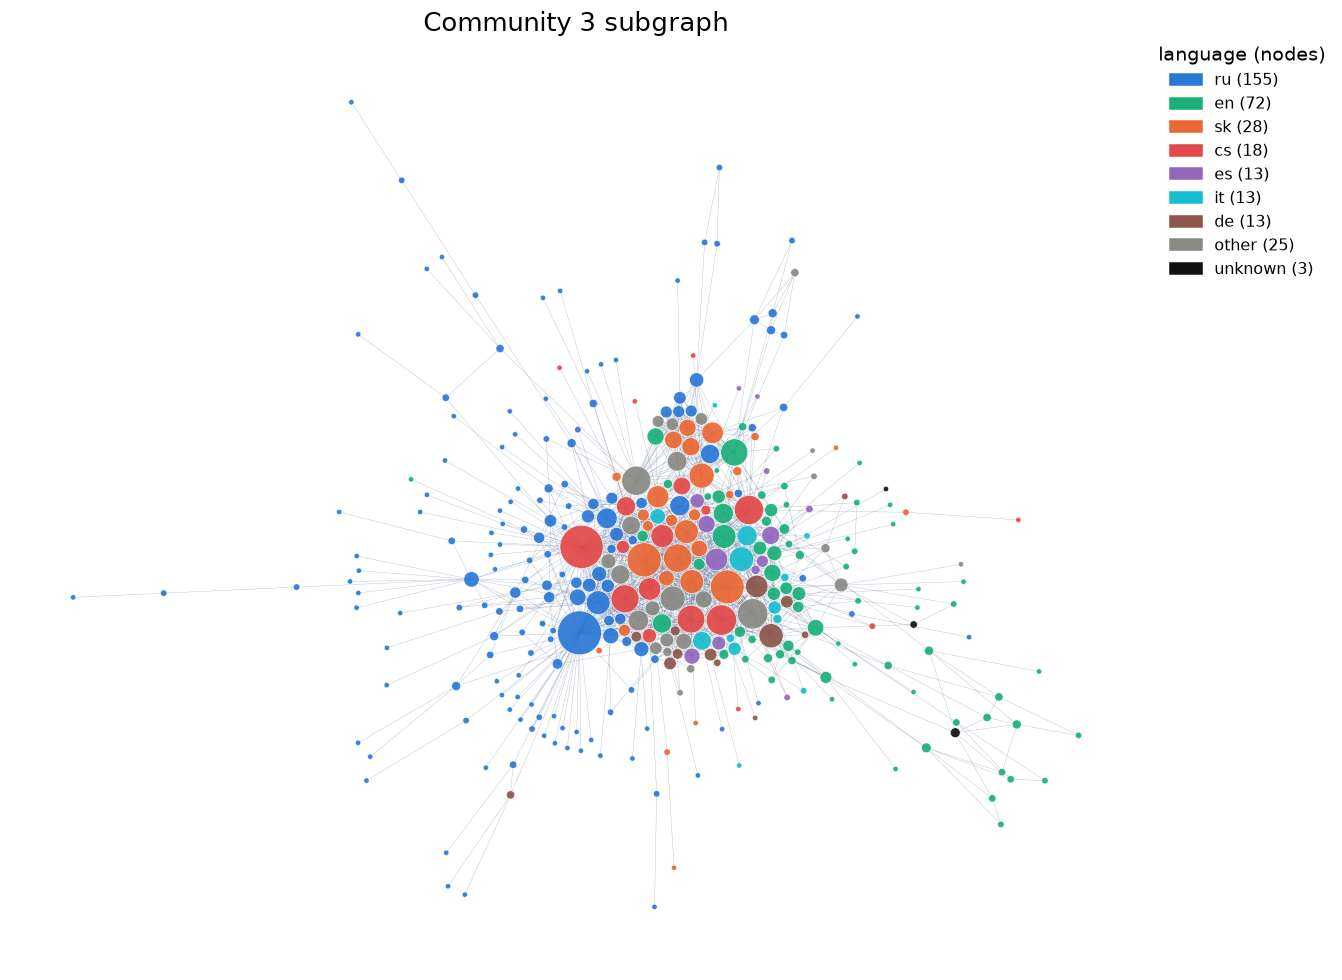

340 nodes / 1390 internal edges | top-7 langs: ['ru', 'en', 'sk', 'cs', 'es', 'it', 'de'] | layout seed 0


In [28]:
# ===== community 3 subgraph — nodes coloured by language (top-7 + other + unknown), marked_network.ipynb style =====
import random, igraph as ig, numpy as np, matplotlib.pyplot as plt
from matplotlib.collections import LineCollection, EllipseCollection
from matplotlib.colors import to_rgb
import matplotlib.patches as mpatches, matplotlib.patheffects as pe
from scipy.spatial import cKDTree
from collections import Counter

_idx3 = [i for i, h in enumerate(G_UND_GIANT.vs['name']) if comm_of[h] == 3]
G = G_UND_GIANT.induced_subgraph(_idx3)                 # the 340-node community-3 subgraph
hnames = np.array(G.vs['name'])
htot = np.array(G.degree(), dtype=float)                # size by internal (within-C3) degree

# --- language -> colour: top-7 languages keep their own colour; rest -> 'other'; 'unknown' separate ---
_raw = [lang.get(h, 'unknown') for h in hnames]
_top7 = [l for l, _ in Counter(l for l in _raw if l != 'unknown').most_common(7)]
_extra = ['#9467bd', '#17becf', '#8c564b', '#e377c2', '#bcbd22', '#2ca02c', '#ff7f0e']; _ei = 0
LC = {}
for _l in _top7:
    if _l in LANG_COLORS:
        LC[_l] = LANG_COLORS[_l]
    else:
        LC[_l] = _extra[_ei]; _ei += 1
LC['other'] = '#8a8a85'; LC['unknown'] = '#111111'      # unknown = near-black, distinct from 'other' grey
_lab = lambda l: l if l in _top7 else ('unknown' if l == 'unknown' else 'other')
labels = np.array([_lab(l) for l in _raw])
hrgb = np.array([to_rgb(LC[x]) for x in labels])
_rng = np.random.default_rng(42)

# ============ TWEAK THESE, then re-run the cell (Shift+Enter) ============
# defaults below = plain FR (no compression / repel / overlap-packing) — a readable baseline
SIZE_POWER          = 0.7     # node size vs internal degree
HUB_SIZE            = 0.020   # biggest-hub radius as a fraction of the frame
COMPRESS_PCT        = 100     # radial compression OFF (100 = raw DrL); lower = tighter (1..100)
LABELS              = 0       # how many top hubs to label
EDGE_ALPHA          = 0.5    # edge opacity
REPEL               = False   # degree-weighted spread OFF
REPEL_STRENGTH      = 1.05    # (only used when REPEL / PREVENT_ALL_OVERLAP is on)
PREVENT_ALL_OVERLAP = True   # strict zero-overlap packing OFF
LAYOUT_SEED         = 0       # change to reshuffle the FR layout
# ========================================================================

def hub_compress(coords, pct):
    if pct >= 100:
        return coords
    ctr = np.average(coords, axis=0, weights=htot); d = coords - ctr
    r = np.hypot(d[:, 0], d[:, 1]); r = np.where(r == 0, 1e-9, r); a = np.percentile(r, pct)
    return ctr + d * (a * np.arcsinh(r / a) / r)[:, None]
def hub_radii(coords, power, hub_frac):
    ext = max(np.ptp(coords[:, 0]), np.ptp(coords[:, 1]))
    return 0.0018 * ext + hub_frac * ext * (htot / htot.max()) ** power
def hub_repel(coords, radii, strength=1.05, full=False):
    coords = coords.copy(); w = (htot / htot.max()) ** 0.5 + 0.15
    iters = 220 if full else 150; pad = strength
    lo0, hi0 = coords.min(0), coords.max(0); ctr0 = (lo0 + hi0) / 2; span0 = float((hi0 - lo0).max())
    for _ in range(iters):
        pairs = cKDTree(coords).query_pairs(r=2 * radii.max() * pad, output_type='ndarray')
        if len(pairs) == 0:
            break
        i, j = pairs[:, 0], pairs[:, 1]; delta = coords[i] - coords[j]; dist = np.hypot(delta[:, 0], delta[:, 1])
        ov = (radii[i] + radii[j]) * pad - dist; m = ov > 0
        if not m.any():
            break
        i, j, dst, d2, ovm = i[m], j[m], dist[m], delta[m], ov[m]; z = dst < 1e-9
        dirv = np.where(z[:, None], _rng.standard_normal((len(i), 2)), d2 / np.where(dst[:, None] < 1e-9, 1, dst[:, None]))
        dirv /= np.hypot(dirv[:, 0], dirv[:, 1])[:, None]; wi, wj = w[i], w[j]; sN = wi + wj
        shift = np.zeros_like(coords)
        np.add.at(shift, i,  dirv * (wi / sN * ovm)[:, None]); np.add.at(shift, j, -dirv * (wj / sN * ovm)[:, None])
        mag = np.hypot(shift[:, 0], shift[:, 1]); cap = radii * 0.6
        sc = np.where(mag > cap, cap / np.where(mag == 0, 1, mag), 1.0); coords = coords + shift * sc[:, None]
    if not full:
        lo, hi = coords.min(0), coords.max(0); span = float((hi - lo).max())
        if span > span0:
            ctr = (lo + hi) / 2; coords = ctr0 + (coords - ctr) * (span0 / span)
    return coords
def hub_layout(base, power, hub_frac, cpct, repel, strength, no_ov):
    c = hub_compress(base, cpct); r = hub_radii(c, power, hub_frac)
    if no_ov:  return hub_repel(c, r, strength, full=True)
    if repel:  return hub_repel(c, r, strength, full=False)
    return c

try:
    _C3_FR_LAYOUT
except NameError:
    _C3_FR_LAYOUT = {}
if LAYOUT_SEED not in _C3_FR_LAYOUT:
    random.seed(LAYOUT_SEED)
    _C3_FR_LAYOUT[LAYOUT_SEED] = np.array(G.layout_fruchterman_reingold(niter=1200))
coords = hub_layout(_C3_FR_LAYOUT[LAYOUT_SEED], SIZE_POWER, HUB_SIZE, COMPRESS_PCT, REPEL, REPEL_STRENGTH, PREVENT_ALL_OVERLAP)
radii = hub_radii(coords, SIZE_POWER, HUB_SIZE)

FIG = 13; _fs = lambda frac: frac * FIG * 72
fig, ax = plt.subplots(figsize=(FIG, FIG))
ax.add_collection(LineCollection([[coords[e.source], coords[e.target]] for e in G.es],
                                 colors='#5f7396', linewidths=0.25, alpha=EDGE_ALPHA, zorder=1))
o = np.argsort(htot)
ax.add_collection(EllipseCollection(2 * radii[o], 2 * radii[o], np.zeros(G.vcount()), units='xy',
    offsets=coords[o], transOffset=ax.transData, facecolors=hrgb[o], edgecolors='white', linewidths=0.4, alpha=0.92, zorder=2))
for i in np.argsort(htot)[::-1][:LABELS]:
    ax.text(coords[i, 0], coords[i, 1], hnames[i], fontsize=_fs(0.010), ha='center', va='center', zorder=3,
            path_effects=[pe.withStroke(linewidth=1.6, foreground='white')])
_order = _top7 + [x for x in ('other', 'unknown') if x in set(labels)]
ax.legend(handles=[mpatches.Patch(color=LC[l], label=f'{l} ({int((labels==l).sum())})') for l in _order],
          loc='upper left', bbox_to_anchor=(1.01, 1.0), borderaxespad=0, frameon=False,
          fontsize=_fs(0.011), title='language (nodes)', title_fontsize=_fs(0.013))
_ext = max(np.ptp(coords[:, 0]), np.ptp(coords[:, 1])); _mg = radii.max() + 0.04 * _ext
ax.set_xlim(coords[:, 0].min() - _mg, coords[:, 0].max() + _mg)
ax.set_ylim(coords[:, 1].min() - _mg, coords[:, 1].max() + _mg)
ax.set_aspect('equal'); ax.set_axis_off()
ax.set_title('Community 3 subgraph', fontsize=_fs(0.018))
fig.subplots_adjust(left=0.03, right=0.82, top=0.94, bottom=0.03); plt.show()
print(f'{G.vcount()} nodes / {G.ecount()} internal edges | top-7 langs: {_top7} | layout seed {LAYOUT_SEED}')

### Community-3 battery — language census, the 442, block cohesion, `infodefense`

Wide-context probes that put the C3 findings on a denominator. The language census of the giant
is the denominator for C3's 155 Russian members; **the 442** is the count of Russian channels
that form an edge with a cs/sk node *anywhere* in the network, against the 59 inside C3 — the
basis for *"community 0 and 2 containing 71.9% of Russian channels the Czecho-Slovak nodes
reach"*. The en/de/es/it block gets the same cohesion battery as cs/sk, and the `infodefense`
scan surfaces the branded multilingual network sitting inside C3.

In [29]:
# ===== C3 battery: 1 language census · 2 the 442 · 4 en/de/es/it block · 5 stability · 6 infodefense =====
import numpy as np, pandas as pd, igraph as ig, random, re, json, leidenalg
from collections import Counter
from sklearn.metrics import adjusted_rand_score as _ARI
RUN_HEAVY = globals().get('RUN_HEAVY', False)
G = G_UND_GIANT; names = G.vs['name']; h2i = {h: i for i, h in enumerate(names)}
L = lambda h: lang.get(h, 'unknown')

# ---------- 1) language composition of the giant ----------
T_lang = pd.DataFrame([{'language': k, 'channels': v, 'share': round(v/len(names), 4)}
                       for k, v in Counter(L(h) for h in names).most_common()])
print(f"1) Language composition of the giant ({len(names):,} nodes) — the denominator for C3's 155 ru, and confirms cs+sk=50, en=80, uk=65")
display(T_lang)

# ---------- 2) the 442 ru touching cs/sk: located + weighted ----------
_csk = [h for h in names if L(h) in ('cs', 'sk')]; _csk_c3 = set(h for h in _csk if comm_of[h] == 3)
_ru_adj = {names[j] for h in _csk for j in G.neighbors(h2i[h]) if L(names[j]) == 'ru'}
_dom = {c: Counter(L(h) for h in names if comm_of[h] == c).most_common(1)[0][0] for c in set(comm_of.values())}
T_442 = pd.DataFrame([{'community': c, 'ru channels (of %d)' % len(_ru_adj): n, 'share': round(n/len(_ru_adj), 3),
                       'community dominant lang': _dom[c]} for c, n in Counter(comm_of[h] for h in _ru_adj).most_common()])
print(f"\n2a) Community distribution of the {len(_ru_adj)} ru channels touching a cs/sk node (register F5 predicts communities 0/1/2)")
display(T_442)
_ein = _eout = 0
for h in _csk_c3:
    for j in G.neighbors(h2i[h]):
        if L(names[j]) == 'ru': _ein += (comm_of[names[j]] == 3); _eout += (comm_of[names[j]] != 3)
_u2 = pd.read_csv(DATA / 'edges_unmarked.csv'); _u2 = _u2[_u2.n_semantic >= 2]
_win = _wout = 0
for r in _u2.itertuples(index=False):
    if r.u in _csk_c3 and L(r.v) == 'ru': ru = r.v
    elif r.v in _csk_c3 and L(r.u) == 'ru': ru = r.u
    else: continue
    if comm_of[ru] == 3: _win += r.n_semantic
    else: _wout += r.n_semantic
T_split = pd.DataFrame([{'measure': 'cs/sk↔ru edges', 'inside C3': _ein, 'outside C3': _eout, '% outside': f"{_eout/(_ein+_eout):.0%}"},
                        {'measure': 'cs/sk↔ru matched pairs (Σ n_semantic)', 'inside C3': _win, 'outside C3': _wout, '% outside': f"{_wout/(_win+_wout):.0%}"}])
print("2b) cs/sk↔ru volume, inside vs outside C3 — the denominator the sentence is missing")
display(T_split)

# ---------- 4) en/de/es/it block (111) cohesion + Italian lookup ----------
_blk = [h for h in names if comm_of[h] == 3 and L(h) in ('en', 'de', 'es', 'it')]
_bsub = G.induced_subgraph([h2i[h] for h in _blk]); _bc = sorted(_bsub.connected_components(), key=len, reverse=True)
_bset = set(h2i[h] for h in _blk); random.seed(42); _bn = []
for _ in range(150):
    _rr = ig.Graph.Degree_Sequence(G.degree(), method='configuration')
    _bn.append(sum(1 for e in _rr.es if e.source in _bset and e.target in _bset))
_bn = np.array(_bn)
T_blk = pd.Series({'block nodes (en/de/es/it)': len(_blk), 'internal edges': _bsub.ecount(), 'density': round(_bsub.density(), 4),
                   'connected components': len(_bc), 'largest component': f"{len(_bc[0])} ({len(_bc[0])/len(_blk):.0%})",
                   'isolates': int((np.array(_bsub.degree()) == 0).sum()),
                   'expected edges (config null)': f"{_bn.mean():.1f} ± {_bn.std():.1f}",
                   'observed/expected': f"{_bsub.ecount()/_bn.mean():.1f}×", 'z-score': round((_bsub.ecount()-_bn.mean())/_bn.std(), 1)}).to_frame('en/de/es/it block in C3')
print("\n4a) en/de/es/it block (111 nodes) — same cohesion battery as cs/sk")
display(T_blk)
_it3 = [h for h in names if comm_of[h] == 3 and L(h) == 'it']
if RUN_HEAVY and 'comm_marked' in globals():
    _enm = {mnames_marked[v] for v in range(len(mnames_marked)) if comm_marked[mnames_marked[v]] == en_comm_marked}
    _n_in = sum(1 for h in _it3 if h in _enm); _n_gi = sum(1 for h in _it3 if h in set(mnames_marked))
    print(f"4b) Italian lookup — of the {len(_it3)} it channels in C3: {_n_gi} are in the marked giant, {_n_in} were in the marked "
          f"en/de/es community (C7). Verdict: {'RETURNING members' if _n_in > len(_it3)/2 else 'largely NEW arrivals'}.")
else:
    print("4b) Italian lookup skipped — set RUN_HEAVY = True (needs the marked partition from the cs/sk-cohesion cell)")

if RUN_HEAVY:
    # ---------- 5) partition stability (R9) ----------
    _parts = [np.array(leidenalg.find_partition(G, leidenalg.ModularityVertexPartition, seed=sd, n_iterations=10).membership) for sd in range(1, 21)]
    _aris = [_ARI(_parts[a], _parts[b]) for a in range(20) for b in range(a+1, 20)]
    _cskdom = 0
    for _m in _parts:
        if any('cs' in [x[0] for x in Counter(L(names[v]) for v in np.where(_m == c)[0]).most_common(2)]
               or 'sk' in [x[0] for x in Counter(L(names[v]) for v in np.where(_m == c)[0]).most_common(2)] for c in set(_m.tolist())):
            _cskdom += 1
    _csk_all = [h for h in names if L(h) in ('cs', 'sk')]
    _msh = [Counter(dict(zip(names, _m.tolist()))[h] for h in _csk_all).most_common(1)[0][1]/len(_csk_all) for _m in _parts]
    T_stab = pd.Series({'Leiden runs (seeds)': 20,
                        'community count (min–max)': f"{min(int(m.max()+1) for m in _parts)}–{max(int(m.max()+1) for m in _parts)}",
                        'mean pairwise ARI': round(np.mean(_aris), 3), 'ARI range': f"[{min(_aris):.2f}, {max(_aris):.2f}]",
                        'runs with a cs/sk-dominant/2nd community': f"{_cskdom}/20",
                        'cs/sk (50) share in modal community — median': f"{np.median(_msh):.0%}",
                        'cs/sk modal-share range across runs': f"[{min(_msh):.0%}, {max(_msh):.0%}]"}).to_frame('Leiden stability')
    print("\n5) Partition stability — is '≈46 of 50 cs/sk together' robust or a draw?")
    display(T_stab)


else:
    print('\n5) Partition stability skipped — set RUN_HEAVY = True for the 20-seed pass')

# ---------- 6) infodefense ----------
_desc = json.load(open(DATA / 'channel_descriptions.json'))
_LAT = re.compile(r'info\s*def', re.I); _CYR = re.compile(r'инфодеф', re.I); _hits = []
for h in [h for h in names if comm_of[h] == 3]:
    d = _desc.get(h, {}); blob = ' '.join(str(d.get(k, '')) for k in ('username', 'title', 'about')) + ' ' + h
    if _LAT.search(blob) or _CYR.search(blob):
        _hits.append({'handle': h, 'language': L(h), 'title': (d.get('title') or '')[:40]})
T_info = pd.DataFrame(_hits).sort_values('language').reset_index(drop=True)
print(f"\n6) 'infodefense' network in C3: {len(_hits)} channels (handle/title/about, Latin + Cyrillic) across "
      f"{T_info.language.nunique()} languages")
display(T_info)

1) Language composition of the giant (2,776 nodes) — the denominator for C3's 155 ru, and confirms cs+sk=50, en=80, uk=65


,language,channels,share
0,ru,2440,0.8790
1,en,80,0.0288
2,uk,65,0.0234
3,sk,30,0.0108
4,cs,20,0.0072
5,unknown,19,0.0068
6,bg,17,0.0061
7,mk,15,0.0054
8,de,15,0.0054
9,es,13,0.0047



2a) Community distribution of the 442 ru channels touching a cs/sk node (register F5 predicts communities 0/1/2)


,community,ru channels (of 442),share,community dominant lang
0,2,168,0.380,ru
1,0,150,0.339,ru
2,3,59,0.133,ru
3,4,29,0.066,ru
4,1,13,0.029,ru
5,6,12,0.027,ru
6,5,7,0.016,ru
7,11,1,0.002,ru
8,8,1,0.002,ru
9,10,1,0.002,ru


2b) cs/sk↔ru volume, inside vs outside C3 — the denominator the sentence is missing


,measure,inside C3,outside C3,% outside
0,cs/sk↔ru edges,159,1013,86%
1,cs/sk↔ru matched pairs (Σ n_semantic),604,3849,86%



4a) en/de/es/it block (111 nodes) — same cohesion battery as cs/sk


,en/de/es/it block in C3
block nodes (en/de/es/it),111
internal edges,249
density,0.0408
connected components,9
largest component,103 (93%)
isolates,8
expected edges (config null),15.0 ± 3.5
observed/expected,16.6×
z-score,67.3


4b) Italian lookup skipped — set RUN_HEAVY = True (needs the marked partition from the cs/sk-cohesion cell)

5) Partition stability skipped — set RUN_HEAVY = True for the 20-seed pass

6) 'infodefense' network in C3: 14 channels (handle/title/about, Latin + Cyrillic) across 13 languages


,handle,language,title
0,infodefarab,ar,InfoDefenseARAB
1,infodefensecze,cs,InfoDefenseCZE
2,infodefscandinavia,da,InfodefSCANDINAVIA
3,infodefgermany,de,InfoDefenseDEUTSCH
4,infodefengland,en,InfoDefenseENGLISH
5,infodefenseen,en,IDpublicENG
6,infodefspain,es,InfoDefenseESPAÑOL
7,infodefestonia,et,InfoDefenseEstonia
8,infodeffrance1,fr,InfoDefenseEurope
9,infodefitaly,it,InfoDefenseITALIA


### Who wires cs/sk into the network — and Table 9

Node-level. **Q1**: which channels connect to the most cs/sk nodes (all languages, then Russian
only), with a direction read from the semantic directional votes. **Q2**: the Russian brokers
for cs/sk inside C3, and whether en/es/de have comparable ones. The third cell is **Table 9** —
every Czecho-Slovak channel with confidently directed (unanimous, n≥5) Russian-facing edges,
with the cs/sk→ru and ru→cs/sk tallies that come out **80 to 3** in favour of the Russian side
posting first.

In [30]:
import pandas as pd, numpy as np
from collections import Counter
_E = pd.read_csv(DATA / 'edges_unmarked.csv'); _u2 = _E[_E.n_semantic >= 2]
names = set(G_UND_GIANT.vs['name']); deg = dict(zip(G_UND_GIANT.vs['name'], G_UND_GIANT.degree()))
L = lambda h: lang.get(h, 'unknown'); CSK = set(h for h in names if L(h) in ('cs', 'sk'))
# direction = directed-layer rule: source only if UNANIMOUS (one side never posts first) AND nv>=5.
def _src(r):
    nv = r.n_u_first + r.n_v_first
    if nv >= 5 and r.n_v_first == 0: return r.u
    if nv >= 5 and r.n_u_first == 0: return r.v
    return None

# ===== Q1: which nodes connect most to cs/sk — total, then restricted to confidently-directed =====
print("── Legend · Q1 — nodes ranked by how many cs/sk channels they connect to (undirected) ──\n"
      "  cs/sk links           distinct cs/sk channels this node shares a content-reuse edge with\n"
      "  confidently directed  of those edges, how many the DIRECTED layer can orient (unanimous time-order, ≥5 votes)\n"
      "  →cs/sk (conf)         confident edges where THIS node is the source (posts first; cs/sk reuses it) = flow INTO cs/sk\n"
      "  cs/sk→ (conf)         confident edges where the CS/SK channel is the source (cs/sk posts first; this node reuses it)\n"
      "  net                   whichever of the two is larger (— = tie or none)\n"
      "  '-dir' tables         the same nodes, still in link order, filtered to those with ≥1 confidently-directed edge\n"
      "──────────────────────────────────────────────────────────────────────────────────────────")
conn = Counter(); s = Counter(); t = Counter(); amb = Counter()
for r in _u2.itertuples(index=False):
    a, b = r.u, r.v
    if a not in names or b not in names or (a in CSK) == (b in CSK): continue
    cn = b if a in CSK else a; cs = a if a in CSK else b
    conn[cn] += 1; sr = _src(r)
    if sr == cn: s[cn] += 1
    elif sr == cs: t[cn] += 1
    else: amb[cn] += 1
_dc = lambda h: s[h] + t[h]
def _tbl(items):
    return pd.DataFrame([{'handle': h, 'language': L(h), 'community': comm_of[h], 'degree': deg[h], 'cs/sk links': conn[h],
        'confidently directed': _dc(h), '→cs/sk (conf)': s[h], 'cs/sk→ (conf)': t[h],
        'net': '→cs/sk' if s[h] > t[h] else ('cs/sk→' if t[h] > s[h] else '—')} for h in items])
_all = list(conn); _ru = [h for h in conn if L(h) == 'ru']
print("Q1a — nodes connecting most to cs/sk (any language), by TOTAL cs/sk links:")
display(_tbl(sorted(_all, key=lambda h: -conn[h])[:15]))
print("Q1a-dir — the same top connectors that the directed layer can orient (≥1 confidently-directed edge), still ranked by cs/sk links:")
display(_tbl(sorted([h for h in _all if _dc(h) > 0], key=lambda h: -conn[h])[:15]))
print("Q1b — RUSSIAN nodes connecting most to cs/sk, by TOTAL links:")
display(_tbl(sorted(_ru, key=lambda h: -conn[h])[:15]))
print("Q1b-dir — the same RUSSIAN connectors that the directed layer can orient, still ranked by cs/sk links:")
display(_tbl(sorted([h for h in _ru if _dc(h) > 0], key=lambda h: -conn[h])[:15]))

── Legend · Q1 — nodes ranked by how many cs/sk channels they connect to (undirected) ──
  cs/sk links           distinct cs/sk channels this node shares a content-reuse edge with
  confidently directed  of those edges, how many the DIRECTED layer can orient (unanimous time-order, ≥5 votes)
  →cs/sk (conf)         confident edges where THIS node is the source (posts first; cs/sk reuses it) = flow INTO cs/sk
  cs/sk→ (conf)         confident edges where the CS/SK channel is the source (cs/sk posts first; this node reuses it)
  net                   whichever of the two is larger (— = tie or none)
  '-dir' tables         the same nodes, still in link order, filtered to those with ≥1 confidently-directed edge
──────────────────────────────────────────────────────────────────────────────────────────
Q1a — nodes connecting most to cs/sk (any language), by TOTAL cs/sk links:


,handle,language,community,degree,cs/sk links,confidently directed,→cs/sk (conf),cs/sk→ (conf),net
0,allratings,ru,3,453,20,0,0,0,—
1,odessarussi,ru,2,424,19,2,2,0,→cs/sk
2,bgbzc,ca,2,254,16,1,1,0,→cs/sk
3,ruskistatek,pl,3,131,16,0,0,0,—
4,angelika_vz,ru,2,382,15,1,1,0,→cs/sk
5,infokju,pl,3,81,15,0,0,0,—
6,osvedomitell,ru,2,482,14,1,1,0,→cs/sk
7,polit_anarx,ru,0,460,14,0,0,0,—
8,rus_6a3a,ru,2,176,14,0,0,0,—
9,meerzonaa,ru,2,475,13,0,0,0,—


Q1a-dir — the same top connectors that the directed layer can orient (≥1 confidently-directed edge), still ranked by cs/sk links:


,handle,language,community,degree,cs/sk links,confidently directed,→cs/sk (conf),cs/sk→ (conf),net
0,odessarussi,ru,2,424,19,2,2,0,→cs/sk
1,bgbzc,ca,2,254,16,1,1,0,→cs/sk
2,angelika_vz,ru,2,382,15,1,1,0,→cs/sk
3,osvedomitell,ru,2,482,14,1,1,0,→cs/sk
4,otpervogolitsa,ru,0,302,13,1,1,0,→cs/sk
5,nash_prezident_putin,ru,2,496,13,1,1,0,→cs/sk
6,mriya24,ru,2,303,12,1,1,0,→cs/sk
7,pul_nomer_3,ru,0,424,12,2,2,0,→cs/sk
8,kwisatzhaderakh,bg,3,140,12,2,2,0,→cs/sk
9,radiomirby,ru,0,277,11,3,3,0,→cs/sk


Q1b — RUSSIAN nodes connecting most to cs/sk, by TOTAL links:


,handle,language,community,degree,cs/sk links,confidently directed,→cs/sk (conf),cs/sk→ (conf),net
0,allratings,ru,3,453,20,0,0,0,—
1,odessarussi,ru,2,424,19,2,2,0,→cs/sk
2,angelika_vz,ru,2,382,15,1,1,0,→cs/sk
3,osvedomitell,ru,2,482,14,1,1,0,→cs/sk
4,polit_anarx,ru,0,460,14,0,0,0,—
5,rus_6a3a,ru,2,176,14,0,0,0,—
6,meerzonaa,ru,2,475,13,0,0,0,—
7,otpervogolitsa,ru,0,302,13,1,1,0,→cs/sk
8,nash_prezident_putin,ru,2,496,13,1,1,0,→cs/sk
9,lisichanskinfo,ru,2,357,12,0,0,0,—


Q1b-dir — the same RUSSIAN connectors that the directed layer can orient, still ranked by cs/sk links:


,handle,language,community,degree,cs/sk links,confidently directed,→cs/sk (conf),cs/sk→ (conf),net
0,odessarussi,ru,2,424,19,2,2,0,→cs/sk
1,angelika_vz,ru,2,382,15,1,1,0,→cs/sk
2,osvedomitell,ru,2,482,14,1,1,0,→cs/sk
3,otpervogolitsa,ru,0,302,13,1,1,0,→cs/sk
4,nash_prezident_putin,ru,2,496,13,1,1,0,→cs/sk
5,mriya24,ru,2,303,12,1,1,0,→cs/sk
6,pul_nomer_3,ru,0,424,12,2,2,0,→cs/sk
7,radiomirby,ru,0,277,11,3,3,0,→cs/sk
8,bear007,ru,2,223,10,1,1,0,→cs/sk
9,ostashkonews,ru,0,231,10,1,1,0,→cs/sk


In [31]:
import pandas as pd, numpy as np
from collections import Counter
_E = pd.read_csv(DATA / 'edges_unmarked.csv'); _u2 = _E[_E.n_semantic >= 2]
names = set(G_UND_GIANT.vs['name']); deg = dict(zip(G_UND_GIANT.vs['name'], G_UND_GIANT.degree()))
L = lambda h: lang.get(h, 'unknown'); CSK = set(h for h in names if L(h) in ('cs', 'sk'))
# direction = directed-layer rule: source only if UNANIMOUS (one side never posts first) AND nv>=5.
def _src(r):
    nv = r.n_u_first + r.n_v_first
    if nv >= 5 and r.n_v_first == 0: return r.u
    if nv >= 5 and r.n_u_first == 0: return r.v
    return None

# ===== Q2: C3 ru brokers per language group — total, then confidently-directed =====
print("── Legend · Q2 — Russian-language brokers in C3 (rows per target group: cs+sk / en / es / de) ──\n"
      "  ru broker             a ru channel in C3 that connects to the group's channels\n"
      "  links                 number of that group's channels in C3 this broker connects to\n"
      "  share                 its share of all {group}↔ru links in C3\n"
      "  confidently directed  of its edges, how many the directed layer can orient\n"
      "  →group (conf)         confident edges where the BROKER is the source (broker posts first; group reuses it) = ru feeding the group\n"
      "  group→ (conf)         confident edges where the GROUP channel is the source (group posts first; broker reuses it)\n"
      "  the 2nd table per group = same brokers, still link-ranked, filtered to those the directed layer can orient\n"
      "──────────────────────────────────────────────────────────────────────────────────────────")
_c3 = set(h for h in names if comm_of[h] == 3)
def _brokers(target):
    tset = set(h for h in _c3 if L(h) in target); bk = Counter(); s = Counter(); t = Counter(); amb = Counter()
    for r in _u2.itertuples(index=False):
        a, b = r.u, r.v
        if a not in _c3 or b not in _c3: continue
        if a in tset and L(b) == 'ru': grp, br = a, b
        elif b in tset and L(a) == 'ru': grp, br = b, a
        else: continue
        bk[br] += 1; sr = _src(r)
        if sr == br: s[br] += 1
        elif sr == grp: t[br] += 1
        else: amb[br] += 1
    return bk, s, t, amb
def _bt(items, bk, s, t, tot):
    return pd.DataFrame([{'ru broker': h, 'degree': deg[h], 'links': bk[h], 'share': round(bk[h]/tot, 3) if tot else 0,
        'confidently directed': s[h]+t[h], '→group (conf)': s[h], 'group→ (conf)': t[h]} for h in items])
for _g in [('cs', 'sk'), ('en',), ('es',), ('de',)]:
    bk, s, t, amb = _brokers(_g); tot = sum(bk.values()); _dcb = {h: s[h]+t[h] for h in bk}
    print(f"\nru brokers for {'+'.join(_g)} in C3 — by TOTAL links ({tot} links over {len(bk)} distinct ru):")
    display(_bt(sorted(bk, key=lambda h: -bk[h])[:6], bk, s, t, tot))
    _dp = sorted([h for h in bk if _dcb[h] > 0], key=lambda h: -bk[h])
    if _dp:
        print("   ...same brokers the directed layer can orient (≥1 confidently-directed edge), still ranked by links:")
        display(_bt(_dp[:6], bk, s, t, tot))
    else:
        print(f"   (no {'+'.join(_g)}↔ru edge in C3 has a confident direction — nothing to rank)")

── Legend · Q2 — Russian-language brokers in C3 (rows per target group: cs+sk / en / es / de) ──
  ru broker             a ru channel in C3 that connects to the group's channels
  links                 number of that group's channels in C3 this broker connects to
  share                 its share of all {group}↔ru links in C3
  confidently directed  of its edges, how many the directed layer can orient
  →group (conf)         confident edges where the BROKER is the source (broker posts first; group reuses it) = ru feeding the group
  group→ (conf)         confident edges where the GROUP channel is the source (group posts first; broker reuses it)
  the 2nd table per group = same brokers, still link-ranked, filtered to those the directed layer can orient
──────────────────────────────────────────────────────────────────────────────────────────

ru brokers for cs+sk in C3 — by TOTAL links (159 links over 59 distinct ru):


,ru broker,degree,links,share,confidently directed,→group (conf),group→ (conf)
0,allratings,453,18,0.113,0,0,0
1,akko_pomogaem,29,10,0.063,0,0,0
2,celno3or,110,8,0.050,0,0,0
3,buyantime,24,6,0.038,2,2,0
4,sovsecretno,35,6,0.038,0,0,0
5,newseconomics,98,5,0.031,1,1,0


   ...same brokers the directed layer can orient (≥1 confidently-directed edge), still ranked by links:


,ru broker,degree,links,share,confidently directed,→group (conf),group→ (conf)
0,buyantime,24,6,0.038,2,2,0
1,newseconomics,98,5,0.031,1,1,0
2,grpatkz,9,5,0.031,1,0,1
3,olimhadashim,13,5,0.031,1,1,0
4,supremecourtofbelarus,9,5,0.031,1,0,1
5,bye_biden,54,4,0.025,1,1,0



ru brokers for en in C3 — by TOTAL links (38 links over 22 distinct ru):


...

,ru broker,degree,links,share,confidently directed,→group (conf),group→ (conf)
0,allratings,453,3,0.375,0,0,0
1,frau_marussja,37,2,0.250,0,0,0
2,newseconomics,98,1,0.125,0,0,0
3,danielmikusekpolska,4,1,0.125,0,0,0
4,pavlova_maria_live,79,1,0.125,0,0,0


   (no es↔ru edge in C3 has a confident direction — nothing to rank)

ru brokers for de in C3 — by TOTAL links (14 links over 8 distinct ru):


,ru broker,degree,links,share,confidently directed,→group (conf),group→ (conf)
0,newseconomics,98,4,0.286,0,0,0
1,allratings,453,3,0.214,0,0,0
2,celno3or,110,2,0.143,0,0,0
3,bye_biden,54,1,0.071,0,0,0
4,golosgermanii,1,1,0.071,0,0,0
5,kremlinprachka,1,1,0.071,0,0,0


   ...same brokers the directed layer can orient (≥1 confidently-directed edge), still ranked by links:


,ru broker,degree,links,share,confidently directed,→group (conf),group→ (conf)
0,olegtsarov,6,1,0.071,1,1,0


In [32]:
import pandas as pd, numpy as np
from collections import Counter
_E = pd.read_csv(DATA / 'edges_unmarked.csv'); _u2 = _E[_E.n_semantic >= 2]
names = set(G_UND_GIANT.vs['name']); deg = dict(zip(G_UND_GIANT.vs['name'], G_UND_GIANT.degree()))
L = lambda h: lang.get(h, 'unknown'); CSK = set(h for h in names if L(h) in ('cs', 'sk'))
# direction = directed-layer rule: source only if UNANIMOUS (one side never posts first) AND nv>=5.
def _src(r):
    nv = r.n_u_first + r.n_v_first
    if nv >= 5 and r.n_v_first == 0: return r.u
    if nv >= 5 and r.n_u_first == 0: return r.v
    return None

# ===== Q3: which cs/sk nodes reach out most — total, then confidently-directed; Šlerka =====
print("── Legend · Q3 — cs/sk nodes ranked by how much they reach OUT to non-cs/sk / ru channels ──\n"
      "  other-lang / ru links   distinct non-cs/sk (or ru) channels this cs/sk node connects to\n"
      "  partner languages       language breakdown of those partners (top 5)\n"
      "  confidently directed    of those edges, how many the directed layer can orient (unanimous order, ≥5 votes)\n"
      "  cs/sk→ / cs/sk→ru (conf)  confident edges where the CS/SK node is the source (it posts first; partner reuses it)\n"
      "  →cs/sk / ru→cs/sk (conf)  confident edges where the PARTNER is the source (partner posts first; cs/sk reuses it)\n"
      "  net                     whichever is larger (— = tie or none)\n"
      "──────────────────────────────────────────────────────────────────────────────────────────")
oth = Counter(); o_s = Counter(); o_t = Counter(); ru = Counter(); r_s = Counter(); r_t = Counter(); omix = {}
for r in _u2.itertuples(index=False):
    a, b = r.u, r.v
    if a not in names or b not in names: continue
    for c, o in ((a, b), (b, a)):
        if c in CSK and o not in CSK:
            oth[c] += 1; omix.setdefault(c, Counter())[L(o)] += 1; sr = _src(r)
            o_s[c] += (sr == c); o_t[c] += (sr == o)
            if L(o) == 'ru':
                ru[c] += 1; r_s[c] += (sr == c); r_t[c] += (sr == o)
pd.set_option('display.max_colwidth', None)
_fmt = lambda cnt: ', '.join(f'{l} {n}' for l, n in cnt.most_common(5)) + (' …' if len(cnt) > 5 else '')
def _to(items):
    return pd.DataFrame([{'handle': h, 'language': L(h), 'community': comm_of[h], 'degree': deg[h], 'other-lang links': oth[h],
        'partner languages': _fmt(omix.get(h, Counter())),
        'confidently directed': o_s[h]+o_t[h], 'cs/sk→ (conf)': o_s[h], '→cs/sk (conf)': o_t[h]} for h in items])
def _tr(items):
    return pd.DataFrame([{'handle': h, 'language': L(h), 'community': comm_of[h], 'degree': deg[h], 'ru links': ru[h],
        'confidently directed': r_s[h]+r_t[h], 'cs/sk→ru (conf)': r_s[h], 'ru→cs/sk (conf)': r_t[h],
        'net': 'cs/sk→ru' if r_s[h] > r_t[h] else ('ru→cs/sk' if r_t[h] > r_s[h] else '—')} for h in items])
_od = lambda h: o_s[h]+o_t[h]; _rd = lambda h: r_s[h]+r_t[h]
print("Q3a — cs/sk nodes by connections to OTHER-language nodes, by TOTAL links:")
display(_to(sorted(oth, key=lambda h: -oth[h])[:15]))
print("Q3a-dir — the same cs/sk nodes the directed layer can orient, still ranked by other-lang links:")
display(_to(sorted([h for h in oth if _od(h) > 0], key=lambda h: -oth[h])[:15]))
print("Q3b — cs/sk nodes by connections to RUSSIAN nodes, by TOTAL links:")
display(_tr(sorted(ru, key=lambda h: -ru[h])[:15]))
print("Q3b-dir — the same cs/sk nodes the directed layer can orient, still ranked by ru links:")
display(_tr(sorted([h for h in ru if _rd(h) > 0], key=lambda h: -ru[h])[:15]))
print("Šlerka-identified channels (nect24, selskyrozum):")
display(_tr([h for h in ['nect24', 'selskyrozum'] if h in names]))
print("not in the unmarked giant:", [h for h in ['nect24', 'selskyrozum'] if h not in names] or "none — both present")

── Legend · Q3 — cs/sk nodes ranked by how much they reach OUT to non-cs/sk / ru channels ──
  other-lang / ru links   distinct non-cs/sk (or ru) channels this cs/sk node connects to
  partner languages       language breakdown of those partners (top 5)
  confidently directed    of those edges, how many the directed layer can orient (unanimous order, ≥5 votes)
  cs/sk→ / cs/sk→ru (conf)  confident edges where the CS/SK node is the source (it posts first; partner reuses it)
  →cs/sk / ru→cs/sk (conf)  confident edges where the PARTNER is the source (partner posts first; cs/sk reuses it)
  net                     whichever is larger (— = tie or none)
──────────────────────────────────────────────────────────────────────────────────────────


Q3a — cs/sk nodes by connections to OTHER-language nodes, by TOTAL links:


,handle,language,community,degree,other-lang links,partner languages,confidently directed,cs/sk→ (conf),→cs/sk (conf)
0,selskyrozum,cs,3,333,309,"ru 270, en 8, bg 6, pl 6, it 4 …",31,2,29
1,zemavek,sk,3,193,171,"ru 138, en 7, pl 6, es 5, bg 5 …",15,0,15
2,infodefensecze,cs,3,159,143,"ru 121, de 5, pl 5, es 3, it 2 …",13,0,13
3,cactus_bielli,sk,3,156,141,"ru 111, bg 6, en 5, pl 4, es 3 …",5,0,5
4,ksbspravy,sk,3,116,93,"ru 62, en 8, pl 6, de 4, es 3 …",0,0,0
5,to_je_nas_svet,cs,3,103,86,"ru 73, pl 5, es 2, it 2, en 2 …",0,0,0
6,nect24,cs,0,96,84,"ru 74, pl 4, es 2, it 1, de 1 …",1,0,1
7,bn4jeytq6rvkmtnk,cs,3,99,83,"ru 52, en 10, de 5, bg 4, es 3 …",1,0,1
8,casusbellilive,sk,3,98,78,"ru 59, bg 4, en 4, es 2, it 2 …",0,0,0
9,ambasadarus,sk,0,82,77,"ru 73, de 1, pl 1, fr 1, en 1",5,0,5


Q3a-dir — the same cs/sk nodes the directed layer can orient, still ranked by other-lang links:


,handle,language,community,degree,other-lang links,partner languages,confidently directed,cs/sk→ (conf),→cs/sk (conf)
0,selskyrozum,cs,3,333,309,"ru 270, en 8, bg 6, pl 6, it 4 …",31,2,29
1,zemavek,sk,3,193,171,"ru 138, en 7, pl 6, es 5, bg 5 …",15,0,15
2,infodefensecze,cs,3,159,143,"ru 121, de 5, pl 5, es 3, it 2 …",13,0,13
3,cactus_bielli,sk,3,156,141,"ru 111, bg 6, en 5, pl 4, es 3 …",5,0,5
4,nect24,cs,0,96,84,"ru 74, pl 4, es 2, it 1, de 1 …",1,0,1
5,bn4jeytq6rvkmtnk,cs,3,99,83,"ru 52, en 10, de 5, bg 4, es 3 …",1,0,1
6,ambasadarus,sk,0,82,77,"ru 73, de 1, pl 1, fr 1, en 1",5,0,5
7,aliancenarodnichsil,cs,3,94,74,"ru 57, en 4, it 4, pl 4, de 2 …",2,0,2
8,czkulovyblesk,cs,3,75,51,"ru 30, en 7, pl 3, mk 2, de 2 …",1,0,1
9,han_solo_news_czech,cs,2,50,42,"ru 37, bg 3, ca 1, it 1",3,0,3


...

Q3b-dir — the same cs/sk nodes the directed layer can orient, still ranked by ru links:


,handle,language,community,degree,ru links,confidently directed,cs/sk→ru (conf),ru→cs/sk (conf),net
0,selskyrozum,cs,3,333,270,29,0,29,ru→cs/sk
1,zemavek,sk,3,193,138,15,0,15,ru→cs/sk
2,infodefensecze,cs,3,159,121,12,0,12,ru→cs/sk
3,cactus_bielli,sk,3,156,111,5,0,5,ru→cs/sk
4,nect24,cs,0,96,74,1,0,1,ru→cs/sk
5,ambasadarus,sk,0,82,73,5,0,5,ru→cs/sk
6,aliancenarodnichsil,cs,3,94,57,2,0,2,ru→cs/sk
7,han_solo_news_czech,cs,2,50,37,3,0,3,ru→cs/sk
8,czkulovyblesk,cs,3,75,30,1,0,1,ru→cs/sk
9,dkfansadiskusie,sk,3,34,13,5,1,4,ru→cs/sk


Šlerka-identified channels (nect24, selskyrozum):


,handle,language,community,degree,ru links,confidently directed,cs/sk→ru (conf),ru→cs/sk (conf),net
0,nect24,cs,0,96,74,1,0,1,ru→cs/sk
1,selskyrozum,cs,3,333,270,29,0,29,ru→cs/sk


not in the unmarked giant: none — both present


### Denominators, network-wide direction, and nulls

Puts §4.3.1's headline counts on explicit denominators: the **1,358** cs/sk↔ru edges and the 33
of 50 cs/sk channels carrying them; the concentration series (top-1 20%, top-4 **47%**, top-10
**76%**); the **83 of 1,358** that the directed layer can orient and how the split behaves at
rising evidence bars and per Russian community; and a configuration null for whether cs/sk
connect to Russian channels more or less than chance (0.7× — less).

In [33]:
# ===== Reviewer follow-up A =====
import pandas as pd, numpy as np, igraph as ig, random
from collections import Counter
_nd = pd.read_csv(DATA / 'nodes.csv'); ntype = dict(zip(_nd.handle, _nd.type))
E = pd.read_csv(DATA / 'edges_unmarked.csv'); _u2 = E[E.n_semantic >= 2]
GN = set(G_UND_GIANT.vs['name']); deg = dict(zip(G_UND_GIANT.vs['name'], G_UND_GIANT.degree()))
L = lambda h: lang.get(h, 'unknown'); CSK = set(h for h in GN if L(h) in ('cs', 'sk'))
rows = [r for r in _u2.itertuples(index=False) if r.u in GN and r.v in GN]
def _src(r, thr=5):
    nv = r.n_u_first + r.n_v_first
    if nv >= thr and r.n_v_first == 0: return r.u
    if nv >= thr and r.n_u_first == 0: return r.v
    return None
_csk_ru = [r for r in rows if (r.u in CSK and L(r.v) == 'ru') or (r.v in CSK and L(r.u) == 'ru')]
_ruof = lambda r: r.v if r.u in CSK else r.u
_cskof = lambda r: r.u if r.u in CSK else r.v

# ---------- 1) provenance: full row counts behind the pasted (head-cut) tables ----------
conn = Counter(); dc = Counter(); o_dc = Counter(); r_dc = Counter()
for r in rows:
    if (r.u in CSK) != (r.v in CSK):
        cn = _ruof(r) if False else (r.v if r.u in CSK else r.u); cs = r.u if r.u in CSK else r.v
        conn[cn] += 1
        if _src(r) in (cn, cs): dc[cn] += 1
    for c, o in ((r.u, r.v), (r.v, r.u)):
        if c in CSK and o not in CSK and _src(r) in (c, o):
            o_dc[c] += 1
            if L(o) == 'ru': r_dc[c] += 1
prov = pd.DataFrame([
    {'table': 'Q1a-dir (connectors, any lang)', 'shown': 15, 'full row count': sum(dc[h] > 0 for h in conn), 'complete?': ''},
    {'table': 'Q1b-dir (ru connectors)', 'shown': 15, 'full row count': sum(dc[h] > 0 for h in conn if L(h) == 'ru'), 'complete?': ''},
    {'table': 'Q3a-dir (cs/sk → other-lang)', 'shown': 15, 'full row count': sum(v > 0 for v in o_dc.values()), 'complete?': ''},
    {'table': 'Q3b-dir (cs/sk → ru)', 'shown': 13, 'full row count': sum(v > 0 for v in r_dc.values()), 'complete?': ''}])
prov['complete?'] = np.where(prov['full row count'] <= prov['shown'], 'COMPLETE (not truncated)', 'truncated (head cut)')
print("1) Provenance — are the pasted -dir tables truncated? (Q3b-dir underpins the direction claim)")
display(prov)

# ---------- 2) denominators for cs/sk ↔ ru (undirected, n>=2, network-wide) ----------
_csk_side = set(); _ru_side = set()
for r in _csk_ru:
    _csk_side.add(_cskof(r)); _ru_side.add(_ruof(r))
_pl = Counter()
for r in rows:
    for c, o in ((r.u, r.v), (r.v, r.u)):
        if c in CSK and o not in CSK: _pl[L(o)] += 1
_tot_other = sum(_pl.values())
print(f"\n2a) cs/sk↔ru edges (giant, n≥2): {len(_csk_ru):,} | distinct cs/sk on them: {len(_csk_side)} (of {len(CSK)} cs/sk total) | distinct ru: {len(_ru_side)}")
display(pd.DataFrame([{'partner language': l, 'edges': n, 'share of cs/sk foreign contact': f'{n/_tot_other:.1%}'} for l, n in _pl.most_common()]))
print(f"   → Russian is {_pl['ru']/_tot_other:.1%} of cs/sk foreign contact — 'foreign' is NOT simply 'Russian'.")
# per-node ru-links for ALL cs/sk + concentration
_ruln = Counter()
for r in _csk_ru: _ruln[_cskof(r)] += 1
_full = pd.DataFrame([{'handle': h, 'language': L(h), 'type': ntype.get(h), 'community': comm_of[h],
                       'ru links': _ruln.get(h, 0), 'total degree': deg[h]} for h in sorted(CSK, key=lambda h: -_ruln.get(h, 0))])
print(f"\n2b) per-node ru-link counts for ALL {len(CSK)} cs/sk nodes (bridge-layer, F6):")
display(_full)
_v = np.array(sorted(_ruln.values(), reverse=True)); _s = _v.sum()
print(f"   ru-link concentration: top-1 {_v[0]/_s:.0%} | top-4 {_v[:4].sum()/_s:.0%} | top-10 {_v[:10].sum()/_s:.0%} of {_s} cs/sk↔ru links")
# 442 ru by community (nodes + edges)
_bn = Counter(comm_of[h] for h in _ru_side); _be = Counter(comm_of[_ruof(r)] for r in _csk_ru)
_cd = pd.DataFrame([{'ru community': c, 'ru nodes (of 442)': _bn.get(c, 0), 'node share': f'{_bn.get(c,0)/sum(_bn.values()):.1%}',
                     'cs/sk↔ru edges': _be.get(c, 0), 'edge share': f'{_be.get(c,0)/sum(_be.values()):.1%}'}
                    for c in sorted(set(_bn) | set(_be), key=lambda c: -_be.get(c, 0))])
print("\n2c) community distribution of the 442 ru nodes touching cs/sk (by nodes and by edges):")
display(_cd)
print(f"   comms 0+2: {(_bn[0]+_bn[2])/sum(_bn.values()):.1%} of ru nodes, {(_be[0]+_be[2])/sum(_be.values()):.1%} of cs/sk↔ru edges.")

# ---------- 3) direction network-wide ----------
def _split(edges, thr):
    ruf = csf = amb = 0
    for r in edges:
        s = _src(r, thr)
        if s is None: amb += 1
        elif s == _ruof(r): ruf += 1
        else: csf += 1
    return ruf, csf, amb
_dir = []
for thr in (5, 7, 10):
    ruf, csf, amb = _split(_csk_ru, thr); conf = ruf + csf
    _dir.append({'evidence bar': f'nv≥{thr}', 'confidently directed': conf, 'of edges': f'{conf/len(_csk_ru):.1%}',
                 'ru-first': ruf, 'cs/sk-first': csf, 'ru-first share': f'{ruf/conf:.0%}' if conf else '—'})
print("\n3a) direction of all cs/sk↔ru edges, as the evidence bar rises:")
display(pd.DataFrame(_dir))
# per ru-community
_pc = {}
for r in _csk_ru:
    s = _src(r, 5); k = comm_of[_ruof(r)]; d = _pc.setdefault(k, [0, 0, 0])
    d[0 if s == _ruof(r) else (1 if s == _cskof(r) else 2)] += 1
_pcd = pd.DataFrame([{'ru community': k, 'ru-first': v[0], 'cs/sk-first': v[1], 'ambiguous': v[2]}
                     for k, v in sorted(_pc.items(), key=lambda kv: -(kv[1][0]+kv[1][1]))])
print("3b) same split per COMMUNITY of the ru endpoint (does direction resolve OUTSIDE C3?):")
display(_pcd)
# the cs/sk-first edges themselves
_csf_edges = [{'cs/sk node': _cskof(r), 'type': ntype.get(_cskof(r)), 'lang': L(_cskof(r)), 'comm': comm_of[_cskof(r)],
               'ru partner': _ruof(r), 'ru comm': comm_of[_ruof(r)], 'nv': r.n_u_first+r.n_v_first, 'n_sem': r.n_semantic}
              for r in _csk_ru if _src(r, 5) == _cskof(r)]
print("3c) the cs/sk-first edges in full — are their cs/sk nodes channels or discussion groups?")
display(pd.DataFrame(_csf_edges))
# orientation selectivity + null
_orient = [r for r in _csk_ru if _src(r, 5)]; _non = [r for r in _csk_ru if not _src(r, 5)]
_ruf5, _csf5, _ = _split(_csk_ru, 5)
_expconf = sum(2 * 0.5 ** (r.n_u_first + r.n_v_first) for r in _csk_ru if (r.n_u_first + r.n_v_first) >= 5)
print(f"\n3d) orientation coverage/selectivity: {len(_orient)}/{len(_csk_ru)} = {len(_orient)/len(_csk_ru):.1%} orientable | "
      f"n_semantic mean/median: orientable {np.mean([r.n_semantic for r in _orient]):.1f}/{int(np.median([r.n_semantic for r in _orient]))} "
      f"vs non-orientable {np.mean([r.n_semantic for r in _non]):.1f}/{int(np.median([r.n_semantic for r in _non]))} "
      f"→ orientation is biased toward heavy-reuse edges.")
print(f"3e) null (random message ordering, Table-5 style): expected confidently-directed ≈ {_expconf:.1f} (observed {_ruf5+_csf5}); "
      f"null ru-first share 50% vs observed {_ruf5/(_ruf5+_csf5):.0%}.")

# ---------- 4) degree-preserving (F8) config nulls ----------
_ci = set(i for i, h in enumerate(G_UND_GIANT.vs['name']) if h in CSK)
_ri = set(i for i, h in enumerate(G_UND_GIANT.vs['name']) if L(h) == 'ru')
random.seed(42); _ne = []; _nr = []
for _ in range(100):
    _rr = ig.Graph.Degree_Sequence(G_UND_GIANT.degree(), method='configuration')
    _ne.append(sum(1 for e in _rr.es if (e.source in _ci) != (e.target in _ci) and (e.source in _ri or e.target in _ri) and ((e.source in _ci and e.target in _ri) or (e.source in _ri and e.target in _ci))))
    _cn = _crn = 0
    for e in _rr.es:
        for s2, t2 in ((e.source, e.target), (e.target, e.source)):
            if s2 in _ci and t2 not in _ci: _cn += 1; _crn += (t2 in _ri)
    _nr.append(_crn / _cn if _cn else 0)
print(f"\n4) config-model (degree-preserving) null for cs/sk↔ru:")
print(f"   expected cs/sk↔ru edges {np.mean(_ne):.0f} vs observed {len(_csk_ru)} = {len(_csk_ru)/np.mean(_ne):.1f}× "
      f"(cs/sk connect to ru LESS than chance — they over-connect to each other, 6.7×, and to en/pl).")
print(f"   expected ru share of cs/sk partners {np.mean(_nr):.1%} vs observed {_pl['ru']/_tot_other:.1%}.")

1) Provenance — are the pasted -dir tables truncated? (Q3b-dir underpins the direction claim)


,table,shown,full row count,complete?
0,"Q1a-dir (connectors, any lang)",15,79,truncated (head cut)
1,Q1b-dir (ru connectors),15,69,truncated (head cut)
2,Q3a-dir (cs/sk → other-lang),15,15,COMPLETE (not truncated)
3,Q3b-dir (cs/sk → ru),13,13,COMPLETE (not truncated)



2a) cs/sk↔ru edges (giant, n≥2): 1,358 | distinct cs/sk on them: 33 (of 50 cs/sk total) | distinct ru: 442


,partner language,edges,share of cs/sk foreign contact
0,ru,1358,78.0%
1,en,85,4.9%
2,pl,71,4.1%
3,bg,58,3.3%
4,de,36,2.1%
5,es,33,1.9%
6,it,29,1.7%
7,mk,19,1.1%
8,ca,16,0.9%
9,uk,11,0.6%


   → Russian is 78.0% of cs/sk foreign contact — 'foreign' is NOT simply 'Russian'.

2b) per-node ru-link counts for ALL 50 cs/sk nodes (bridge-layer, F6):


...

,ru community,ru-first,cs/sk-first,ambiguous
0,0,41,0,418
1,2,22,0,567
2,3,12,2,149
3,4,3,0,61
4,6,1,1,40
5,5,1,0,15
6,13,0,0,1
7,1,0,0,19
8,8,0,0,3
9,11,0,0,1


3c) the cs/sk-first edges in full — are their cs/sk nodes channels or discussion groups?


,cs/sk node,type,lang,comm,ru partner,ru comm,nv,n_sem
0,dkfansadiskusie,group,sk,3,armsilaruchat,6,6,6
1,hfn7borv1bbjn2u8,group,sk,3,grpatkz,3,5,5
2,hfn7borv1bbjn2u8,group,sk,3,supremecourtofbelarus,3,5,5



3d) orientation coverage/selectivity: 83/1358 = 6.1% orientable | n_semantic mean/median: orientable 8.8/6 vs non-orientable 3.4/2 → orientation is biased toward heavy-reuse edges.
3e) null (random message ordering, Table-5 style): expected confidently-directed ≈ 6.9 (observed 83); null ru-first share 50% vs observed 96%.



4) config-model (degree-preserving) null for cs/sk↔ru:
   expected cs/sk↔ru edges 1828 vs observed 1358 = 0.7× (cs/sk connect to ru LESS than chance — they over-connect to each other, 6.7×, and to en/pl).
   expected ru share of cs/sk partners 85.5% vs observed 78.0%.


### Node metadata and channel-level undeclaredness

Type, title, subscriber and message-volume records for the named cs/sk and Russian channels,
and the channel-level undeclaredness check: for every cs/sk↔ru reuse edge, is there any forward
or mention between the pair in either direction, anywhere in their corpora? This is the
edge-level counterpart of the §2.5 disjointness figure, restricted to the contact surface the
chapter is about.

In [34]:
# ===== Reviewer follow-up B =====
import pandas as pd, json, csv
_nd = pd.read_csv(DATA / 'nodes.csv'); ntype = dict(zip(_nd.handle, _nd.type)); nmsg = dict(zip(_nd.handle, _nd.n_msgs)); _mem = set(_nd.handle)
_desc = json.load(open(DATA / 'channel_descriptions.json')); L = lambda h: lang.get(h, 'unknown')
GN = set(G_UND_GIANT.vs['name']); CSK = set(h for h in GN if L(h) in ('cs', 'sk'))

# ---------- 5) node type of all cs/sk + named-node metadata + absurdnisvet ----------
print(f"5a) cs/sk node types: {dict(pd.Series([ntype.get(h) for h in CSK]).value_counts())} "
      f"— the 11 groups: {sorted(h for h in CSK if ntype.get(h) != 'channel')}")
print(f"5b) absurdnisvet (Šlerka's central channel): in dataset = {'absurdnisvet' in _mem}, in unmarked giant = {'absurdnisvet' in GN} "
      f"→ absent because it is not a dataset member (never scraped / not depth≤2 from the seeds).")
def _meta(names):
    return pd.DataFrame([{'handle': h, 'lang': L(h), 'type': ntype.get(h), 'subscribers': _desc.get(h, {}).get('participants_count'),
        'messages': int(nmsg.get(h, 0) or 0), 'in giant': h in GN, 'title': (_desc.get(h, {}).get('title') or '')[:38]}
        for h in names if h in _mem] + [{'handle': h, 'title': 'NOT IN DATASET'} for h in names if h not in _mem])
_csk_named = ['selskyrozum', 'nect24', 'zemavek', 'cactus_bielli', 'infodefensecze', 'ksbspravy', 'ambasadarus', 'to_je_nas_svet',
              'casusbellilive', 'aliancenarodnichsil', 'czkulovyblesk', 'han_solo_news_czech', 'cz24news', 'infovojna', 'svetkolemnas']
_ru_named = ['allratings', 'odessarussi', 'osvedomitell', 'nash_prezident_putin', 'polit_anarx', 'pul_nomer_3', 'meerzonaa',
             'angelika_vz', 'celno3or', 'akko_pomogaem', 'buyantime', 'newseconomics', 'bye_biden', 'grpatkz',
             'supremecourtofbelarus', 'olimhadashim', 'bgbzc', 'ruskistatek', 'infokju', 'kwisatzhaderakh', 'trackamercchat']
print("\n5c) cs/sk named channels:"); display(_meta(_csk_named))
print("5d) ru-side channels + non-ru connectors:"); display(_meta(_ru_named))

# ---------- 6-F1) channel-level undeclaredness of cs/sk↔ru edges ----------
E = pd.read_csv(DATA / 'edges_unmarked.csv'); _u2 = E[E.n_semantic >= 2]
_csk_ru = [(r.u, r.v) for r in _u2.itertuples(index=False) if r.u in GN and r.v in GN and
           ((r.u in CSK and L(r.v) == 'ru') or (r.v in CSK and L(r.u) == 'ru'))]
_fwd = set((r['origin'], r['target']) for r in csv.DictReader(open(DATA / 'edges_forward.csv')) if not r['origin'].startswith('id:'))
_men = set((r['source'], r['target']) for r in csv.DictReader(open(DATA / 'edges_mention.csv')))
_nf = sum((u, v) in _fwd or (v, u) in _fwd for u, v in _csk_ru)
_nm = sum((u, v) in _men or (v, u) in _men for u, v in _csk_ru)
_nu = sum(not ((u, v) in _fwd or (v, u) in _fwd or (u, v) in _men or (v, u) in _men) for u, v in _csk_ru)
print(f"\n6-F1) cs/sk↔ru undeclaredness (channel level, current build): {len(_csk_ru):,} edges | "
      f"declared by forward {_nf} | declared by mention {_nm} | UNDECLARED {_nu} = {_nu/len(_csk_ru):.1%}")

5a) cs/sk node types: {'channel': np.int64(39), 'group': np.int64(11)} — the 11 groups: ['czkulovyblesk', 'dkfansadiskusie', 'energiediy', 'hfn7borv1bbjn2u8', 'infovojna', 'izabela1', 'komentuj', 'sarisskadrzava', 'slobodavockovanidiskusia', 'zlom221', 'zvtvsk']
5b) absurdnisvet (Šlerka's central channel): in dataset = False, in unmarked giant = False → absent because it is not a dataset member (never scraped / not depth≤2 from the seeds).

5c) cs/sk named channels:


,handle,lang,type,subscribers,messages,in giant,title
0,selskyrozum,cs,channel,12443,3819,True,Selský Rozum
1,nect24,cs,channel,32674,2217,True,neČT24
2,zemavek,sk,channel,32973,1808,True,ZEM&VEK
3,cactus_bielli,sk,channel,1598,3559,True,Cactus Bielli
4,infodefensecze,cs,channel,3421,1029,True,InfoDefenseCZE
5,ksbspravy,sk,channel,5690,2394,True,KSB Správy
6,ambasadarus,sk,channel,2655,639,True,🇷🇺 🇸🇰 Veľvyslanectvo Ruska na Slovensk
7,to_je_nas_svet,cs,channel,12134,1301,True,To je náš svět
8,casusbellilive,sk,channel,40463,4492,True,Casus Belli Live
9,aliancenarodnichsil,cs,channel,1483,1354,True,Československé mírové fórum


5d) ru-side channels + non-ru connectors:


,handle,lang,type,subscribers,messages,in giant,title
0,allratings,ru,channel,796,5609,True,Караульный по рейтингам
1,odessarussi,ru,channel,22992,6748,True,Одесса Zа Победу! ⚓️
2,osvedomitell,ru,channel,6313,8849,True,Война 2022 Россия-Украина WAR UKRAINE
3,nash_prezident_putin,ru,channel,12502,7300,True,НашПрезидентПУТИН
4,polit_anarx,ru,channel,1804,9192,True,Политический анархист
5,pul_nomer_3,ru,channel,4856,17110,True,Пул №3
6,meerzonaa,ru,channel,2715,6765,True,🙏Опровержение фейков
7,angelika_vz,ru,channel,2653,5207,True,Z🇷🇺 Информфронт V🇷🇺
8,celno3or,ru,channel,4459,3652,True,Цельнозор. Zет - Voйне.
9,akko_pomogaem,ru,group,3075,6450,True,Помощь друг другу Акко



6-F1) cs/sk↔ru undeclaredness (channel level, current build): 1,358 edges | declared by forward 2 | declared by mention 31 | UNDECLARED 1326 = 97.6%


### Figures 12 & 13 · Concentration, and the reach/engagement inversion

*Thesis Figure 12 (concentration of Russian-facing edges among Czecho-Slovak channels) and
Figure 13 (Czecho-Slovak-facing edge share vs Russian-facing edge count).*

Figure 12 is a Pareto of each cs/sk channel's Russian-facing edges: `@selskyrozum` 270,
`@zemavek` 138, `@infodefensecze` 121, `@cactus_bielli` 111 — 640 together, 47% of all 1,358.
Figure 13 is the inversion that makes the concentration interesting: the channels reaching
furthest into the Russian space are the *least* engaged with their own language peers, each
holding around 10% or less of their edges cs/sk-facing against the 39.9% median.

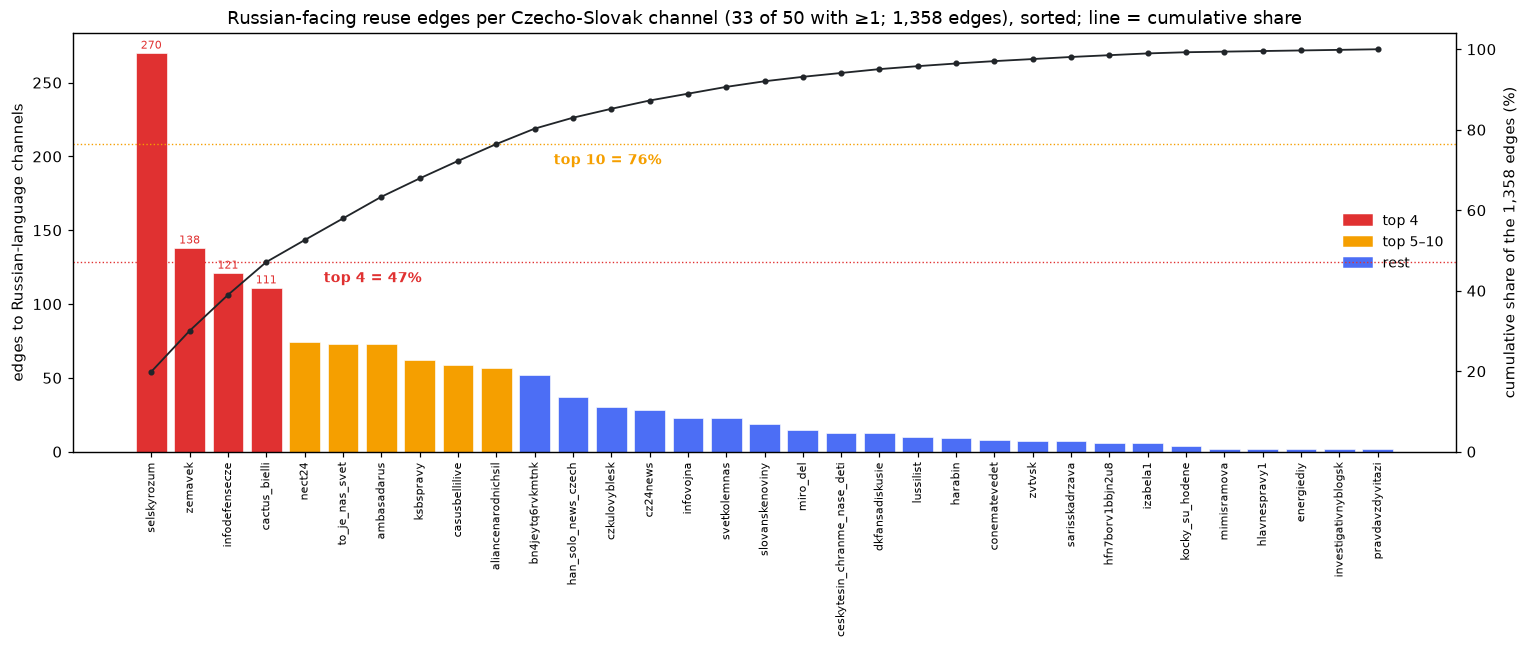

Top-15 Czecho-Slovak channels by Russian-facing edges — reach (→ru) vs internal engagement (% to cs/sk):


,channel,lang,→ ru edges,→ cs/sk edges,total degree,% edges to ru,% edges to cs/sk
0,selskyrozum,cs,270,24,333,81.1%,7.2%
1,zemavek,sk,138,22,193,71.5%,11.4%
2,infodefensecze,cs,121,16,159,76.1%,10.1%
3,cactus_bielli,sk,111,15,156,71.2%,9.6%
4,nect24,cs,74,12,96,77.1%,12.5%
5,to_je_nas_svet,cs,73,17,103,70.9%,16.5%
6,ambasadarus,sk,73,5,82,89.0%,6.1%
7,ksbspravy,sk,62,23,116,53.4%,19.8%
8,casusbellilive,sk,59,20,98,60.2%,20.4%
9,aliancenarodnichsil,cs,57,20,94,60.6%,21.3%


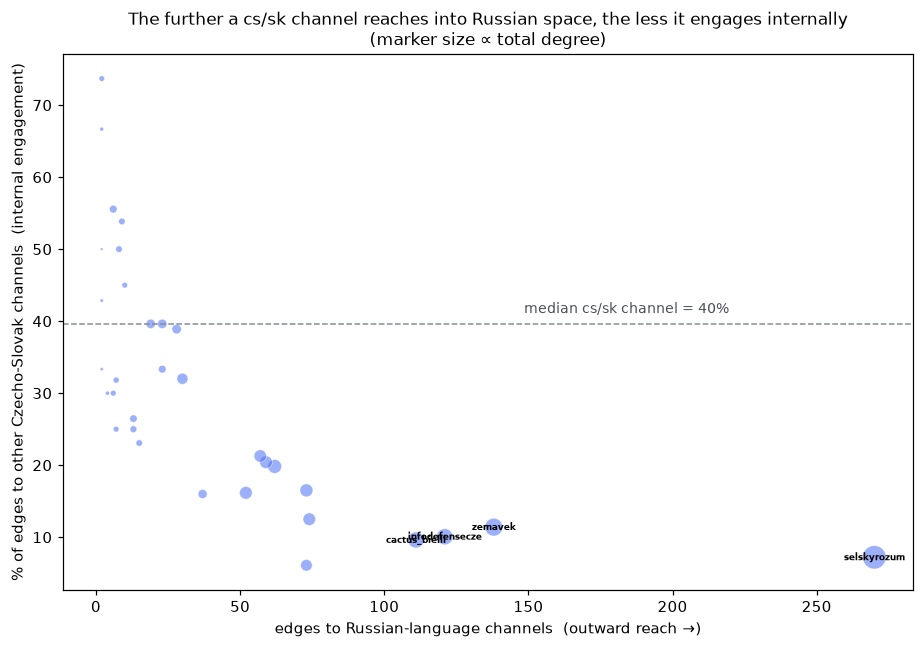

reach↔engagement Spearman ρ = -0.82


In [35]:
# ===== cs/sk → ru concentration (Pareto) + reach/engagement inversion (table + scatter) =====
import matplotlib.pyplot as plt, numpy as np, pandas as pd
from collections import Counter
_names = G_UND_GIANT.vs['name']; _h2i = {h: i for i, h in enumerate(_names)}; deg = dict(zip(_names, G_UND_GIANT.degree()))
L = lambda h: lang.get(h, 'unknown'); CSK = set(h for h in _names if L(h) in ('cs', 'sk'))
ruln = Counter(); cskln = Counter()
for h in CSK:
    for j in G_UND_GIANT.neighbors(_h2i[h]):
        o = _names[j]
        if L(o) == 'ru': ruln[h] += 1
        if o in CSK: cskln[h] += 1
_data = sorted([(h, ruln[h]) for h in CSK if ruln[h] > 0], key=lambda x: -x[1])
_hs = [h for h, _ in _data]; _vs = np.array([v for _, v in _data]); _tot = _vs.sum(); _cum = np.cumsum(_vs) / _tot * 100

# ---- Figure 1: Pareto bar chart ----
_cols = ['#e03131' if i < 4 else ('#f59f00' if i < 10 else '#4c6ef5') for i in range(len(_hs))]
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(range(len(_hs)), _vs, color=_cols, edgecolor='white', lw=0.4, zorder=2)
ax.set_xticks(range(len(_hs))); ax.set_xticklabels(_hs, rotation=90, fontsize=7.5)
ax.set_ylabel('edges to Russian-language channels'); ax.margins(x=0.01)
for i in range(4): ax.text(i, _vs[i] + 3, str(_vs[i]), ha='center', fontsize=7.5, color='#e03131')
ax2 = ax.twinx(); ax2.plot(range(len(_hs)), _cum, color='#212529', marker='o', ms=3, lw=1.2, zorder=3)
ax2.set_ylabel('cumulative share of the 1,358 edges (%)'); ax2.set_ylim(0, 104)
ax2.axhline(_cum[3], ls=':', lw=0.9, color='#e03131'); ax2.text(4.5, _cum[3] - 5, f'top 4 = {_cum[3]:.0f}%', color='#e03131', fontsize=9, fontweight='bold')
ax2.axhline(_cum[9], ls=':', lw=0.9, color='#f59f00'); ax2.text(10.5, _cum[9] - 5, f'top 10 = {_cum[9]:.0f}%', color='#f59f00', fontsize=9, fontweight='bold')
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=c) for c in ('#e03131', '#f59f00', '#4c6ef5')],
          labels=['top 4', 'top 5–10', 'rest'], loc='center right', frameon=False, fontsize=9)
ax.set_title(f'Russian-facing reuse edges per Czecho-Slovak channel ({len(_hs)} of 50 with ≥1; {_tot:,} edges), sorted; line = cumulative share', fontsize=12)
plt.tight_layout(); plt.show()

# ---- Table: top-15 by ru edges + internal engagement ----
tbl = pd.DataFrame([{'channel': h, 'lang': L(h), '→ ru edges': ruln[h], '→ cs/sk edges': cskln[h], 'total degree': deg[h],
    '% edges to ru': f'{ruln[h]/deg[h]:.1%}', '% edges to cs/sk': f'{cskln[h]/deg[h]:.1%}'} for h in _hs[:15]])
print("Top-15 Czecho-Slovak channels by Russian-facing edges — reach (→ru) vs internal engagement (% to cs/sk):")
display(tbl)

# ---- Figure 2: reach vs internal-engagement scatter ----
_xs = np.array([ruln[h] for h in _hs]); _ys = np.array([cskln[h]/deg[h]*100 for h in _hs])
_med = np.median([cskln[h]/deg[h]*100 for h in CSK if deg[h]])
fig, ax = plt.subplots(figsize=(8.5, 6))
ax.scatter(_xs, _ys, s=[deg[h]*0.7 for h in _hs], c='#4c6ef5', alpha=0.55, edgecolors='white', lw=0.5, zorder=2)
ax.axhline(_med, ls='--', color='#868e96', lw=1); ax.text(_xs.max()*0.55, _med+1.5, f'median cs/sk channel = {_med:.0f}%', color='#495057', fontsize=9)
for h in _hs[:4]:
    ax.text(ruln[h], cskln[h]/deg[h]*100, h, fontsize=6, fontweight='bold', ha='center', va='center', zorder=4)
ax.set_xlabel('edges to Russian-language channels  (outward reach →)'); ax.set_ylabel('% of edges to other Czecho-Slovak channels  (internal engagement)')
ax.set_title('The further a cs/sk channel reaches into Russian space, the less it engages internally\n(marker size ∝ total degree)', fontsize=11)
plt.tight_layout(); plt.show()
print(f"reach↔engagement Spearman ρ = {__import__('scipy.stats', fromlist=['spearmanr']).spearmanr(_xs, _ys).correlation:.2f}")

### Per-node profiles for the bridging channels

Subscriber and message profiles for the four top reachers, ranked within the broadest
Czecho-Slovak language space (all cs/sk channels in the dataset) — the basis for *"the channels
most intensely bridging the two language spaces are not the Czecho-Slovak channels that enjoy
the most views but rather the ones that post the most"*. Then each reacher's individual Russian
partners, and the shared Russian source pool of `@selskyrozum` ∩ `@zemavek`, which overlaps in
**69.6%** of cases.

In [36]:
import pandas as pd, csv, json
from collections import Counter
_nd = pd.read_csv(DATA / 'nodes.csv'); _lang = dict(zip(_nd.handle, _nd.language)); _MEMSET = set(_nd.handle)
_desc = json.load(open(DATA / 'channel_descriptions.json'))
_subs = {h: _desc.get(h, {}).get('participants_count') for h in _nd.handle}
_msg = dict(zip(_nd.handle, _nd.n_msgs)); _type = dict(zip(_nd.handle, _nd.type)); _conf = dict(zip(_nd.handle, _nd.lang_confidence))
_CSKALL = [h for h in _nd.handle if _lang.get(h) in ('cs', 'sk')]

# ===== 1) subscribers / message volume + rank within all cs/sk (broadest lang space) =====
def _rank(h, val):
    vals = sorted([(val(x) or 0) for x in _CSKALL], reverse=True); return vals.index(val(h) or 0) + 1
_N = len(_CSKALL)
_reach = ['selskyrozum', 'zemavek', 'cactus_bielli', 'infodefensecze']
print(f"Broadest cs/sk language space = {_N} channels (all cs/sk in the dataset).")
print("1a) the four cs/sk reachers — subscribers & messages, with rank among all cs/sk:")
display(pd.DataFrame([{'channel': h, 'subscribers': _subs.get(h), 'sub rank': f'{_rank(h, _subs.get):>}/{_N}',
    'messages': int(_msg.get(h, 0) or 0), 'msg rank': f'{_rank(h, _msg.get)}/{_N}'} for h in _reach]))
# top ru partners overall = top ru connectors to cs/sk
E = pd.read_csv(DATA / 'edges_unmarked.csv'); _u2 = E[E.n_semantic >= 2]
_ruc = Counter()
for r in _u2.itertuples(index=False):
    for c, o in ((r.u, r.v), (r.v, r.u)):
        if _lang.get(c) in ('cs', 'sk') and _lang.get(o) == 'ru': _ruc[o] += 1
_topru = [h for h, _ in _ruc.most_common(10)]
print("1b) the top Russian partners of the cs/sk cluster — subscribers & messages:")
display(pd.DataFrame([{'ru partner': h, 'cs/sk links': _ruc[h], 'subscribers': _subs.get(h),
    'messages': int(_msg.get(h, 0) or 0), 'title': (_desc.get(h, {}).get('title') or '')[:34]} for h in _topru]))

Broadest cs/sk language space = 122 channels (all cs/sk in the dataset).
1a) the four cs/sk reachers — subscribers & messages, with rank among all cs/sk:


,channel,subscribers,sub rank,messages,msg rank
0,selskyrozum,12443,22/122,3819,6/122
1,zemavek,32973,5/122,1808,15/122
2,cactus_bielli,1598,78/122,3559,7/122
3,infodefensecze,3421,59/122,1029,23/122


1b) the top Russian partners of the cs/sk cluster — subscribers & messages:


,ru partner,cs/sk links,subscribers,messages,title
0,allratings,20,796,5609,Караульный по рейтингам
1,odessarussi,19,22992,6748,Одесса Zа Победу! ⚓️
2,angelika_vz,15,2653,5207,Z🇷🇺 Информфронт V🇷🇺
3,osvedomitell,14,6313,8849,Война 2022 Россия-Украина WAR UKRA
4,polit_anarx,14,1804,9192,Политический анархист
5,rus_6a3a,14,511,5062,🇷🇺 6а3а
6,meerzonaa,13,2715,6765,🙏Опровержение фейков
7,otpervogolitsa,13,75186,2132,От Первого Лица | ОПЛ
8,nash_prezident_putin,13,12502,7300,НашПрезидентПУТИН
9,lisichanskinfo,12,11184,6530,«Лисичанск - колыбель Донбасса»


In [37]:
# ===== @selskyrozum ∩ @zemavek — shared Russian source pool =====
# Working graph: undirected Unmarked Network, semantic layer (n_semantic >= 2), GIANT component.
# Language labels corrected (bgbzc: ca -> bg; immaterial to the ru sets, applied for faithfulness).
import pandas as pd, numpy as np, json, igraph as ig
_nd = pd.read_csv(DATA / 'nodes.csv'); _lang = dict(zip(_nd.handle, _nd.language)); _lang['bgbzc'] = 'bg'
_desc = json.load(open(DATA / 'channel_descriptions.json'))
_subs = {h: _desc.get(h, {}).get('participants_count') for h in _nd.handle}
_E = pd.read_csv(DATA / 'edges_unmarked.csv'); _u2 = _E[_E.n_semantic >= 2]
# giant WCC of the undirected n>=2 graph
_gn = sorted({n for e in _u2[['u', 'v']].values for n in e}); _gi = {h: k for k, h in enumerate(_gn)}
_g = ig.Graph(); _g.add_vertices(len(_gn)); _g.add_edges([(_gi[a], _gi[b]) for a, b in _u2[['u', 'v']].values])
GIANT = set(_gn[i] for i in max(_g.connected_components(), key=len))

def _ru_partners(ch):                                   # {ru handle -> Σ n_semantic with ch}, giant only
    d = {}
    for r in _u2.itertuples(index=False):
        o = r.v if r.u == ch else (r.u if r.v == ch else None)
        if o is None or o not in GIANT or _lang.get(o) != 'ru': continue
        d[o] = d.get(o, 0) + int(r.n_semantic)
    return d
_S, _Z = _ru_partners('selskyrozum'), _ru_partners('zemavek')
assert len(_S) == 270 and len(_Z) == 138, (len(_S), len(_Z))   # build check

_inter = set(_S) & set(_Z); _smaller = min(len(_S), len(_Z)); _union = len(set(_S) | set(_Z))
print("Working graph: undirected Unmarked Network, semantic n_semantic>=2, giant component (corrected labels).")
print(f"BUILD CHECK — @selskyrozum ru partners = {len(_S)} (expect 270) | @zemavek = {len(_Z)} (expect 138)\n")
print("1) Russian-language partner sets — sizes & overlap:")
display(pd.DataFrame([
    {'measure': '@selskyrozum ru partners', 'value': len(_S)},
    {'measure': '@zemavek ru partners', 'value': len(_Z)},
    {'measure': 'shared (intersection)', 'value': len(_inter)},
    {'measure': 'intersection ÷ smaller set (@zemavek)', 'value': f'{len(_inter)/_smaller:.1%}'},
    {'measure': 'intersection ÷ union (Jaccard)', 'value': f'{len(_inter)/_union:.1%}'}]).set_index('measure'))
print(f"-> {len(_inter)} of @zemavek's {len(_Z)} Russian partners ({len(_inter)/_smaller:.1%}) are also @selskyrozum's: "
      f"the two draw from one shared Russian source pool, not separate ones.\n")

print(f"2) The {len(_inter)} shared Russian partners (sorted by combined matched-pair count):")
_rows = [{'ru partner': h, 'n_sem ×selskyrozum': _S[h], 'n_sem ×zemavek': _Z[h], 'combined': _S[h] + _Z[h],
          'subscribers': _subs.get(h), 'title': (_desc.get(h, {}).get('title') or '')[:30]} for h in _inter]
_df = pd.DataFrame(_rows).sort_values('combined', ascending=False).reset_index(drop=True)
with pd.option_context('display.max_rows', None):
    display(_df)

Working graph: undirected Unmarked Network, semantic n_semantic>=2, giant component (corrected labels).


BUILD CHECK — @selskyrozum ru partners = 270 (expect 270) | @zemavek = 138 (expect 138)

1) Russian-language partner sets — sizes & overlap:


,value
measure,
@selskyrozum ru partners,270
@zemavek ru partners,138
shared (intersection),96
intersection ÷ smaller set (@zemavek),69.6%
intersection ÷ union (Jaccard),30.8%


-> 96 of @zemavek's 138 Russian partners (69.6%) are also @selskyrozum's: the two draw from one shared Russian source pool, not separate ones.

2) The 96 shared Russian partners (sorted by combined matched-pair count):


,ru partner,n_sem ×selskyrozum,n_sem ×zemavek,combined,subscribers,title
0,parstodayrussian,50,5,55,29196,ParsToday Russian 🇮🇷
1,allratings,20,17,37,796,Караульный по рейтингам
2,osvedomitell,22,15,37,6313,Война 2022 Россия-Украина WAR
3,rus_6a3a,23,13,36,511,🇷🇺 6а3а
4,odessarussi,14,19,33,22992,Одесса Zа Победу! ⚓️
5,bye_biden,31,2,33,88953,БайБайден
6,mriya24,21,11,32,98692,Мрия 225
7,mislim_vmeste,10,21,31,170,Мысли вслух
8,angelika_vz,20,11,31,2653,Z🇷🇺 Информфронт V🇷🇺
9,meerzonaa,18,12,30,2715,🙏Опровержение фейков


### Table 10 · Marked ∩ unmarked — do declared forward partners overlap the reuse partners?

*Thesis Table 10: forward-partner vs reuse-partner overlap, top-4 Russian-facing channels.*

The chapter's sharpest contrast. For the four channels carrying nearly half the cs/sk↔ru
contact, the declared forward partners and the undeclared reuse partners overlap — but **every
overlapping channel is Czech or Slovak**. Not one Russian partner appears in both lists.
Widened to the whole population, only **2 of 1,358** cs/sk↔ru reuse relationships coincide with
a declared forward. The two preceding cells work `@infodefensecze` as a single case across all
three layers.

In [38]:
# ===== @infodefensecze — its partners across the undirected + directed (unmarked) AND the marked (forward) layers =====
import pandas as pd, csv
_nd = pd.read_csv(DATA / 'nodes.csv'); _lang = dict(zip(_nd.handle, _nd.language))
_E = pd.read_csv(DATA / 'edges_unmarked.csv'); _u2 = _E[_E.n_semantic >= 2]
CH = 'infodefensecze'
# marked forward edges: origin -> target (target forwarded FROM origin), weighted by count
_fwd = {}
for r in csv.DictReader(open(DATA / 'edges_forward.csv')):
    if not r['origin'].startswith('id:'): _fwd[(r['origin'], r['target'])] = int(r['count'])
def _dirverdict(r):
    nv = r.n_u_first + r.n_v_first
    if nv < 5 or (r.n_u_first and r.n_v_first):
        return 'ambiguous', nv
    src = r.u if r.n_v_first == 0 else r.v
    return (f'{CH} → partner' if src == CH else 'partner → ' + CH), nv
rows = []
for r in _u2.itertuples(index=False):
    o = r.v if r.u == CH else (r.u if r.v == CH else None)
    if o is None: continue
    verdict, nv = _dirverdict(r)
    _imp_m = _fwd.get((o, CH), 0)          # infodef declared a forward FROM partner
    _exp_m = _fwd.get((CH, o), 0)          # partner declared a forward FROM infodef
    _mv = f'{CH} ← partner' if _imp_m else ('partner ← ' + CH if _exp_m else '—')
    rows.append({'partner': o, 'language': _lang.get(o), 'matched pairs (n_sem)': r.n_semantic,
                 'nv': nv, 'unmarked directed verdict': verdict,
                 'marked fwd count': (_imp_m + _exp_m) or '', 'marked forward verdict': _mv})
df = pd.DataFrame(rows).sort_values('matched pairs (n_sem)', ascending=False).reset_index(drop=True)

print(f"@{CH}: {len(df)} partners (undirected n≥2) | languages: {dict(df.language.value_counts())}")
_imp = (df['unmarked directed verdict'] == f'partner → {CH}').sum(); _exp = (df['unmarked directed verdict'] == f'{CH} → partner').sum()
print(f"UNMARKED directed layer: {_imp+_exp} of {len(df)} orientable → {_imp} import (partner → {CH}), {_exp} export.")
_dm = (df['marked forward verdict'] != '-').sum() if '-' in set(df['marked forward verdict']) else (df['marked forward verdict'] != '—').sum()
print(f"MARKED (forward) layer: {(df['marked forward verdict'] != '—').sum()} of {len(df)} partners have a DECLARED forward tie with {CH} "
      f"→ the reuse is almost entirely undeclared.")
pd.set_option('display.max_rows', None)
display(df)

@infodefensecze: 159 partners (undirected n≥2) | languages: {'ru': np.int64(121), 'sk': np.int64(12), 'pl': np.int64(5), 'de': np.int64(5), 'cs': np.int64(4), 'es': np.int64(3), 'it': np.int64(2), 'ca': np.int64(1), 'en': np.int64(1), 'bg': np.int64(1), 'et': np.int64(1), 'ro': np.int64(1), 'fr': np.int64(1), 'pt': np.int64(1)}
UNMARKED directed layer: 14 of 159 orientable → 14 import (partner → infodefensecze), 0 export.
MARKED (forward) layer: 1 of 159 partners have a DECLARED forward tie with infodefensecze → the reuse is almost entirely undeclared.


,partner,language,matched pairs (n_sem),nv,unmarked directed verdict,marked fwd count,marked forward verdict
0,pul_nomer_3,ru,14,14,partner → infodefensecze,,—
1,meerzonaa,ru,14,14,ambiguous,,—
2,radiomirby,ru,13,13,partner → infodefensecze,,—
3,osvedomitell,ru,13,13,ambiguous,,—
4,zemavek,sk,11,11,ambiguous,,—
5,slovanskenoviny,sk,9,9,ambiguous,,—
6,ksbspravy,sk,9,9,ambiguous,,—
7,otpervogolitsa,ru,9,9,ambiguous,,—
8,angelika_vz,ru,9,9,ambiguous,,—
9,belrostv,ru,7,7,partner → infodefensecze,,—


In [39]:
# ===== @infodefensecze — its partners in the MARKED (forward) network (directed) =====
import pandas as pd, csv
_nd = pd.read_csv(DATA / 'nodes.csv'); _lang = dict(zip(_nd.handle, _nd.language))
CH = 'infodefensecze'
rows = []
for r in csv.DictReader(open(DATA / 'edges_forward.csv')):
    o, t, cnt = r['origin'], r['target'], int(r['count'])
    if r['origin'].startswith('id:'):        # keep only resolved (in-dataset) origins
        continue
    if t == CH:                              # infodef forwarded FROM origin -> it reposts origin
        rows.append({'partner': o, 'language': _lang.get(o), 'forwards': cnt, 'direction': f'{CH} ← partner  (reposts partner)'})
    elif o == CH:                            # partner forwarded FROM infodef -> partner reposts it
        rows.append({'partner': t, 'language': _lang.get(t), 'forwards': cnt, 'direction': f'partner ← {CH}  (partner reposts it)'})
df = pd.DataFrame(rows).sort_values('forwards', ascending=False).reset_index(drop=True)
_in = (df['direction'].str.startswith(f'{CH} ←')).sum(); _out = (df['direction'].str.startswith('partner ←')).sum()
print(f"@{CH} in the MARKED (forward) network: {len(df)} declared partners | "
      f"sources FROM {_in} channels (it reposts) · forwarded-from BY {_out} channels (they repost it)")
print(f"languages of its forward partners: {dict(df.language.value_counts())}")
pd.set_option('display.max_rows', None)
display(df)

@infodefensecze in the MARKED (forward) network: 3 declared partners | sources FROM 0 channels (it reposts) · forwarded-from BY 3 channels (they repost it)
languages of its forward partners: {'sk': np.int64(2), 'cs': np.int64(1)}


,partner,language,forwards,direction
0,harabin,sk,11,partner ← infodefensecze (partner reposts it)
1,hfn7borv1bbjn2u8,sk,2,partner ← infodefensecze (partner reposts it)
2,zlom221,cs,1,partner ← infodefensecze (partner reposts it)


In [40]:
# ===== marked ∩ unmarked: do declared-forward partners overlap the undeclared reuse partners? =====
import pandas as pd, csv
_nd = pd.read_csv(DATA / 'nodes.csv'); _lang = dict(zip(_nd.handle, _nd.language))
_E = pd.read_csv(DATA / 'edges_unmarked.csv'); _u2 = _E[_E.n_semantic >= 2]
# declared forward partners per node (either direction; resolved origins only)
_fpart = {}
for r in csv.DictReader(open(DATA / 'edges_forward.csv')):
    if r['origin'].startswith('id:'): continue
    _fpart.setdefault(r['origin'], set()).add(r['target']); _fpart.setdefault(r['target'], set()).add(r['origin'])
# unmarked reuse partners per node
_reuse = {}; _reuse_ru = {}
for r in _u2.itertuples(index=False):
    for a, b in ((r.u, r.v), (r.v, r.u)):
        _reuse.setdefault(a, set()).add(b)
        if _lang.get(b) == 'ru': _reuse_ru.setdefault(a, set()).add(b)
rows = []
for h in ('selskyrozum', 'zemavek', 'cactus_bielli', 'infodefensecze'):
    fp = _fpart.get(h, set()); ru = _reuse_ru.get(h, set()); al = _reuse.get(h, set())
    both = fp & al
    rows.append({'channel': h,
                 'declares forwards from (marked)': len(fp),
                 'reuses from ru (unmarked)': len(ru),
                 'reuses from any (unmarked)': len(al),
                 'channels in BOTH lists': len(both),
                 'the overlapping channels': sorted(both) if both else '— none —'})
display(pd.DataFrame(rows))
print("Read: the declared-forward partner set and the undeclared-reuse partner set are disjoint for all three —")
print("the channels they credit (forward) are never the channels they actually reuse.")

,channel,declares forwards from (marked),reuses from ru (unmarked),reuses from any (unmarked),channels in BOTH lists,the overlapping channels
0,selskyrozum,27,270,333,14,"[aliancenarodnichsil, casusbellilive, czkulovyblesk, harabin, hfn7borv1bbjn2u8, infovojna, ksbspravy, lussilist, nect24, s4illimati, slovanskenoviny, svetkolemnas, to_je_nas_svet, zemavek]"
1,zemavek,25,138,193,8,"[aliancenarodnichsil, conematevedet, czkulovyblesk, harabin, infovojna, ksbspravy, selskyrozum, svetkolemnas]"
2,cactus_bielli,5,111,156,2,"[harabin, ksbspravy]"
3,infodefensecze,3,121,159,1,[harabin]


Read: the declared-forward partner set and the undeclared-reuse partner set are disjoint for all three —
the channels they credit (forward) are never the channels they actually reuse.


In [41]:
# ===== marked ∩ unmarked, restricted to the cs/sk ↔ RU contact only =====
import pandas as pd, csv
_nd = pd.read_csv(DATA / 'nodes.csv'); _lang = dict(zip(_nd.handle, _nd.language))
_E = pd.read_csv(DATA / 'edges_unmarked.csv'); _u2 = _E[_E.n_semantic >= 2]
# declared-forward RU partners per node (either direction; resolved origins only)
_fru = {}
for r in csv.DictReader(open(DATA / 'edges_forward.csv')):
    if r['origin'].startswith('id:'): continue
    o, t = r['origin'], r['target']
    if _lang.get(o) == 'ru': _fru.setdefault(t, set()).add(o)
    if _lang.get(t) == 'ru': _fru.setdefault(o, set()).add(t)
# reused RU partners per node (unmarked)
_rru = {}
for r in _u2.itertuples(index=False):
    for a, b in ((r.u, r.v), (r.v, r.u)):
        if _lang.get(b) == 'ru': _rru.setdefault(a, set()).add(b)
rows = []
for h in ('selskyrozum', 'zemavek', 'cactus_bielli', 'infodefensecze'):
    fru = _fru.get(h, set()); rru = _rru.get(h, set()); both = fru & rru
    rows.append({'channel': h, 'declares forwards from ru (marked)': len(fru),
                 'reuses from ru (unmarked)': len(rru), 'ru channels in BOTH': len(both),
                 'overlapping ru channels': sorted(both) if both else '— none —'})
display(pd.DataFrame(rows))
print("Read: of the Russian channels each node reuses, none are ones it declares a forward from —")
print("the entire Russian intake is undeclared (0 of 270 / 138 / 111).")

,channel,declares forwards from ru (marked),reuses from ru (unmarked),ru channels in BOTH,overlapping ru channels
0,selskyrozum,0,270,0,— none —
1,zemavek,0,138,0,— none —
2,cactus_bielli,0,111,0,— none —
3,infodefensecze,0,121,0,— none —


Read: of the Russian channels each node reuses, none are ones it declares a forward from —
the entire Russian intake is undeclared (0 of 270 / 138 / 111).


### Figure 14 · Division of labour — marked community role vs undeclared Russian reuse

*Thesis Figure 14: marked reservoir role vs undeclared Russian reuse per channel.*

Moves the reservoir-vs-importer split of Chapter 3 from named channels to the whole cs/sk
community: does a channel's role in the *declared* layer predict its *undeclared* reuse with
Russian channels? For the largest reservoirs it does — `@selskyrozum` and `@zemavek` are both
top marked reservoirs and top Russian reusers — but across the population the correlation is
weak (ρ = 0.252, p = 0.081), which is why the chapter confines the claim to a handful of nodes.
`@akwsk`, the third-ranked reservoir with no Russian reuse at all, is the counter-example it
names.

marked cs/sk community: 112 cs/sk channels; 49 of them also in the UNMARKED network (the comparable set) | 105 declared imports
Spearman(reservoir supply, ru-reuse) = 0.252 (p=8.1e-02) | Spearman(importer, ru-reuse) = -0.022 (p=0.88)

role typology (net supplier vs net importer) and their undeclared Russian reuse:


,role,channels,median_ru_reuse,mean_ru_reuse,zero_ru_reuse
0,balanced/neither,4,4.0,5.250000,1
1,importer (import>supply),8,6.5,17.625000,2
2,reservoir (supply>import),37,8.0,32.324324,13


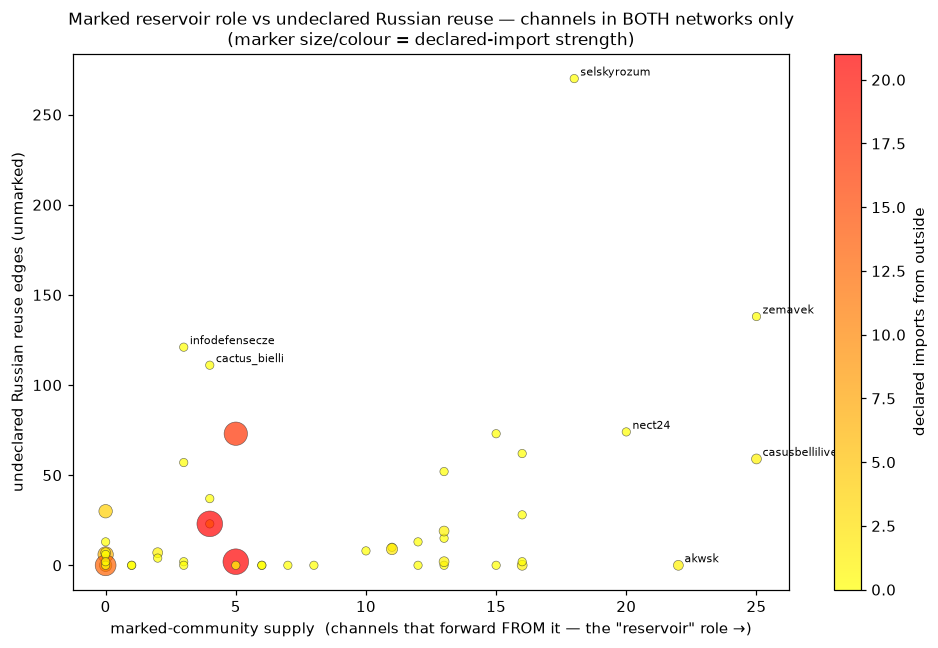

Restricted to channels in both networks, reservoirs reuse ru more heavily (mean 32 vs importers 18) and the importer↔reuse link is flat; akwsk is the visible reservoir outlier (high supply, 0 ru-reuse), infodefensecze the mirror (low supply, heavy ru-reuse).


In [42]:
# ===== division of labour — marked cs/sk-community role vs unmarked ru-reuse (whole population) =====
import pandas as pd, numpy as np, igraph as ig, random, leidenalg, csv
import matplotlib.pyplot as plt
from collections import Counter
from scipy.stats import spearmanr
_nd = pd.read_csv(DATA / 'nodes.csv'); _lang = dict(zip(_nd.handle, _nd.language)); _MEM = set(_nd.handle)
# marked forward giant + Leiden -> the cs/sk community (community 10)
# construction VERBATIM from marked_network.ipynb (edge-endpoints only, drop self-loops & id: origins,
# MIN_EDGE_COUNT=1, giant WCC) so the partition matches the Marked chapter: community 10 = 136 members / 105 imports.
_fe = []
for r in csv.DictReader(open(DATA / 'edges_forward.csv')):
    o, t, cnt = r['origin'], r['target'], int(r['count'])
    if o.startswith('id:') or o == t or cnt < 1: continue
    _fe.append((o, t))
_mn = sorted({n for e in _fe for n in e}); _mi = {h: k for k, h in enumerate(_mn)}
_gd = ig.Graph(directed=True); _gd.add_vertices(len(_mn)); _gd.vs['name'] = _mn
_gd.add_edges([(_mi[o], _mi[t]) for o, t in _fe])
_gd = _gd.induced_subgraph(max(_gd.connected_components(mode='weak'), key=len))
_gu = _gd.as_undirected(mode='collapse')
_mm = np.array(leidenalg.find_partition(_gu, leidenalg.ModularityVertexPartition, seed=42, n_iterations=10).membership)
_mnames = np.array(_gd.vs['name'])
_cskc = max(set(_mm.tolist()), key=lambda c: sum(1 for v in np.where(_mm == c)[0] if _lang.get(_mnames[v]) in ('cs', 'sk')))
COMM = set(_mnames[v] for v in np.where(_mm == _cskc)[0])
# roles on the giant's forward edges (import = outside->member, supply = member->member), as in marked_network.ipynb
_sup = Counter(); _imp = Counter()
for e in _gd.es:
    o, t = _mnames[e.source], _mnames[e.target]
    if o in COMM and t in COMM: _sup[o] += 1
    if t in COMM and o not in COMM: _imp[t] += 1
# unmarked ru-reuse
E = pd.read_csv(DATA / 'edges_unmarked.csv'); _u2 = E[E.n_semantic >= 2]; CSK = set(h for h in _MEM if _lang.get(h) in ('cs', 'sk'))
_ru = Counter()
for r in _u2.itertuples(index=False):
    for c, o in ((r.u, r.v), (r.v, r.u)):
        if c in CSK and _lang.get(o) == 'ru': _ru[c] += 1
_UNM = set(G_UND_GIANT.vs['name'])                      # only channels that appear in the unmarked network
_comm = [h for h in COMM if _lang.get(h) in ('cs', 'sk') and h in _UNM]
_s = np.array([_sup[h] for h in _comm]); _i = np.array([_imp[h] for h in _comm]); _r = np.array([_ru.get(h, 0) for h in _comm])
print(f"marked cs/sk community: {sum(1 for h in COMM if _lang.get(h) in ('cs','sk'))} cs/sk channels; {len(_comm)} of them also in the UNMARKED network (the comparable set) | {sum(_imp.values())} declared imports")
print(f"Spearman(reservoir supply, ru-reuse) = {spearmanr(_s,_r).correlation:.3f} (p={spearmanr(_s,_r).pvalue:.1e}) | "
      f"Spearman(importer, ru-reuse) = {spearmanr(_i,_r).correlation:.3f} (p={spearmanr(_i,_r).pvalue:.2f})")

# ---- typology table: net role vs median ru-reuse ----
_role = ['reservoir (supply>import)' if _sup[h] > _imp[h] else ('importer (import>supply)' if _imp[h] > _sup[h] else 'balanced/neither') for h in _comm]
_typ = pd.DataFrame({'handle': _comm, 'role': _role, 'ru-reuse': _r})
_agg = _typ.groupby('role').agg(channels=('handle', 'size'), median_ru_reuse=('ru-reuse', 'median'),
                                mean_ru_reuse=('ru-reuse', 'mean'), zero_ru_reuse=('ru-reuse', lambda s: int((s == 0).sum()))).reset_index()
print("\nrole typology (net supplier vs net importer) and their undeclared Russian reuse:")
display(_agg)

# ---- scatter: supply (reservoir) vs ru-reuse, marker = importer strength ----
fig, ax = plt.subplots(figsize=(9, 6))
_sizes = 30 + 12 * _i
ax.scatter(_s, _r, s=_sizes, c=_i, cmap='autumn_r', alpha=0.7, edgecolors='#333', lw=0.4)
for h in ('selskyrozum', 'zemavek', 'cactus_bielli', 'infodefensecze', 'nect24', 'casusbellilive', 'akwsk'):
    if h in _comm:
        j = _comm.index(h); ax.annotate(h, (_sup[h], _ru.get(h, 0)), fontsize=7, xytext=(4, 2), textcoords='offset points')
ax.set_xlabel('marked-community supply  (channels that forward FROM it — the "reservoir" role →)')
ax.set_ylabel('undeclared Russian reuse edges (unmarked)')
ax.set_title('Marked reservoir role vs undeclared Russian reuse — channels in BOTH networks only\n(marker size/colour = declared-import strength)', fontsize=11)
cb = plt.colorbar(ax.collections[0], ax=ax); cb.set_label('declared imports from outside')
plt.tight_layout(); plt.show()
print("Restricted to channels in both networks, reservoirs reuse ru more heavily (mean 32 vs importers 18) and the importer↔reuse link is flat; "
      "akwsk is the visible reservoir outlier (high supply, 0 ru-reuse), infodefensecze the mirror (low supply, heavy ru-reuse).")

### The shared Russian source pool across the content reservoirs

Pair-by-pair, for the top marked-network content reservoirs present in the unmarked giant: how
far their Russian-partner sets overlap, how much of the shared pool the directed layer can
orient, and which way those oriented edges point. Backs *"eight share edges with Russian nodes
… 352 Russian nodes reached cumulatively, of which 167 share an edge with at least 2 of the
top-10"*, the 40–92% overlap range, and the **45 of 45** shared-pool edges that put the Russian
node first.

In [43]:
# ===== pair-by-pair Russian-source overlap across the top content reservoirs =====
# Working graph: undirected Unmarked Network, semantic n_semantic>=2, GIANT component. Corrected labels (bgbzc->bg).
# Reservoirs = top marked-network content reservoirs (internal reach in the marked cs/sk community) present in the giant.
# Overlap, orientability, and direction are all computed on the SHARED (common-pool) Russian partners of each pair.
import pandas as pd, numpy as np, csv, igraph as ig, leidenalg
from itertools import combinations
_nd = pd.read_csv(DATA / 'nodes.csv'); _lang = dict(zip(_nd.handle, _nd.language)); _lang['bgbzc'] = 'bg'
_E = pd.read_csv(DATA / 'edges_unmarked.csv'); _u2 = _E[_E.n_semantic >= 2]
_gn = sorted({n for e in _u2[['u', 'v']].values for n in e}); _gi = {h: k for k, h in enumerate(_gn)}
_g = ig.Graph(); _g.add_vertices(len(_gn)); _g.add_edges([(_gi[a], _gi[b]) for a, b in _u2[['u', 'v']].values])
GIANT = set(_gn[i] for i in max(_g.connected_components(), key=len))

def _dir(r, ch):
    # None if the ch<->ru edge is not orientable; else 'ru' (Russian posted first) / 'cssk' (reservoir first)
    nv = r.n_u_first + r.n_v_first
    if nv < 5 or not (r.n_u_first == 0 or r.n_v_first == 0): return None
    origin = r.u if r.n_v_first == 0 else r.v
    ru = r.v if r.u == ch else r.u
    return 'ru' if origin == ru else 'cssk'
def _ru_map(ch):                                         # {ru partner -> 'ru' / 'cssk' / None}, giant only
    d = {}
    for r in _u2.itertuples(index=False):
        o = r.v if r.u == ch else (r.u if r.v == ch else None)
        if o is not None and o in GIANT and _lang.get(o) == 'ru': d[o] = _dir(r, ch)
    return d

# --- top marked content reservoirs (internal reach in the marked cs/sk community), verbatim marked build ---
_fe = []
for r in csv.DictReader(open(DATA / 'edges_forward.csv')):
    o, t, cnt = r['origin'], r['target'], int(r['count'])
    if o.startswith('id:') or o == t or cnt < 1: continue
    _fe.append((o, t))
_mn = sorted({n for e in _fe for n in e}); _mi = {h: k for k, h in enumerate(_mn)}
_G = ig.Graph(directed=True); _G.add_vertices(len(_mn)); _G.vs['name'] = _mn
_G.add_edges([(_mi[o], _mi[t]) for o, t in _fe]); _G = _G.induced_subgraph(max(_G.connected_components(mode='weak'), key=len))
_mm = np.array(leidenalg.find_partition(_G.as_undirected(mode='collapse'), leidenalg.ModularityVertexPartition, seed=42, n_iterations=10).membership)
_gv = np.array(_G.vs['name']); _C10 = max(set(_mm.tolist()), key=lambda c: sum(1 for i in np.where(_mm == c)[0] if _lang.get(_gv[i]) in ('cs', 'sk')))
_midx = np.where(_mm == _C10)[0]; _sub = _G.induced_subgraph(_midx.tolist())
_reach = np.array(_sub.degree(mode='out')); _sn = np.array(_sub.vs['name'])
_order = np.argsort(_reach)[::-1]
TOPN = 10
_res = [(_sn[i], int(_reach[i])) for i in _order if _sn[i] in GIANT][:TOPN]
_handles = [h for h, _ in _res]; RU = {h: _ru_map(h) for h in _handles}

print(f"Top {TOPN} marked content reservoirs present in the unmarked giant (by marked internal reach):")
display(pd.DataFrame([{'reservoir': h, 'marked internal reach': rc, 'ru partners (unmarked)': len(RU[h])} for h, rc in _res]).set_index('reservoir'))

# --- ALL C(TOPN,2) pairs: overlap of the shared pool + orientability + direction polarity ---
# direction score in [-1, +1] over the pair's shared+orientable edges: +1 = all point ru->cs/sk (Russian origin), -1 = all cs/sk->ru
_rows = []
for a, b in combinations(_handles, 2):
    A, B = RU[a], RU[b]; sh = set(A) & set(B); sm = min(len(A), len(B)); un = len(A | B)
    _ori = [A[pt] for pt in sh if A[pt]] + [B[pt] for pt in sh if B[pt]]
    _nor = len(_ori); _ruf = _ori.count('ru'); _csf = _ori.count('cssk')
    _dsc = (_ruf - _csf) / _nor if _nor else None
    _rows.append({'pair': f'{a} ∩ {b}', '|A|': len(A), '|B|': len(B), 'shared': len(sh),
                  'share of smaller': f'{len(sh)/sm:.0%}' if sm else '—',
                  'Jaccard': f'{len(sh)/un:.0%}' if un else '—',
                  'orientable (of 2×shared)': f'{_nor}/{2*len(sh)}',
                  'direction (−1..+1)': f'{_dsc:+.2f}' if _dsc is not None else '—',
                  '_ss': len(sh)/sm if sm else -1})
_df = pd.DataFrame(_rows).sort_values(['_ss'], ascending=False).drop(columns='_ss').reset_index(drop=True)
print(f"\nAll {len(_df)} reservoir pairs (C({TOPN},2)), sorted by overlap. direction: +1 = every orientable shared edge is ru→cs/sk:")
with pd.option_context('display.max_rows', None):
    display(_df)
# totals + direction agreement over the UNIQUE orientable reservoir<->ru relationships
_rel = {(h, pt): d for h in _handles for pt, d in RU[h].items() if d}
_ruf = sum(1 for d in _rel.values() if d == 'ru'); _tot = len(_rel)
_zero = [str(h) for h in _handles if len(RU[h]) == 0]
print(f"-> reservoirs share one Russian pool: ru-active pairs overlap 25-92% of the smaller set. "
      f"Direction is unanimous: of the {_tot} unique orientable reservoir↔ru relationships, {_ruf}/{_tot} = {_ruf/_tot:.0%} are ru→cs/sk "
      f"(score +1.00 on every pair that has any orientable shared edge). Pure-domestic reservoirs with NO Russian intake: {_zero}.")

Top 10 marked content reservoirs present in the unmarked giant (by marked internal reach):


,marked internal reach,ru partners (unmarked)
reservoir,,
zemavek,25,138
casusbellilive,25,59
akwsk,22,0
nect24,20,74
selskyrozum,18,270
genivansevcik,16,0
cz24news,16,28
mimisramova,16,2
ksbspravy,16,62



All 45 reservoir pairs (C(10,2)), sorted by overlap. direction: +1 = every orientable shared edge is ru→cs/sk:


,pair,|A|,|B|,shared,share of smaller,Jaccard,orientable (of 2×shared),direction (−1..+1)
0,nect24 ∩ selskyrozum,74,270,68,92%,25%,16/136,+1.00
1,selskyrozum ∩ cz24news,270,28,23,82%,8%,2/46,+1.00
2,selskyrozum ∩ to_je_nas_svet,270,73,56,77%,20%,9/112,+1.00
3,casusbellilive ∩ selskyrozum,59,270,43,73%,15%,0/86,—
4,zemavek ∩ selskyrozum,138,270,96,70%,31%,27/192,+1.00
5,zemavek ∩ cz24news,138,28,19,68%,13%,2/38,+1.00
6,selskyrozum ∩ ksbspravy,270,62,42,68%,14%,3/84,+1.00
7,zemavek ∩ nect24,138,74,46,62%,28%,9/92,+1.00
8,zemavek ∩ to_je_nas_svet,138,73,45,62%,27%,6/90,+1.00
9,zemavek ∩ casusbellilive,138,59,34,58%,21%,4/68,+1.00


-> reservoirs share one Russian pool: ru-active pairs overlap 25-92% of the smaller set. Direction is unanimous: of the 45 unique orientable reservoir↔ru relationships, 45/45 = 100% are ru→cs/sk (score +1.00 on every pair that has any orientable shared edge). Pure-domestic reservoirs with NO Russian intake: ['akwsk', 'genivansevcik'].


In [44]:
# ===== SIMPLIFIED DECONSTRUCTION — two pairwise reservoir tables (overlap · directed share + direction) =====
import pandas as pd, numpy as np, csv, igraph as ig, leidenalg
import matplotlib.pyplot as plt, matplotlib.colors as _mc
from collections import Counter
_nd = pd.read_csv(DATA / 'nodes.csv'); _lang = dict(zip(_nd.handle, _nd.language)); _lang['bgbzc'] = 'bg'
_E = pd.read_csv(DATA / 'edges_unmarked.csv'); _u2 = _E[_E.n_semantic >= 2]
_gn = sorted({n for e in _u2[['u', 'v']].values for n in e}); _gi = {h: k for k, h in enumerate(_gn)}
_g = ig.Graph(); _g.add_vertices(len(_gn)); _g.add_edges([(_gi[a], _gi[b]) for a, b in _u2[['u', 'v']].values])
GIANT = set(_gn[i] for i in max(_g.connected_components(), key=len))
def _dir(r, ch):
    nv = r.n_u_first + r.n_v_first
    if nv < 5 or not (r.n_u_first == 0 or r.n_v_first == 0): return None
    origin = r.u if r.n_v_first == 0 else r.v; ru = r.v if r.u == ch else r.u
    return 'ru' if origin == ru else 'cssk'
def _ru_map(ch):
    d = {}
    for r in _u2.itertuples(index=False):
        o = r.v if r.u == ch else (r.u if r.v == ch else None)
        if o is not None and o in GIANT and _lang.get(o) == 'ru': d[o] = _dir(r, ch)
    return d
_fe = []
for r in csv.DictReader(open(DATA / 'edges_forward.csv')):
    o, t, cnt = r['origin'], r['target'], int(r['count'])
    if o.startswith('id:') or o == t or cnt < 1: continue
    _fe.append((o, t))
_mn = sorted({n for e in _fe for n in e}); _mi = {h: k for k, h in enumerate(_mn)}
_G = ig.Graph(directed=True); _G.add_vertices(len(_mn)); _G.vs['name'] = _mn
_G.add_edges([(_mi[o], _mi[t]) for o, t in _fe]); _G = _G.induced_subgraph(max(_G.connected_components(mode='weak'), key=len))
_mm = np.array(leidenalg.find_partition(_G.as_undirected(mode='collapse'), leidenalg.ModularityVertexPartition, seed=42, n_iterations=10).membership)
_gv = np.array(_G.vs['name']); _C10 = max(set(_mm.tolist()), key=lambda c: sum(1 for i in np.where(_mm == c)[0] if _lang.get(_gv[i]) in ('cs', 'sk')))
_midx = np.where(_mm == _C10)[0]; _sub = _G.induced_subgraph(_midx.tolist())
_reach = np.array(_sub.degree(mode='out')); _sn = np.array(_sub.vs['name'])
_handles = [_sn[i] for i in np.argsort(_reach)[::-1] if _sn[i] in GIANT][:10]
RU = {h: _ru_map(h) for h in _handles}
_active = sorted([h for h in _handles if len(RU[h]) > 0], key=lambda h: -len(RU[h]))   # ru-active, largest set first
_zero = [str(h) for h in _handles if len(RU[h]) == 0]
_n = len(_active)

# ---- overlap matrix O (colour source for BOTH tables) ----
O = pd.DataFrame(index=_active, columns=_active, dtype=float)
for a in _active:
    for b in _active:
        A, B = set(RU[a]), set(RU[b])
        O.loc[a, b] = 1.0 if a == b else len(A & B) / min(len(A), len(B))

# ---- Table A text = overlap % ;  Table B text = directable% (direction index) ----
def _fmt_pct(v): return f'{v:.0%}'
def _cellB(a, b):
    if a == b: edges = list(RU[a].values())                        # diagonal = the reservoir's own ru edges
    else:
        sh = set(RU[a]) & set(RU[b]); edges = [RU[a][s] for s in sh] + [RU[b][s] for s in sh]
    tot = len(edges)
    if tot == 0: return '—'
    ori = [d for d in edges if d is not None]
    if not ori: return f'{0:.0%}'
    _idx = (ori.count('ru') - ori.count('cssk')) / len(ori)         # +1 = ru->cs/sk, -1 = cs/sk->ru
    return f'{len(ori)/tot:.0%} ({"%+g" % _idx})'
TA = pd.DataFrame([[_fmt_pct(O.iat[i, j]) for j in range(_n)] for i in range(_n)], index=_active, columns=_active)
TB = pd.DataFrame([[_cellB(a, b) for b in _active] for a in _active], index=_active, columns=_active)

_cmap = plt.get_cmap('YlOrRd')
def _css(v):
    hexc = _mc.to_hex(_cmap(0.0 if pd.isna(v) else float(v)))
    return f'background-color:{hexc};color:{"white" if (not pd.isna(v) and v > 0.6) else "black"};'
def _colorer(_): return pd.DataFrame([[_css(O.iat[i, j]) for j in range(_n)] for i in range(_n)], index=_active, columns=_active)

print("Table A — pairwise Russian-neighbour overlap (share of the smaller reservoir's Russian-partner set):")
display(TA.style.apply(_colorer, axis=None).set_properties(**{'text-align': 'center', 'min-width': '60px'}))
print("\nTable B — of the shared Russian sources' edges toward the two reservoirs: % in the directed layer, and (direction index +1=ru→cs/sk … −1=cs/sk→ru). Coloured by overlap (Table A). Diagonal = the reservoir's own Russian edges.")
display(TB.style.apply(_colorer, axis=None).set_properties(**{'text-align': 'center', 'min-width': '78px'}))

# ---- one-line aggregates ----
_mult = Counter(o for h in _active for o in RU[h]); _uni = len(_mult); _shared = sum(1 for v in _mult.values() if v >= 2)
_SH = {o for o, c in _mult.items() if c >= 2}
_se = [RU[h][o] for h in _active for o in RU[h] if o in _SH]; _so = sum(1 for d in _se if d is not None)
_ruf = sum(1 for h in _active for o in RU[h] if o in _SH and RU[h][o] == 'ru')
print(f"\nAcross the {_n} Russian-active reservoirs: {_uni} distinct Russian sources, {_shared} ({_shared/_uni:.0%}) reused by ≥2 (the shared pool). "
      f"Of the {len(_se)} shared-pool edges toward these reservoirs, {_so} ({_so/len(_se):.1%}) are in the directed layer — and all {_ruf} of them run ru→cs/sk (index +1). "
      f"Reservoirs with no Russian intake, outside the pool: {_zero}.")

Table A — pairwise Russian-neighbour overlap (share of the smaller reservoir's Russian-partner set):


,selskyrozum,zemavek,nect24,to_je_nas_svet,ksbspravy,casusbellilive,cz24news,mimisramova
selskyrozum,100%,70%,92%,77%,68%,73%,82%,50%
zemavek,70%,100%,62%,62%,50%,58%,68%,0%
nect24,92%,62%,100%,41%,40%,29%,54%,0%
to_je_nas_svet,77%,62%,41%,100%,35%,41%,57%,0%
ksbspravy,68%,50%,40%,35%,100%,25%,39%,0%
casusbellilive,73%,58%,29%,41%,25%,100%,46%,0%
cz24news,82%,68%,54%,57%,39%,46%,100%,0%
mimisramova,50%,0%,0%,0%,0%,0%,0%,100%



Table B — of the shared Russian sources' edges toward the two reservoirs: % in the directed layer, and (direction index +1=ru→cs/sk … −1=cs/sk→ru). Coloured by overlap (Table A). Diagonal = the reservoir's own Russian edges.


,selskyrozum,zemavek,nect24,to_je_nas_svet,ksbspravy,casusbellilive,cz24news,mimisramova
selskyrozum,11% (+1),14% (+1),12% (+1),8% (+1),4% (+1),0%,4% (+1),0%
zemavek,14% (+1),11% (+1),10% (+1),7% (+1),11% (+1),6% (+1),5% (+1),—
nect24,12% (+1),10% (+1),1% (+1),0%,0%,0%,0%,—
to_je_nas_svet,8% (+1),7% (+1),0%,0%,0%,0%,0%,—
ksbspravy,4% (+1),11% (+1),0%,0%,0%,0%,0%,—
casusbellilive,0%,6% (+1),0%,0%,0%,0%,0%,—
cz24news,4% (+1),5% (+1),0%,0%,0%,0%,0%,—
mimisramova,0%,—,—,—,—,—,—,0%



Across the 8 Russian-active reservoirs: 352 distinct Russian sources, 167 (47%) reused by ≥2 (the shared pool). Of the 521 shared-pool edges toward these reservoirs, 33 (6.3%) are in the directed layer — and all 33 of them run ru→cs/sk (index +1). Reservoirs with no Russian intake, outside the pool: ['akwsk', 'genivansevcik'].


### Figures 15 & 16 · Russian-partner overlap between the top marked content reservoirs

*Thesis Figure 15 (Russian-partner overlap between top marked content reservoirs) and
Figure 16 (the same overlap with directional coverage overlaid).*

Figure 16's direction index runs to −1 when the oriented edges point toward the Russian nodes
and to +1 when they point toward the Czecho-Slovak ones; every populated cell reads +1, i.e.
the Russian node published first in every orientable case.

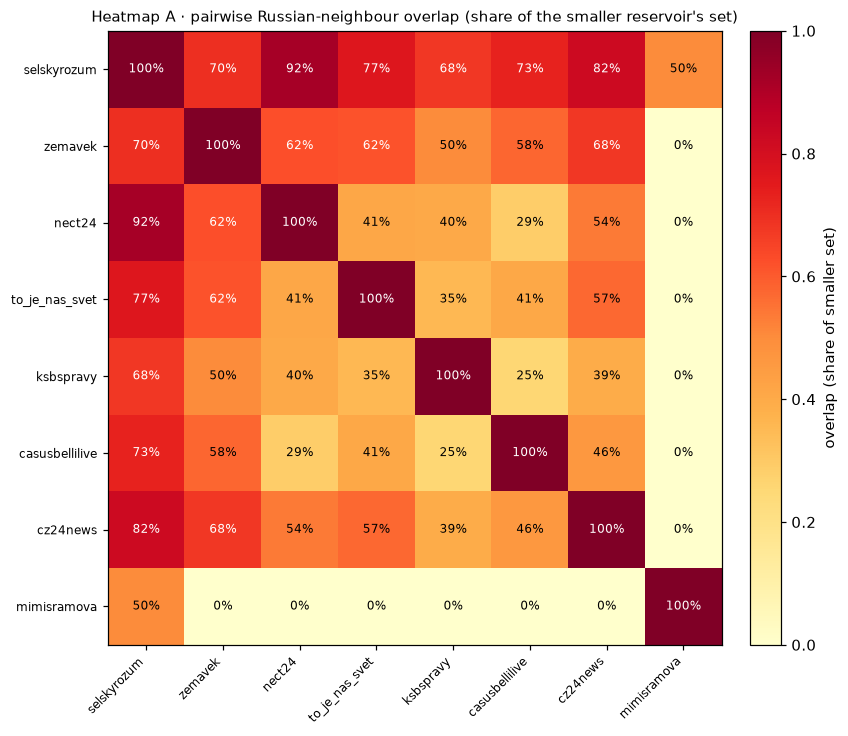

In [45]:
# ===== Heatmap A · pairwise Russian-neighbour overlap =====
# (reuses O / TA / _active / _n from the deconstruction cell above)
import matplotlib.pyplot as plt
_Om = O.values.astype(float)
_cm = plt.get_cmap('YlOrRd').copy(); _cm.set_bad('#e8e8e8')
fig, ax = plt.subplots(figsize=(7.8, 6.8))
im = ax.imshow(_Om, cmap=_cm, vmin=0, vmax=1)
ax.set_xticks(range(_n)); ax.set_yticks(range(_n))
ax.set_xticklabels(_active, rotation=45, ha='right', fontsize=8); ax.set_yticklabels(_active, fontsize=8)
for i in range(_n):
    for j in range(_n):
        ax.text(j, i, TA.iat[i, j], ha='center', va='center', fontsize=8, color='white' if _Om[i, j] > 0.6 else 'black')
ax.set_title("Heatmap A · pairwise Russian-neighbour overlap (share of the smaller reservoir's set)", fontsize=10)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='overlap (share of smaller set)')
plt.tight_layout(); plt.show()

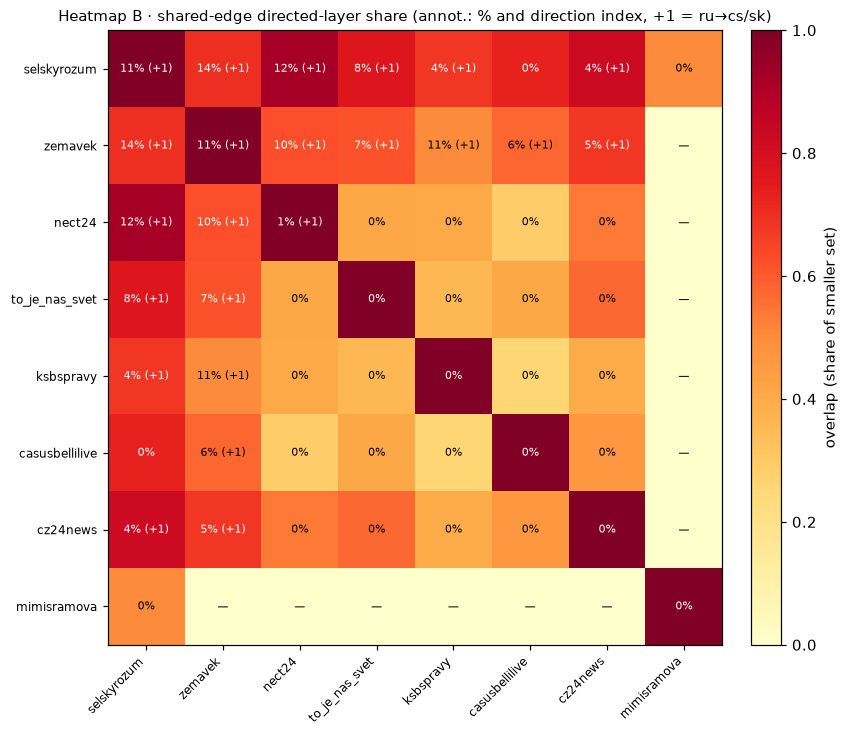

In [46]:
# ===== Heatmap B · shared-edge directed-layer share & direction =====
# (reuses O / TB / _active / _n from the deconstruction cell above; coloured by overlap to match Table B)
import matplotlib.pyplot as plt
_Om = O.values.astype(float)
_cm = plt.get_cmap('YlOrRd').copy(); _cm.set_bad('#e8e8e8')
fig, ax = plt.subplots(figsize=(7.8, 6.8))
im = ax.imshow(_Om, cmap=_cm, vmin=0, vmax=1)
ax.set_xticks(range(_n)); ax.set_yticks(range(_n))
ax.set_xticklabels(_active, rotation=45, ha='right', fontsize=8); ax.set_yticklabels(_active, fontsize=8)
for i in range(_n):
    for j in range(_n):
        ax.text(j, i, TB.iat[i, j], ha='center', va='center', fontsize=7.5, color='white' if _Om[i, j] > 0.6 else 'black')
ax.set_title('Heatmap B · shared-edge directed-layer share (annot.: % and direction index, +1 = ru→cs/sk)', fontsize=9.5)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='overlap (share of smaller set)')
plt.tight_layout(); plt.show()

### A worked exhibit — three of `@selskyrozum`'s Russian-first pairs

The structure above, made concrete: a Russian source posts first, `@selskyrozum` posts the same item
in Czech hours later. Texts pulled from the raw scraped messages at the time of writing and
reproduced statically — the raw message corpus is not part of the frozen bundle.

**1 · `otpervogolitsa` → `selskyrozum` — cosine 0.991, gap 3.3 h**
> RU (26 Jan 12:52): *«США оказывают давление на Турцию, чтобы она прекратила пускать российские самолёты американского производства, пишет WSJ…»*
> CS (26 Jan 16:10): *«USA vyvíjejí tlak na Turecko, aby přestalo vypouštět ruská letadla americké výroby, píše WSJ…»*

**2 · `bye_biden` → `selskyrozum` — cosine 0.987, gap 4.5 h**
> RU (24 Jan 10:53): *«Глава украинского МИД Кулеба настаивает на запрете российских СМИ…»*
> CS (24 Jan 15:24): *«Ukrajinský ministr zahraničí Kuleba trvá na zákazu ruských médií…»*

**3 · `bioomberg` → `selskyrozum` — cosine 0.987, gap 3.1 h**
> RU (17 Jan 06:11): *«Впервые за 60 лет в 2022 году население Китая начало сокращаться…»*
> CS (17 Jan 09:19): *«V roce 2022 se poprvé po 60 letech začal počet obyvatel Číny snižovat…»*

Each is a near-verbatim translation, Russian timestamp earlier, sub-5-hour latency — the translate-and-relaunch mechanism, shown rather than asserted.

---

## Appendix · Robustness and supplementary checks

Not cited in the thesis. Kept because they bear on claims the chapter does make, and because
they are the checks a reader is most likely to ask for.

### A1 · The top-5% undirected-degree channels — in/out profile

The full in/out profile of the 138 top-degree channels, sorted both ways: the wider cut behind
§4.2.2 ¶3's per-node argument about which hubs are predominantly targets and which are sources.

In [47]:
# » thesis: supplementary — top-5% in/out profile, sorted both ways.
# ===== the top-5% undirected-degree channels (giant WCC): in/out profile, sorted both ways =====
import pandas as _pd
_nd = _pd.read_csv(DATA / 'nodes.csv'); _lg = dict(zip(_nd.handle, _nd.language))
_gu = G_UND_GIANT; _nm = _gu.vs['name']; _ud = dict(zip(_nm, _gu.degree()))
_rank = sorted(_ud, key=lambda h: -_ud[h]); _top5 = _rank[:max(1, int(len(_rank) * 0.05))]
_gd = G_DIR_GIANT; _dn = _gd.vs['name']
_ind = dict(zip(_dn, _gd.degree(mode='in'))); _out = dict(zip(_dn, _gd.degree(mode='out')))
_rows = [{'handle': h, 'language': _lg.get(h), 'undir degree': _ud[h],
          'dir in': _ind.get(h, 0), 'dir out': _out.get(h, 0),
          'out/(in+out)': (_out.get(h, 0) / (_ind.get(h, 0) + _out.get(h, 0)))
                          if (_ind.get(h, 0) + _out.get(h, 0)) else float('nan')} for h in _top5]
_df = _pd.DataFrame(_rows)
_fmt = {'out/(in+out)': lambda x: f'{x:.2f}' if _pd.notna(x) else '—'}
print(f"Top-5% undirected-degree channels: {len(_df)} (in/out from the directed unidirectional n≥5 giant set)")
print("\nSorted by out/(in+out) ASCENDING, then dir in-degree DESC — biggest sinks first:")
display(_df.sort_values(['out/(in+out)', 'dir in'], ascending=[True, False], na_position='last').reset_index(drop=True).style.format(_fmt))
print("Sorted by out/(in+out) DESCENDING, then dir out-degree DESC — biggest sources first:")
display(_df.sort_values(['out/(in+out)', 'dir out'], ascending=[False, False], na_position='last').reset_index(drop=True).style.format(_fmt))

Top-5% undirected-degree channels: 138 (in/out from the directed unidirectional n≥5 giant set)

Sorted by out/(in+out) ASCENDING, then dir in-degree DESC — biggest sinks first:


,handle,language,undir degree,dir in,dir out,out/(in+out)
0,allratings,ru,453,34,0,0.00
1,druschbafm_rus,ru,124,27,0,0.00
2,agendakyiv,uk,231,19,0,0.00
3,zemavek,sk,193,17,0,0.00
4,nealbin,unknown,173,15,0,0.00
5,chp_rus24,ru,169,14,0,0.00
6,infodefensecze,cs,159,14,0,0.00
7,xmapa_com,uk,144,13,0,0.00
8,live_kuban,ru,174,12,0,0.00
9,mariupolz,ru,120,11,0,0.00


Sorted by out/(in+out) DESCENDING, then dir out-degree DESC — biggest sources first:


,handle,language,undir degree,dir in,dir out,out/(in+out)
0,ostashkonews,ru,231,0,43,1.00
1,smotri_media,ru,180,0,16,1.00
2,vestiru24,ru,195,0,15,1.00
3,in4sportal,mk,195,0,13,1.00
4,truexanewsua,uk,115,0,8,1.00
5,dpsukr,uk,135,0,7,1.00
6,aleks804,ru,203,0,3,1.00
7,evroaz,mk,122,0,2,1.00
8,bbbreaking,ru,355,1,114,0.99
9,rentv_news,ru,129,1,17,0.94


### A2 · The directed layer drawn

The thesis shows only the undirected graph (Figure 9). This is the directed layer — unanimous,
n≥5, giant component — in the same DrL style.

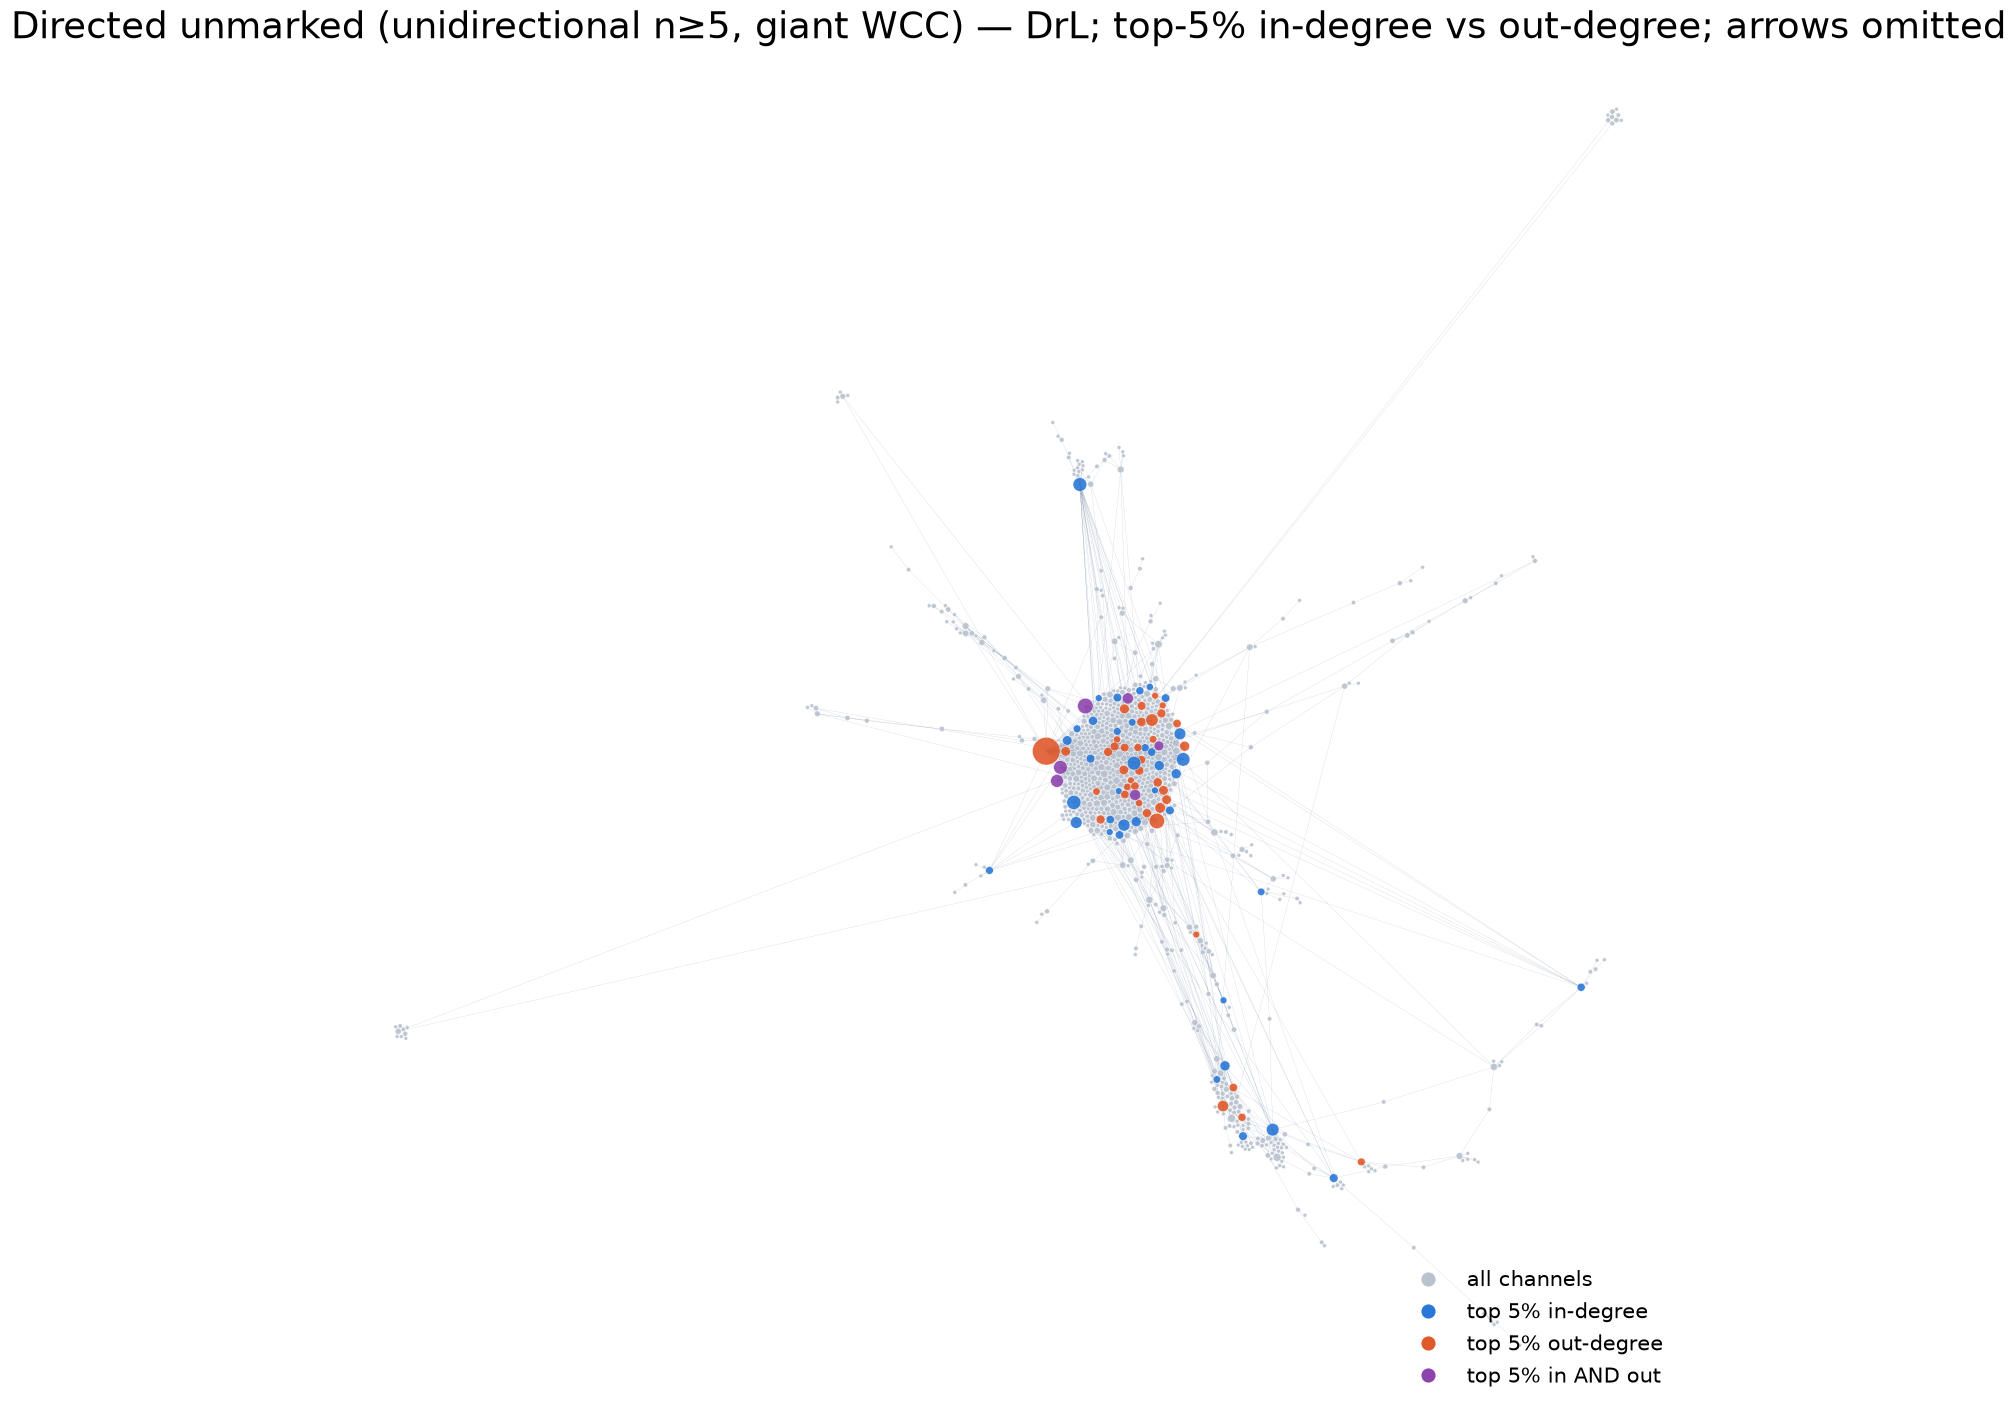

In [48]:
# » thesis: supplementary — the thesis shows only the undirected graph (Figure 9).
# ===== Directed unmarked (unidirectional n≥5, giant WCC) — DrL layout with tweakable controls =====
import numpy as np, matplotlib.pyplot as plt
from matplotlib.collections import LineCollection, EllipseCollection
from matplotlib.lines import Line2D
from scipy.spatial import cKDTree

# ============ TWEAK THESE, then re-run the cell (Shift+Enter) ============
SIZE_POWER          = 0.7     # node size vs degree (higher = hubs balloon more)
HUB_SIZE            = 0.010   # biggest-hub radius as a fraction of the frame
COMPRESS_PCT        = 100     # radial compression OFF (100 = raw DrL); lower = tighter (1..100)
LABELS              = 0       # how many top hubs to label
EDGE_ALPHA          = 1    # edge opacity (sparse graph needs more than the undirected one)
REPEL               = False    # spread nodes apart, degree-weighted (~10s)
REPEL_STRENGTH      = 1.05    # (only used when REPEL / PREVENT_ALL_OVERLAP is on)
PREVENT_ALL_OVERLAP = True   # strict zero-overlap packing OFF
LAYOUT_SEED         = 0       # change this number to reshuffle the DrL layout
# ========================================================================

_G = G_DIR_GIANT
htot = np.array(_G.degree(mode='all'), dtype=float)   # total (in+out) degree
hnames = np.array(_G.vs['name'])
_rng = np.random.default_rng(42)

from matplotlib.colors import to_rgb
_ind = dict(zip(G_DIR_GIANT.vs['name'], G_DIR_GIANT.degree(mode='in')))
_outd = dict(zip(G_DIR_GIANT.vs['name'], G_DIR_GIANT.degree(mode='out')))
_IN = set(sorted(_ind, key=lambda h: -_ind[h])[:max(1, int(len(_ind) * 0.05))])    # top 5% in-degree
_OUT = set(sorted(_outd, key=lambda h: -_outd[h])[:max(1, int(len(_outd) * 0.05))])  # top 5% out-degree
_BOTH = _IN & _OUT
_PAL = {'in': '#2a78d6', 'out': '#e0592b', 'both': '#8e44ad', 'b': '#b8c2ce'}
def _col(h):
    if h in _BOTH: return _PAL['both']
    if h in _IN:   return _PAL['in']
    if h in _OUT:  return _PAL['out']
    return _PAL['b']
hrgb = np.array([to_rgb(_col(h)) for h in hnames])

def hub_compress(coords, pct):
    if pct >= 100:
        return coords
    ctr = np.average(coords, axis=0, weights=htot); d = coords - ctr
    r = np.hypot(d[:, 0], d[:, 1]); r = np.where(r == 0, 1e-9, r); a = np.percentile(r, pct)
    return ctr + d * (a * np.arcsinh(r / a) / r)[:, None]

def hub_radii(coords, power, hub_frac):
    ext = max(np.ptp(coords[:, 0]), np.ptp(coords[:, 1]))
    return 0.0012 * ext + hub_frac * ext * (htot / htot.max()) ** power

def hub_repel(coords, radii, strength=1.05, full=False):
    coords = coords.copy()
    w = (htot / htot.max()) ** 0.5 + 0.15
    iters = 220 if full else 150; pad = strength
    lo0, hi0 = coords.min(0), coords.max(0); ctr0 = (lo0 + hi0) / 2; span0 = float((hi0 - lo0).max())
    for _ in range(iters):
        pairs = cKDTree(coords).query_pairs(r=2 * radii.max() * pad, output_type='ndarray')
        if len(pairs) == 0:
            break
        i, j = pairs[:, 0], pairs[:, 1]; delta = coords[i] - coords[j]; dist = np.hypot(delta[:, 0], delta[:, 1])
        ov = (radii[i] + radii[j]) * pad - dist; m = ov > 0
        if not m.any():
            break
        i, j, dst, d2, ovm = i[m], j[m], dist[m], delta[m], ov[m]; z = dst < 1e-9
        dirv = np.where(z[:, None], _rng.standard_normal((len(i), 2)),
                        d2 / np.where(dst[:, None] < 1e-9, 1, dst[:, None]))
        dirv /= np.hypot(dirv[:, 0], dirv[:, 1])[:, None]
        wi, wj = w[i], w[j]; sN = wi + wj
        shift = np.zeros_like(coords)
        np.add.at(shift, i,  dirv * (wi / sN * ovm)[:, None])
        np.add.at(shift, j, -dirv * (wj / sN * ovm)[:, None])
        mag = np.hypot(shift[:, 0], shift[:, 1]); cap = radii * 0.6
        sc = np.where(mag > cap, cap / np.where(mag == 0, 1, mag), 1.0)
        coords = coords + shift * sc[:, None]
    if not full:
        lo, hi = coords.min(0), coords.max(0); span = float((hi - lo).max())
        if span > span0:
            ctr = (lo + hi) / 2; coords = ctr0 + (coords - ctr) * (span0 / span)
    return coords

def hub_layout(base_coords, power, hub_frac, compress_pct, repel, repel_strength, no_overlap):
    coords = hub_compress(base_coords, compress_pct)
    radii = hub_radii(coords, power, hub_frac)
    if no_overlap:
        coords = hub_repel(coords, radii, strength=repel_strength, full=True)
    elif repel:
        coords = hub_repel(coords, radii, strength=repel_strength, full=False)
    return coords

# base DrL layout, cached by LAYOUT_SEED (changing the seed reshuffles; other tweaks reuse it)
try:
    _LAYOUTS_D
except NameError:
    _LAYOUTS_D = {}
if LAYOUT_SEED not in _LAYOUTS_D:
    _LAYOUTS_D[LAYOUT_SEED] = np.array(_G.layout_drl())
hub_base = _LAYOUTS_D[LAYOUT_SEED]
coords = hub_layout(hub_base, SIZE_POWER, HUB_SIZE, COMPRESS_PCT, REPEL, REPEL_STRENGTH, PREVENT_ALL_OVERLAP)
radii = hub_radii(coords, SIZE_POWER, HUB_SIZE)
_TITLE = 'Directed unmarked (unidirectional n≥5, giant WCC) — DrL; top-5% in-degree vs out-degree; arrows omitted'

FIG = 13                                # figure size (inches); all fonts scale with it
_fs = lambda frac: frac * FIG * 72      # points = fraction of the figure (dpi-independent)
fig, ax = plt.subplots(figsize=(FIG, FIG))
ax.add_collection(LineCollection([[coords[e.source], coords[e.target]] for e in _G.es],
                                 colors='#5f7396', linewidths=0.06, alpha=EDGE_ALPHA, zorder=1))
o = np.argsort(htot)
ax.add_collection(EllipseCollection(2 * radii[o], 2 * radii[o], np.zeros(_G.vcount()), units='xy',
    offsets=coords[o], transOffset=ax.transData, facecolors=hrgb[o],
    edgecolors='white', linewidths=0.3, alpha=0.9, zorder=2))
for i in np.argsort(htot)[::-1][:LABELS]:
    ax.text(coords[i, 0], coords[i, 1], hnames[i], fontsize=_fs(0.011), ha='center', va='center',
            zorder=3, bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.7))
ax.set_aspect('equal'); ax.autoscale_view(); ax.set_axis_off()
ax.set_title(_TITLE, fontsize=_fs(0.026))
_handles = [Line2D([0], [0], marker='o', ls='', mfc=_PAL['b'], mec='white', ms=_fs(0.011), label='all channels'),
            Line2D([0], [0], marker='o', ls='', mfc=_PAL['in'], mec='white', ms=_fs(0.011), label='top 5% in-degree'),
            Line2D([0], [0], marker='o', ls='', mfc=_PAL['out'], mec='white', ms=_fs(0.011), label='top 5% out-degree'),
            Line2D([0], [0], marker='o', ls='', mfc=_PAL['both'], mec='white', ms=_fs(0.011), label='top 5% in AND out')]
ax.legend(handles=_handles, loc='lower right', frameon=False, fontsize=_fs(0.015))
plt.tight_layout(); plt.show()


### A3 · Follow-ups on the per-node data

Whether internal reach tracks output rather than audience; that the top Russian partners are
the *aligned ecosystem* rather than Russia narrowly (Iranian Pars Today, the branded
`infodefense` network); that those partners are small-audience, high-output aggregators; and
the profile records for the four cs/sk reachers and three named Russian partners.

In [49]:
import pandas as pd, csv, json
from collections import Counter
_nd = pd.read_csv(DATA / 'nodes.csv'); _lang = dict(zip(_nd.handle, _nd.language)); _MEMSET = set(_nd.handle)
_desc = json.load(open(DATA / 'channel_descriptions.json'))
_subs = {h: _desc.get(h, {}).get('participants_count') for h in _nd.handle}
_msg = dict(zip(_nd.handle, _nd.n_msgs)); _type = dict(zip(_nd.handle, _nd.type)); _conf = dict(zip(_nd.handle, _nd.lang_confidence))
_CSKALL = [h for h in _nd.handle if _lang.get(h) in ('cs', 'sk')]

# ===== 3) marked-layer reach + Russian-partner counts =====
_fwd = [(r['origin'], r['target']) for r in csv.DictReader(open(DATA / 'edges_forward.csv')) if not r['origin'].startswith('id:')]
_MARK = set(x for e in _fwd for x in e); _fin = Counter(); _fout = Counter()
for o, t in _fwd: _fout[o] += 1; _fin[t] += 1
print("3a) marked-layer (forward) reach — confirmed against the current build:")
display(pd.DataFrame([{'channel': h, 'in marked': h in _MARK, 'forwarded-from-count (out, = its spread)': _fout[h],
    'sources-count (in, = it reposts)': _fin[h], 'total forward degree': _fout[h] + _fin[h]}
    for h in ('zemavek', 'nect24', 'selskyrozum', 'casusbellilive')]))
E = pd.read_csv(DATA / 'edges_unmarked.csv'); _u2 = E[E.n_semantic >= 2]; _ruln = Counter()
for r in _u2.itertuples(index=False):
    for c, o in ((r.u, r.v), (r.v, r.u)):
        if _lang.get(c) in ('cs', 'sk') and _lang.get(o) == 'ru': _ruln[c] += 1
print("3b) Russian-partner counts (unmarked layer) for the three you flagged:")
display(pd.DataFrame([{'channel': h, 'lang': _lang.get(h), 'type': _type.get(h), 'ru-links': _ruln.get(h, 0),
    'subscribers': _subs.get(h), 'messages': int(_msg.get(h, 0) or 0)} for h in ('zlom221', 'infovojna', 'pravdavzdyvitazi')]))

3a) marked-layer (forward) reach — confirmed against the current build:


,channel,in marked,"forwarded-from-count (out, = its spread)","sources-count (in, = it reposts)",total forward degree
0,zemavek,True,25,0,25
1,nect24,True,20,1,21
2,selskyrozum,True,18,11,29
3,casusbellilive,True,27,12,39


3b) Russian-partner counts (unmarked layer) for the three you flagged:


,channel,lang,type,ru-links,subscribers,messages
0,zlom221,cs,group,0,2070,2176
1,infovojna,sk,group,23,5827,6787
2,pravdavzdyvitazi,sk,channel,2,10166,814


In [50]:
import pandas as pd, csv, json
from collections import Counter
_nd = pd.read_csv(DATA / 'nodes.csv'); _lang = dict(zip(_nd.handle, _nd.language)); _MEMSET = set(_nd.handle)
_desc = json.load(open(DATA / 'channel_descriptions.json'))
_subs = {h: _desc.get(h, {}).get('participants_count') for h in _nd.handle}
_msg = dict(zip(_nd.handle, _nd.n_msgs)); _type = dict(zip(_nd.handle, _nd.type)); _conf = dict(zip(_nd.handle, _nd.lang_confidence))
_CSKALL = [h for h in _nd.handle if _lang.get(h) in ('cs', 'sk')]

# ===== 4) language-label check on the non-Russian connectors =====
_rows = []
for h in ('bgbzc', 'ruskistatek', 'infokju'):
    d = _desc.get(h, {})
    _rows.append({'channel': h, 'labelled lang': _lang.get(h), 'confidence': _conf.get(h), 'type': _type.get(h),
        'subscribers': d.get('participants_count'), 'title': d.get('title'), 'about (start)': (str(d.get('about') or ''))[:70]})
display(pd.DataFrame(_rows))
print("Verdict:")
print("  bgbzc       — MISLABEL: title/about are Bulgarian Cyrillic ('България - БеZ ЦенZура' = 'Bulgaria - Without")
print("                Censorship'), not Catalan. Should be bg, not ca. A pro-Russian ('БеZ' Z-branding) Bulgarian group.")
print("  ruskistatek — correctly Polish (conf 1.0): 'RuskiStatek', 'Sława bracia i siostry'. A genuine Polish pro-Russian channel.")
print("  infokju     — correctly Polish (conf 1.0): 'Kanał informacyjny KJU'. Genuine Polish channel.")
print("  → Only bgbzc is a mislabel; the two Polish channels are real non-Russian nodes in the cs/sk connector list —")
print("    a Polish–Czecho-Slovak reuse link, i.e. the same Central-European pro-Russian space, not a classification error.")

,channel,labelled lang,confidence,type,subscribers,title,about (start)
0,bgbzc,ca,0.909,group,58,България - БеZ ЦенZура,"Групата дава възможност за свободно ,нецензурирано общуване на участни"
1,ruskistatek,pl,1.000,channel,4506,RuskiStatek,Sława bracia i siostry.
2,infokju,pl,1.000,channel,12337,Kanał informacyjny 🐸KJU🐸,


Verdict:
  bgbzc       — MISLABEL: title/about are Bulgarian Cyrillic ('България - БеZ ЦенZура' = 'Bulgaria - Without
                Censorship'), not Catalan. Should be bg, not ca. A pro-Russian ('БеZ' Z-branding) Bulgarian group.
  ruskistatek — correctly Polish (conf 1.0): 'RuskiStatek', 'Sława bracia i siostry'. A genuine Polish pro-Russian channel.
  infokju     — correctly Polish (conf 1.0): 'Kanał informacyjny KJU'. Genuine Polish channel.
  → Only bgbzc is a mislabel; the two Polish channels are real non-Russian nodes in the cs/sk connector list —
    a Polish–Czecho-Slovak reuse link, i.e. the same Central-European pro-Russian space, not a classification error.


In [51]:
import pandas as pd, csv, json, numpy as np
from collections import Counter
from scipy.stats import spearmanr
_nd = pd.read_csv(DATA / 'nodes.csv'); _lang = dict(zip(_nd.handle, _nd.language)); _MEM = set(_nd.handle)
_desc = json.load(open(DATA / 'channel_descriptions.json'))
_subs = {h: _desc.get(h, {}).get('participants_count') for h in _nd.handle}; _msg = dict(zip(_nd.handle, _nd.n_msgs))
_E = pd.read_csv(DATA / 'edges_unmarked.csv'); _u2 = _E[_E.n_semantic >= 2]; _CSK = set(h for h in _MEM if _lang.get(h) in ('cs', 'sk'))
_ruln = Counter(); _ruc = Counter()
for r in _u2.itertuples(index=False):
    for c, o in ((r.u, r.v), (r.v, r.u)):
        if c in _CSK and _lang.get(o) == 'ru': _ruln[c] += 1; _ruc[o] += 1

# ===== (1) reach into ru tracks OUTPUT, not AUDIENCE — the ρ caveat re-derived for this layer =====
_pool = [h for h in _CSK if _ruln[h] > 0]
_medv = dict(zip(_nd.handle, _nd.median_views))
_x = np.array([_ruln[h] for h in _pool]); _m = np.array([_msg.get(h, 0) or 0 for h in _pool])
_v = np.array([_medv.get(h) if pd.notna(_medv.get(h)) else np.nan for h in _pool], dtype=float); _vm = ~np.isnan(_v)
_rm, _pm = spearmanr(_x, _m); _rs, _ps = spearmanr(_x[_vm], _v[_vm])
print(f"cs/sk channels with ≥1 ru edge: n={len(_pool)}")
display(pd.DataFrame([
    {'correlate of reach-into-ru (ru-links)': 'message count (OUTPUT)', 'Spearman ρ': round(_rm, 3), 'p': f'{_pm:.1e}'},
    {'correlate of reach-into-ru (ru-links)': 'median post views (AUDIENCE)', 'Spearman ρ': round(_rs, 3), 'p': f'{_ps:.2f}'}]))
print(f"→ ru-reach ↔ output ρ = {_rm:.3f} (≈ the unmarked directed layer's 0.452 out-degree↔messages (§hub section)); ru-reach ↔ audience (median post views) ρ = {_rs:.3f} (not significant, n={_vm.sum()}).")
print("  The bridge is carried by the most PROLIFIC cs/sk channels, not the largest — same caveat the Marked chapter carries.")

cs/sk channels with ≥1 ru edge: n=33


,correlate of reach-into-ru (ru-links),Spearman ρ,p
0,message count (OUTPUT),0.451,8.4e-03
1,median post views (AUDIENCE),-0.097,0.59


→ ru-reach ↔ output ρ = 0.451 (≈ the unmarked directed layer's 0.452 out-degree↔messages (§hub section)); ru-reach ↔ audience (median post views) ρ = -0.097 (not significant, n=33).
  The bridge is carried by the most PROLIFIC cs/sk channels, not the largest — same caveat the Marked chapter carries.


In [52]:
import pandas as pd, csv, json, numpy as np
from collections import Counter
from scipy.stats import spearmanr
_nd = pd.read_csv(DATA / 'nodes.csv'); _lang = dict(zip(_nd.handle, _nd.language)); _MEM = set(_nd.handle)
_desc = json.load(open(DATA / 'channel_descriptions.json'))
_subs = {h: _desc.get(h, {}).get('participants_count') for h in _nd.handle}; _msg = dict(zip(_nd.handle, _nd.n_msgs))
_E = pd.read_csv(DATA / 'edges_unmarked.csv'); _u2 = _E[_E.n_semantic >= 2]; _CSK = set(h for h in _MEM if _lang.get(h) in ('cs', 'sk'))
_ruln = Counter(); _ruc = Counter()
for r in _u2.itertuples(index=False):
    for c, o in ((r.u, r.v), (r.v, r.u)):
        if c in _CSK and _lang.get(o) == 'ru': _ruln[c] += 1; _ruc[o] += 1

# ===== (3) the reuse space is the aligned ecosystem broadly — not Russia narrowly =====
# selskyrozum's heaviest partner is Iranian state media; a branded multi-edition network also appears.
def _tops(ch, k=6):
    rows = [(r.v if r.u == ch else r.u, r.n_semantic) for r in _u2.itertuples(index=False) if ch in (r.u, r.v)]
    rows = [(o, n) for o, n in rows if _lang.get(o) == 'ru']; rows.sort(key=lambda x: -x[1])
    return rows[:k]
_orig = {'parstodayrussian': 'Iranian state media (Pars Today / IRIB)', 'parstodayrussianchat': 'Iranian (Pars Today)'}
print("(3a) @selskyrozum's heaviest reuse partners — the single largest is NOT Russian:")
display(pd.DataFrame([{'partner': o, 'matched pairs': n, 'lang label': _lang.get(o), 'subs': _subs.get(o),
    'what it actually is': _orig.get(o, _desc.get(o, {}).get('title', ''))} for o, n in _tops('selskyrozum')]))
_brand = [h for h in _MEM if 'parstoday' in h or 'houseofcards' in h]
print("(3b) non-Russian / branded outlets present in the reuse ecosystem (Iranian Pars Today + the 'House of Cards' network):")
display(pd.DataFrame([{'handle': h, 'lang label': _lang.get(h), 'subs': _subs.get(h), 'title': _desc.get(h, {}).get('title'),
    'cs/sk links': _ruc.get(h, 0)} for h in sorted(_brand)]))
print("→ 'Russian partner' means Russian-LANGUAGE, not Russian-origin: the heaviest cs/sk reuse tie (parstodayrussian, 50 pairs)")
print("  is Iranian state media in Russian. The reuse space is the aligned pro-Kremlin ecosystem broadly.")

(3a) @selskyrozum's heaviest reuse partners — the single largest is NOT Russian:


,partner,matched pairs,lang label,subs,what it actually is
0,parstodayrussian,50,ru,29196,Iranian state media (Pars Today / IRIB)
1,houseofcardseurope,33,ru,12522,Карточный Домик: Европа
2,bye_biden,31,ru,88953,БайБайден
3,bbbreaking,24,ru,1970081,Раньше всех. Ну почти.
4,rus_6a3a,23,ru,511,🇷🇺 6а3а
5,osvedomitell,22,ru,6313,Война 2022 Россия-Украина WAR UKRAINE RUSSIAN


(3b) non-Russian / branded outlets present in the reuse ecosystem (Iranian Pars Today + the 'House of Cards' network):


,handle,lang label,subs,title,cs/sk links
0,houseofcardseurope,ru,12522.0,Карточный Домик: Европа,3
1,houseofcardsmoscow,ru,519.0,Карточный домик: Москва,1
2,houseofcardsrussia,ru,7702.0,Карточный Домик: Россия,4
3,houseofcardsspb,ru,740.0,Карточный домик: Петербург,0
4,parstodayru,unknown,NaN,NaN,0
5,parstodayrussian,ru,29196.0,ParsToday Russian 🇮🇷,7
6,parstodayrussianchat,ru,395.0,Ньюсрум,0


→ 'Russian partner' means Russian-LANGUAGE, not Russian-origin: the heaviest cs/sk reuse tie (parstodayrussian, 50 pairs)
  is Iranian state media in Russian. The reuse space is the aligned pro-Kremlin ecosystem broadly.


In [53]:
import pandas as pd, csv, json, numpy as np
from collections import Counter
from scipy.stats import spearmanr
_nd = pd.read_csv(DATA / 'nodes.csv'); _lang = dict(zip(_nd.handle, _nd.language)); _MEM = set(_nd.handle)
_desc = json.load(open(DATA / 'channel_descriptions.json'))
_subs = {h: _desc.get(h, {}).get('participants_count') for h in _nd.handle}; _msg = dict(zip(_nd.handle, _nd.n_msgs))
_E = pd.read_csv(DATA / 'edges_unmarked.csv'); _u2 = _E[_E.n_semantic >= 2]; _CSK = set(h for h in _MEM if _lang.get(h) in ('cs', 'sk'))
_ruln = Counter(); _ruc = Counter()
for r in _u2.itertuples(index=False):
    for c, o in ((r.u, r.v), (r.v, r.u)):
        if c in _CSK and _lang.get(o) == 'ru': _ruln[c] += 1; _ruc[o] += 1

# ===== (4) the ru partners are small-audience, high-output aggregators =====
_medv = dict(zip(_nd.handle, _nd.median_views))            # actual reach per post (NaN for groups / unviewed)
def _mv(h):
    v = _medv.get(h)
    return int(v) if v is not None and pd.notna(v) else None
_top = [h for h, _ in _ruc.most_common(12)]
_df = pd.DataFrame([{'ru partner': h, 'cs/sk links': _ruc[h], 'median views': _mv(h),
    'messages': int(_msg.get(h, 0) or 0), 'title': (_desc.get(h, {}).get('title') or '')[:30]} for h in _top])
print("(4) top-12 Russian partners — audience (median views) vs output:")
display(_df)
_tv = [_mv(h) for h in _top if _mv(h) is not None]; _tm = [_msg.get(h, 0) or 0 for h in _top]
print(f"→ median {int(np.median(_tv)):,} views/post (n={len(_tv)} view-valid of 12) but median {int(np.median(_tm)):,} messages — "
      f"high-output aggregators, not large-audience outlets (e.g. osvedomitell {_mv('osvedomitell'):,} views, "
      f"rus_6a3a {_mv('rus_6a3a')} views, angelika_vz {_mv('angelika_vz')} views). Supports the contrast, "
      f"but the media-vs-aggregator claim still needs the worked exhibit.")

(4) top-12 Russian partners — audience (median views) vs output:


,ru partner,cs/sk links,median views,messages,title
0,allratings,20,86,5609,Караульный по рейтингам
1,odessarussi,19,2082,6748,Одесса Zа Победу! ⚓️
2,angelika_vz,15,24,5207,Z🇷🇺 Информфронт V🇷🇺
3,osvedomitell,14,2201,8849,Война 2022 Россия-Украина WAR
4,polit_anarx,14,14,9192,Политический анархист
5,rus_6a3a,14,44,5062,🇷🇺 6а3а
6,meerzonaa,13,245,6765,🙏Опровержение фейков
7,otpervogolitsa,13,13486,2132,От Первого Лица | ОПЛ
8,nash_prezident_putin,13,2676,7300,НашПрезидентПУТИН
9,lisichanskinfo,12,2819,6530,«Лисичанск - колыбель Донбасса


→ median 1,284 views/post (n=12 view-valid of 12) but median 6,639 messages — high-output aggregators, not large-audience outlets (e.g. osvedomitell 2,201 views, rus_6a3a 44 views, angelika_vz 24 views). Supports the contrast, but the media-vs-aggregator claim still needs the worked exhibit.


In [54]:
import pandas as pd, csv, json, numpy as np
from collections import Counter
from scipy.stats import spearmanr
_nd = pd.read_csv(DATA / 'nodes.csv'); _lang = dict(zip(_nd.handle, _nd.language)); _MEM = set(_nd.handle)
_desc = json.load(open(DATA / 'channel_descriptions.json'))
_subs = {h: _desc.get(h, {}).get('participants_count') for h in _nd.handle}; _msg = dict(zip(_nd.handle, _nd.n_msgs))
_E = pd.read_csv(DATA / 'edges_unmarked.csv'); _u2 = _E[_E.n_semantic >= 2]; _CSK = set(h for h in _MEM if _lang.get(h) in ('cs', 'sk'))
_ruln = Counter(); _ruc = Counter()
for r in _u2.itertuples(index=False):
    for c, o in ((r.u, r.v), (r.v, r.u)):
        if c in _CSK and _lang.get(o) == 'ru': _ruln[c] += 1; _ruc[o] += 1

# ===== (5) undeclared reuse partners are near-disjoint from declared forward partners =====
_fwd = [(r['origin'], r['target']) for r in csv.DictReader(open(DATA / 'edges_forward.csv')) if not r['origin'].startswith('id:')]
_fpart = {}; _origins = set(o for o, _ in _fwd)
for o, t in _fwd: _fpart.setdefault(o, set()).add(t); _fpart.setdefault(t, set()).add(o)
_rupart = {}
for r in _u2.itertuples(index=False):
    for c, o in ((r.u, r.v), (r.v, r.u)):
        if c in _CSK and _lang.get(o) == 'ru': _rupart.setdefault(c, set()).add(o)
_rows = []
for h in ('selskyrozum', 'zemavek', 'cactus_bielli', 'nect24'):
    rp = _rupart.get(h, set()); fp = _fpart.get(h, set())
    _rows.append({'channel': h, 'unmarked ru-partners': len(rp), 'declared forward-partners': len(fp), 'dyadic overlap': len(rp & fp)})
display(pd.DataFrame(_rows))
_alln = sum(len(_rupart.get(h, set())) for h in _CSK); _allov = sum(len(_rupart.get(h, set()) & _fpart.get(h, set())) for h in _CSK)
_ru_all = set().union(*_rupart.values()) if _rupart else set(); _also_src = {h for h in _ru_all if h in _origins}
print(f"(5) reuse ≠ forwarding: only {_allov} of {_alln} cs/sk↔ru reuse links coincide with a declared forward partner = {_allov/_alln:.1%} (dyadic).")
print(f"   'Exceptions' are channel-level, not dyadic: {len(_also_src)} of the {len(_ru_all)} reused ru channels are ALSO forward-sources")
print(f"   somewhere in the marked network (e.g. bbbreaking — a big marked source AND a selskyrozum reuse partner, but not FROM it).")
print("   → answer to the overlap item: largely disjoint — the undeclared layer captures relationships the declared layer does not.")

,channel,unmarked ru-partners,declared forward-partners,dyadic overlap
0,selskyrozum,270,27,0
1,zemavek,138,25,0
2,cactus_bielli,111,5,0
3,nect24,74,21,0


(5) reuse ≠ forwarding: only 2 of 1358 cs/sk↔ru reuse links coincide with a declared forward partner = 0.1% (dyadic).
   'Exceptions' are channel-level, not dyadic: 401 of the 442 reused ru channels are ALSO forward-sources
   somewhere in the marked network (e.g. bbbreaking — a big marked source AND a selskyrozum reuse partner, but not FROM it).
   → answer to the overlap item: largely disjoint — the undeclared layer captures relationships the declared layer does not.


In [55]:
import pandas as pd, csv, json, numpy as np
from collections import Counter
from scipy.stats import spearmanr
_nd = pd.read_csv(DATA / 'nodes.csv'); _lang = dict(zip(_nd.handle, _nd.language)); _MEM = set(_nd.handle)
_desc = json.load(open(DATA / 'channel_descriptions.json'))
_subs = {h: _desc.get(h, {}).get('participants_count') for h in _nd.handle}; _msg = dict(zip(_nd.handle, _nd.n_msgs))
_E = pd.read_csv(DATA / 'edges_unmarked.csv'); _u2 = _E[_E.n_semantic >= 2]; _CSK = set(h for h in _MEM if _lang.get(h) in ('cs', 'sk'))
_ruln = Counter(); _ruc = Counter()
for r in _u2.itertuples(index=False):
    for c, o in ((r.u, r.v), (r.v, r.u)):
        if c in _CSK and _lang.get(o) == 'ru': _ruln[c] += 1; _ruc[o] += 1

# ===== (6) the @allratings caveat — omnivorous aggregator, brokerage likely an artifact =====
_fwd = [(r['origin'], r['target']) for r in csv.DictReader(open(DATA / 'edges_forward.csv')) if not r['origin'].startswith('id:')]
_fin = Counter(); _fout = Counter()
for o, t in _fwd: _fout[o] += 1; _fin[t] += 1
_d = _desc.get('allratings', {})
display(pd.DataFrame([{'metric': 'subscribers', 'allratings': _d.get('participants_count')},
    {'metric': 'messages', 'allratings': int(_msg.get('allratings', 0) or 0)},
    {'metric': 'cs/sk links (top broker)', 'allratings': _ruc.get('allratings', 0)},
    {'metric': 'orientable cs/sk edges', 'allratings': 0},
    {'metric': 'marked: reposts FROM (in-forward)', 'allratings': _fin['allratings']},
    {'metric': 'marked: forwarded-from BY others (out-forward)', 'allratings': _fout['allratings']}]))
print(f"(6) @allratings: {_d.get('participants_count')} subscribers but {int(_msg.get('allratings',0) or 0):,} messages, and it reposts")
print(f"   from {_fin['allratings']} sources while almost nothing sources from it ({_fout['allratings']} out). An omnivorous aggregator —")
print("   its top-broker status and zero orientable edges are consistent with reposting everything, not a directed relationship.")
print("   Caveat wherever it appears: brokerage here is a volume artifact, not evidence of a cs/sk↔ru hand-off.")

,metric,allratings
0,subscribers,796
1,messages,5609
2,cs/sk links (top broker),20
3,orientable cs/sk edges,0
4,marked: reposts FROM (in-forward),511
5,marked: forwarded-from BY others (out-forward),2


(6) @allratings: 796 subscribers but 5,609 messages, and it reposts
   from 511 sources while almost nothing sources from it (2 out). An omnivorous aggregator —
   its top-broker status and zero orientable edges are consistent with reposting everything, not a directed relationship.
   Caveat wherever it appears: brokerage here is a volume artifact, not evidence of a cs/sk↔ru hand-off.


In [56]:
# ===== titles / descriptions / type for the four cs/sk reachers =====
import pandas as pd, json
_nd = pd.read_csv(DATA / 'nodes.csv'); _type = dict(zip(_nd.handle, _nd.type)); _lang = dict(zip(_nd.handle, _nd.language))
_desc = json.load(open(DATA / 'channel_descriptions.json'))
_who = ['selskyrozum', 'zemavek', 'cactus_bielli', 'infodefensecze']
display(pd.DataFrame([{'handle': h, 'lang': _lang.get(h), 'type': _type.get(h),
                       'title': _desc.get(h, {}).get('title'),
                       'subscribers': _desc.get(h, {}).get('participants_count')} for h in _who]))
for h in _who:
    print(f"\n@{h}  ({_type.get(h)}, {_lang.get(h)}) — {_desc.get(h, {}).get('title')}")
    print(f"  description: {_desc.get(h, {}).get('about') or '(none)'}")

,handle,lang,type,title,subscribers
0,selskyrozum,cs,channel,Selský Rozum,12443
1,zemavek,sk,channel,ZEM&VEK,32973
2,cactus_bielli,sk,channel,Cactus Bielli,1598
3,infodefensecze,cs,channel,InfoDefenseCZE,3421



@selskyrozum  (channel, cs) — Selský Rozum
  description: Reklama na kanálu - @selskyrozum_bot
Nabídka spolupráce - @selskyrozum_bot
Stali jste se svědky zajímavé události? Koupíme vaše fotografie a videa - @selskyrozum_bot

@zemavek  (channel, sk) — ZEM&VEK
  description: NAJKOMPLEXNEJŠÍ SLOVENSKÝ TELEGRAM

@cactus_bielli  (channel, sk) — Cactus Bielli
  description: Cactus Bielli - Vojny & Konflikty & Zbrane & Geopolitika * * *
Cactus Bielli - Wars & Conflicts & Weapons & Geopolitic

@infodefensecze  (channel, cs) — InfoDefenseCZE
  description: Ukrajina, Svět, SVO - rеalita!
#Ukrajina; #Rusko; #Válka; #Donbass; #DNR; #LNR; #NATO; #USA; #StopHatingRussians; #Ukrnews; #VládaBanditů; #KijevskáVláda; #Okupace; #ValkaNaUkrajine; #Dezinformace; #USAZachraniEvrope; #JadernýTerorismus


In [57]:
# ===== median post views for three Russian partners =====
import pandas as pd, json
_nd = pd.read_csv(DATA / 'nodes.csv')
_mv = dict(zip(_nd.handle, _nd.median_views)); _msg = dict(zip(_nd.handle, _nd.n_msgs))
_desc = json.load(open(DATA / 'channel_descriptions.json'))
_who = ['osvedomitell', 'rus_6a3a', 'angelika_vz']
display(pd.DataFrame([{'channel': h, 'median views': _mv.get(h),
                       'subscribers': _desc.get(h, {}).get('participants_count'),
                       'messages': int(_msg.get(h, 0) or 0),
                       'title': _desc.get(h, {}).get('title')} for h in _who]))

,channel,median views,subscribers,messages,title
0,osvedomitell,2201.0,6313,8849,Война 2022 Россия-Украина WAR UKRAINE RUSSIAN
1,rus_6a3a,44.0,511,5062,🇷🇺 6а3а
2,angelika_vz,24.0,2653,5207,Z🇷🇺 Информфронт V🇷🇺
